# PART-01

# Cell 1 — Library Imports

In [1]:
import dill
dill.load_session('notebook_env.db')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
import pickle
import json
import joblib
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import io
from matplotlib.patches import Patch
from IPython.display import display as ipy_display, Image as IPyImage

matplotlib.rcParams['figure.dpi']     = 150   
matplotlib.rcParams['savefig.dpi']    = 300  
matplotlib.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# XGBoost
import xgboost as xgb

# SHAP
import shap

# Seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 70)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY!")
print("=" * 70)
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"XGBoost : {xgb.__version__}")
print(f"SHAP    : {shap.__version__}")
print(f"Matplotlib Backend: {matplotlib.get_backend()}")
print("=" * 70)

ALL LIBRARIES IMPORTED SUCCESSFULLY!
Pandas  : 2.2.3
NumPy   : 1.26.4
XGBoost : 3.0.2
SHAP    : 0.45.0
Matplotlib Backend: module://matplotlib_inline.backend_inline


# Cell 2 — Global Configuration

In [3]:
# Cell 2 — Global Configuration (Phase 2 Update)

class Config:
    # Paths
    DATA_PATH    = "population.csv"
    OUTPUT_DIR   = "outputs/"
    MODELS_DIR   = "models/"
    FIGURES_DIR  = "figures/"

    # Reproducibility
    RANDOM_STATE = 42

    # Federated Learning — all consistent
    N_CLIENTS    = 5
    N_ROUNDS     = 5 
    LOCAL_EPOCHS = 1

    # GradientBoosting config — Population (larger scale needs more capacity)
    GB_CONFIG = {
        'n_estimators'     : 200,          # increased from 100
        'learning_rate'    : 0.03,         # reduced for better generalisation
        'max_depth'        : 5,            # deeper trees for complex trends
        'min_samples_split': 10,
        'min_samples_leaf' : 5,
        'subsample'        : 0.8,
        'max_features'     : 'sqrt',
        'random_state'     : RANDOM_STATE,
    }

    # GradientBoosting config — Life Expectancy (lighter model)
    GB_CONFIG_LIFE = {
        'n_estimators'     : 100,
        'learning_rate'    : 0.05,
        'max_depth'        : 3,
        'min_samples_split': 10,
        'min_samples_leaf' : 5,
        'subsample'        : 0.8,
        'max_features'     : 'sqrt',
        'random_state'     : RANDOM_STATE,
    }
    
    KD_ALPHA = 0.3   # default (overridden by OOF search)

    # Targets
    TARGET_COLUMNS = [
        'Population, total',
        'Life expectancy at birth, total (years)',
    ]

    # Feature Engineering 
    LAG_FEATURES    = [1, 2, 3] 
    ROLLING_WINDOWS = [3, 5]

    # Time-based split
    TRAIN_END_YEAR  = 2021
    TEST_START_YEAR = 2022

    # Domain constraints
    MIN_POPULATION      = 1_000
    MAX_POPULATION      = 2e9
    MIN_LIFE_EXPECTANCY = 40
    MAX_LIFE_EXPECTANCY = 90

# Create directories
for d in [Config.OUTPUT_DIR, Config.MODELS_DIR, Config.FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 70)
print("CONFIGURATION LOADED")
print("=" * 70)
print(f"  Federated Clients : {Config.N_CLIENTS}")
print(f"  Federated Rounds  : {Config.N_ROUNDS}  (consistent)")
print(f"  Train End Year    : {Config.TRAIN_END_YEAR}")
print(f"  Test Start Year   : {Config.TEST_START_YEAR}")
print(f"  Lag Features      : {Config.LAG_FEATURES}  (all targets)")
print("=" * 70)

CONFIGURATION LOADED
  Federated Clients : 5
  Federated Rounds  : 5  (consistent)
  Train End Year    : 2021
  Test Start Year   : 2022
  Lag Features      : [1, 2, 3]  (all targets)


# Cell 3 — Data Loading

In [4]:
print("=" * 70)
print("STEP 1: LOADING DATASET")
print("=" * 70)

# Load dataset
df_raw = pd.read_csv(Config.DATA_PATH)

# Basic info
print(f"Shape         : {df_raw.shape}")
print(f"Countries     : {df_raw['Country Name'].nunique()}")
print(f"Year range    : {df_raw['Year'].min()} – {df_raw['Year'].max()}")
print(f"Total records : {len(df_raw)}")

print("=" * 70)

# Quick preview
display(df_raw.head(3))

# Optional: dtype check
print("\nCOLUMN DTYPES:")
print(df_raw.dtypes)

STEP 1: LOADING DATASET
Shape         : (4725, 18)
Countries     : 189
Year range    : 2000 – 2024
Total records : 4725


,Country Name,Country Code,Year,"Population, male (% of total population)","Population, female (% of total population)",Population ages 0-14 (% of total population),Population ages 65 and above (% of total population),"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)","Fertility rate, total (births per woman)",Net migration,GDP growth (annual %),GDP per capita (current US$),Population growth (annual %),"Mortality rate, infant (per 1,000 live births)","Immunization, DPT (% of children ages 12-23 months)","Population, total","Life expectancy at birth, total (years)"
0,Afghanistan,AFG,2000,50.146456,49.853544,50.024930,2.261970,51.491,12.608,7.566,-1025973,NaN,174.930991,1.212176,110.1,24.0,20130327,55.005
1,Afghanistan,AFG,2001,50.185557,49.814443,50.168690,2.261948,49.623,11.954,7.453,-212872,-9.431974,138.706822,0.762005,107.0,33.0,20284307,55.511
2,Afghanistan,AFG,2002,50.225181,49.774819,50.237897,2.263974,47.488,11.187,7.320,860349,28.600001,178.954088,5.252030,103.8,36.0,21378117,56.225



COLUMN DTYPES:
Country Name                                             object
Country Code                                             object
Year                                                      int64
Population, male (% of total population)                float64
Population, female (% of total population)              float64
Population ages 0-14 (% of total population)            float64
Population ages 65 and above (% of total population)    float64
Birth rate, crude (per 1,000 people)                    float64
Death rate, crude (per 1,000 people)                    float64
Fertility rate, total (births per woman)                float64
Net migration                                             int64
GDP growth (annual %)                                   float64
GDP per capita (current US$)                            float64
Population growth (annual %)                            float64
Mortality rate, infant (per 1,000 live births)          float64
Immunization, DPT (% of 

# Cell 4 — Missing Value Handler

In [5]:
# ================================================================
# Cell 4 — Missing Value Handler
# ================================================================
print("=" * 70)
print("STEP 2: MISSING VALUE ANALYSIS")
print("=" * 70)

missing_counts = df_raw.isnull().sum()
missing_pct    = (missing_counts / len(df_raw)) * 100

missing_report = (
    pd.DataFrame({
        "Column": missing_counts.index,
        "MissingCount": missing_counts.values,
        "MissingPercent": missing_pct.values
    })
    .query("MissingCount > 0")
    .sort_values("MissingCount", ascending=False)
)

if not missing_report.empty:
    print(f"Columns with missing : {len(missing_report)}")
    print(f"Total missing values: {df_raw.isnull().sum().sum()}\n")
    print(missing_report.to_string(index=False))
else:
    print("No missing values found!")

print("=" * 70)

STEP 2: MISSING VALUE ANALYSIS
Columns with missing : 9
Total missing values: 1191

                                             Column  MissingCount  MissingPercent
     Mortality rate, infant (per 1,000 live births)           213        4.507937
               Birth rate, crude (per 1,000 people)           189        4.000000
               Death rate, crude (per 1,000 people)           189        4.000000
           Fertility rate, total (births per woman)           189        4.000000
            Life expectancy at birth, total (years)           189        4.000000
                              GDP growth (annual %)           101        2.137566
                       GDP per capita (current US$)            75        1.587302
Immunization, DPT (% of children ages 12-23 months)            45        0.952381
                       Population growth (annual %)             1        0.021164


In [6]:
# ================================================================
# HANDLING MISSING VALUES
# ================================================================
print("=" * 70)
print("STEP 3: HANDLING MISSING VALUES")
print("=" * 70)

df_clean = df_raw.copy()
df_clean = df_clean.sort_values(["Country Code", "Year"]).reset_index(drop=True)

print("Strategy: per-country ffill → TRAIN-ONLY bfill → TRAIN-ONLY median")

before = df_clean.isnull().sum().sum()

num_cols = df_clean.select_dtypes(include=np.number).columns
train_mask = df_clean["Year"] <= Config.TRAIN_END_YEAR   # 2021 

for col in num_cols:
    if df_clean[col].isnull().any():
        # 1. Forward fill (পুরো সিরিজে) – past values ব্যবহার করে, সম্পূর্ণ নিরাপদ
        df_clean[col] = df_clean.groupby("Country Code")[col].ffill()

        # 2. Backward fill শুধুমাত্র ট্রেনিং সময়ের মধ্যে (2000–2021)
        #    এটি ভবিষ্যতের টেস্ট ডেটা (2022+) দেখবে না
        df_clean.loc[train_mask, col] = (
            df_clean.loc[train_mask]
            .groupby("Country Code")[col]
            .transform(lambda x: x.bfill())
        )

        # 3. এখনও কোনো ফাঁক থাকলে train-only median দিয়ে পূরণ
        train_median = df_clean.loc[train_mask, col].median()
        df_clean[col] = df_clean[col].fillna(train_median)

# Categorical columns (mode সম্পূর্ণ নিরাপদ)
cat_cols = df_clean.select_dtypes(include="object").columns
for col in cat_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

after = df_clean.isnull().sum().sum()

print(f"Missing before : {before}")
print(f"Missing after  : {after}")
print(f"Imputed values : {before - after}")
print("ALL MISSING VALUES HANDLED!")
print("=" * 70)

print(f"Clean dataset shape: {df_clean.shape}")

STEP 3: HANDLING MISSING VALUES
Strategy: per-country ffill → TRAIN-ONLY bfill → TRAIN-ONLY median
Missing before : 1191
Missing after  : 0
Imputed values : 1191
ALL MISSING VALUES HANDLED!
Clean dataset shape: (4725, 18)


# Cell 5 — Missing Value Handler Visual

STEP 4: MISSING VALUE VISUALIZATION


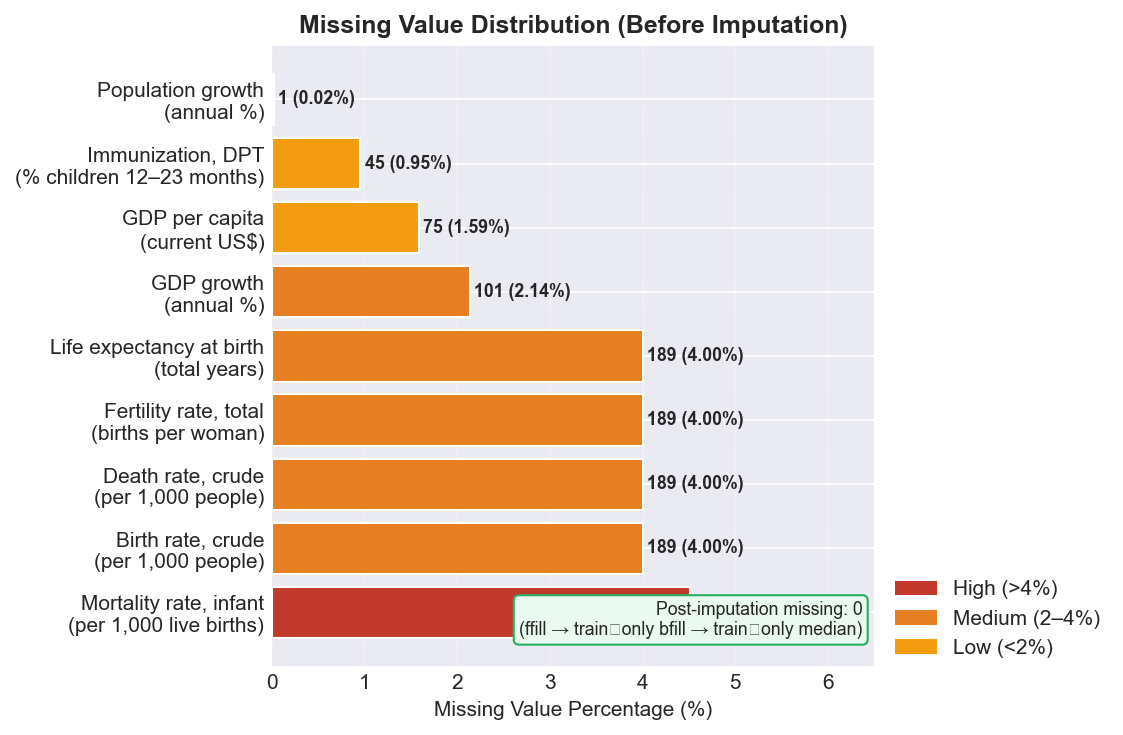

Fig saved → fig1_missing_value_distribution.png


In [7]:
# Cell 5 — Missing Value Handler Visual (Dynamic Version)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("=" * 70)
print("STEP 4: MISSING VALUE VISUALIZATION")
print("=" * 70)

# Display labels (with newlines for the plot)
missing_cols = [
    'Mortality rate, infant\n(per 1,000 live births)',
    'Birth rate, crude\n(per 1,000 people)',
    'Death rate, crude\n(per 1,000 people)',
    'Fertility rate, total\n(births per woman)',
    'Life expectancy at birth\n(total years)',
    'GDP growth\n(annual %)',
    'GDP per capita\n(current US$)',
    'Immunization, DPT\n(% children 12–23 months)',
    'Population growth\n(annual %)',
]

# Actual column names in df_raw (without newlines, must match exactly)
actual_col_names = [
    'Mortality rate, infant (per 1,000 live births)',
    'Birth rate, crude (per 1,000 people)',
    'Death rate, crude (per 1,000 people)',
    'Fertility rate, total (births per woman)',
    'Life expectancy at birth, total (years)',
    'GDP growth (annual %)',
    'GDP per capita (current US$)',
    'Immunization, DPT (% of children ages 12-23 months)',
    'Population growth (annual %)',
]

# Dynamically compute missing counts and total rows
missing_vals = [df_raw[col].isnull().sum() for col in actual_col_names]
total_rows = len(df_raw)

missing_pct = [(v / total_rows) * 100 for v in missing_vals]

colors = ['#c0392b' if p > 4 else '#e67e22' if p > 2 else '#f39c12'
          for p in missing_pct]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(missing_cols, missing_pct, color=colors, edgecolor='white')

for bar, val, pct in zip(bars, missing_vals, missing_pct):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f"{val} ({pct:.2f}%)",
            va='center', fontsize=8.5, fontweight='bold')

ax.set_xlabel("Missing Value Percentage (%)")
ax.set_xlim(0, 6.5)
ax.set_title("Missing Value Distribution (Before Imputation)", fontweight='bold')

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Legend outside (fixed)
legend_elements = [
    Patch(facecolor='#c0392b', label='High (>4%)'),
    Patch(facecolor='#e67e22', label='Medium (2–4%)'),
    Patch(facecolor='#f39c12', label='Low (<2%)'),
]

ax.legend(handles=legend_elements, loc='lower left',
          bbox_to_anchor=(1.02, 0), borderaxespad=0)

# Updated annotation
ax.text(0.98, 0.05,
        "Post-imputation missing: 0\n(ffill → train‑only bfill → train‑only median)",
        transform=ax.transAxes, ha='right', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#eafaf1', edgecolor='#27ae60'))

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(f"{Config.FIGURES_DIR}fig1_missing_value_distribution.png",
            dpi=300, bbox_inches='tight')

plt.show()
plt.close()

print("Fig saved → fig1_missing_value_distribution.png")
print("=" * 70)

# Cell 6 — Categorical Encoding (Global Fit)

In [8]:
# Fit on complete country vocabulary to ensure consistent index mapping across federated clients.
# This does not leak target information as it only encodes country identifiers.


from sklearn.preprocessing import LabelEncoder
import joblib

print("=" * 70)
print("CATEGORICAL ENCODING (Global Fit — Before Split)")
print("=" * 70)

df_encoded = df_clean.copy()

le_code = LabelEncoder()
le_name = LabelEncoder()

df_encoded['CountryCodeEncoded'] = le_code.fit_transform(
    df_encoded['Country Code'].astype(str)
)

df_encoded['CountryNameEncoded'] = le_name.fit_transform(
    df_encoded['Country Name'].astype(str)
)

print(f"CountryCodeEncoded : {df_encoded['CountryCodeEncoded'].nunique()} unique")
print(f"CountryNameEncoded : {df_encoded['CountryNameEncoded'].nunique()} unique")
print("Encoder fit on ALL countries (consistent across clients)")
print("=" * 70)

joblib.dump(
    {"country_code": le_code, "country_name": le_name},
    f"{Config.MODELS_DIR}cat_encoders.pkl"
)

print(f"Encoders saved → {Config.MODELS_DIR}cat_encoders.pkl")

CATEGORICAL ENCODING (Global Fit — Before Split)
CountryCodeEncoded : 189 unique
CountryNameEncoded : 189 unique
Encoder fit on ALL countries (consistent across clients)
Encoders saved → models/cat_encoders.pkl


# Cell 7 — Feature Engineering

In [9]:
# Cell 7 — Feature Engineering (Leakage-Fixed Imputation)

import numpy as np
import pandas as pd
from typing import List

class FeatureEngineer:
    def __init__(self, target_columns: List[str]):
        self.target_columns = target_columns
        self.feature_count = 0

    # ============================================================
    # LAG FEATURES (time-series aware)
    # ============================================================
    def _create_lag_features(self, df):
        df = df.sort_values(["Country Code", "Year"]).reset_index(drop=True)

        base_features = [
            "Population, total",
            "Birth rate, crude (per 1,000 people)",
            "GDP per capita (current US$)",
            "Life expectancy at birth, total (years)",
        ]

        count = 0

        for feat in base_features:
            if feat in df.columns:
                for lag in Config.LAG_FEATURES:
                    df[f"{feat}_lag{lag}"] = (
                        df.groupby("Country Code")[feat].shift(lag)
                    )
                    count += 1

        self.feature_count += count
        print(f"    ✓ Lag features        : {count}")
        return df

    # ============================================================
    # ROLLING FEATURES (past-only, leakage-safe)
    # ============================================================
    def _create_rolling_features(self, df):
        df = df.sort_values(["Country Code", "Year"]).reset_index(drop=True)

        roll_features = [
            "Population, total",
            "GDP per capita (current US$)",
            "Birth rate, crude (per 1,000 people)",
        ]

        count = 0

        for feat in roll_features:
            if feat in df.columns:
                for w in Config.ROLLING_WINDOWS:
                    df[f"{feat}_roll{w}"] = (
                        df.groupby("Country Code")[feat]
                        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
                    )
                    count += 1

        self.feature_count += count
        print(f"    ✓ Rolling features    : {count}")
        return df

    # ============================================================
    # POLYNOMIAL FEATURES
    # ============================================================
    def _create_polynomial_features(self, df):
        poly_features = [
            "GDP per capita (current US$)",
            "Fertility rate, total (births per woman)",
            "Birth rate, crude (per 1,000 people)",
            "Mortality rate, infant (per 1,000 live births)",
        ]

        count = 0

        for feat in poly_features:
            if feat in df.columns:
                df[f"{feat}_sq"] = df[feat] ** 2
                count += 1

        self.feature_count += count
        print(f"    ✓ Polynomial features : {count}")
        return df

    # ============================================================
    # INTERACTION FEATURES
    # ============================================================
    def _create_interaction_features(self, df):
        count = 0

        birth = "Birth rate, crude (per 1,000 people)"
        death = "Death rate, crude (per 1,000 people)"
        fert = "Fertility rate, total (births per woman)"
        gdp = "GDP per capita (current US$)"
        immun = "Immunization, DPT (% of children ages 12-23 months)"
        male = "Population, male (% of total population)"
        female = "Population, female (% of total population)"

        if birth in df.columns and death in df.columns:
            df["BirthDeathRatio"] = df[birth] / (df[death] + 1e-6)
            count += 1

        if gdp in df.columns and male in df.columns:
            df["GDP_Male_Interaction"] = df[gdp] * df[male]
            count += 1

        if immun in df.columns and gdp in df.columns:
            df["HealthProxy"] = df[immun] * df[gdp] / 1000.0  # scale normalization before StandardScaler
            count += 1

        if death in df.columns and fert in df.columns:
            df["Death_Fertility"] = df[death] * df[fert]
            count += 1

        if male in df.columns and female in df.columns:
            df["GenderRatio"] = df[male] / (df[female] + 1e-6)
            count += 1

        self.feature_count += count
        print(f"    ✓ Interaction features: {count}")
        return df

    # ============================================================
    # TIME FEATURES
    # ============================================================
    def _create_time_features(self, df):
        df["YearsSince2000"] = df["Year"] - 2000
        df["YearsSince2000_sq"] = df["YearsSince2000"] ** 2

        self.feature_count += 2
        print(f"    ✓ Time features       : 2")
        return df

    # ============================================================
    # MAIN PIPELINE
    # ============================================================
    def engineer_all(self, df):
        print("=" * 70)
        print("FEATURE ENGINEERING (Federated Time-Series)")
        print("=" * 70)

        self.feature_count = 0
        df = df.copy()
        df = df.sort_values(["Country Code", "Year"]).reset_index(drop=True)

        df = self._create_lag_features(df)
        df = self._create_rolling_features(df)
        df = self._create_polynomial_features(df)
        df = self._create_interaction_features(df)
        df = self._create_time_features(df)

        # ========================================================
        # 🔧 LEAKAGE-FREE IMPUTATION (TRAIN-ONLY bfill & median)
        # ========================================================
        exclude = ["Country Code", "Country Name", "Year"] + self.target_columns

        num_cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in exclude
        ]

        train_mask = df["Year"] <= Config.TRAIN_END_YEAR

        for col in num_cols:
            # 1. Forward fill পুরো সিরিজে (past values → নিরাপদ)
            df[col] = df.groupby("Country Code")[col].ffill()

            # 2. Backward fill শুধুমাত্র ট্রেনিং অংশে (ভবিষ্যৎ টেস্ট ডেটা দেখবে না)
            df.loc[train_mask, col] = (
                df.loc[train_mask]
                .groupby("Country Code")[col]
                .bfill()
            )

            # 3. বাকি থাকা মান ট্রেনিং পিরিয়ডের median দিয়ে পূরণ
            train_median = df.loc[train_mask, col].median()
            if pd.isna(train_median):               # rare fallback
                train_median = df[col].median()
            df[col] = df[col].fillna(train_median)

        # ========================================================
        # FEATURE LIST
        # ========================================================
        feature_cols = [
            c for c in df.columns
            if c not in exclude and np.issubdtype(df[c].dtype, np.number)
        ]

        # ========================================================
        # SUMMARY
        # ========================================================
        print("=" * 70)
        print("FEATURE ENGINEERING COMPLETE")
        print(f"Engineered features : {self.feature_count}")
        print(f"Feature columns     : {len(feature_cols)}")
        print(f"Dataset shape       : {df.shape}")
        print("=" * 70)

        return df, feature_cols


# ================================================================
# EXECUTION
# ================================================================
fe = FeatureEngineer(Config.TARGET_COLUMNS)
df_featured, feature_columns = fe.engineer_all(df_encoded)

print("\nFeature columns sample:")
for i, f in enumerate(feature_columns[:10], 1):
    print(f"  {i:2d}. {f}")

print(f"... ({len(feature_columns)} total features)")

FEATURE ENGINEERING (Federated Time-Series)
    ✓ Lag features        : 12
    ✓ Rolling features    : 6
    ✓ Polynomial features : 4
    ✓ Interaction features: 5
    ✓ Time features       : 2
FEATURE ENGINEERING COMPLETE
Engineered features : 29
Feature columns     : 44
Dataset shape       : (4725, 49)

Feature columns sample:
   1. Population, male (% of total population)
   2. Population, female (% of total population)
   3. Population ages 0-14 (% of total population)
   4. Population ages 65 and above (% of total population)
   5. Birth rate, crude (per 1,000 people)
   6. Death rate, crude (per 1,000 people)
   7. Fertility rate, total (births per woman)
   8. Net migration
   9. GDP growth (annual %)
  10. GDP per capita (current US$)
... (44 total features)


# Cell 8 — Feature Engineering Visual

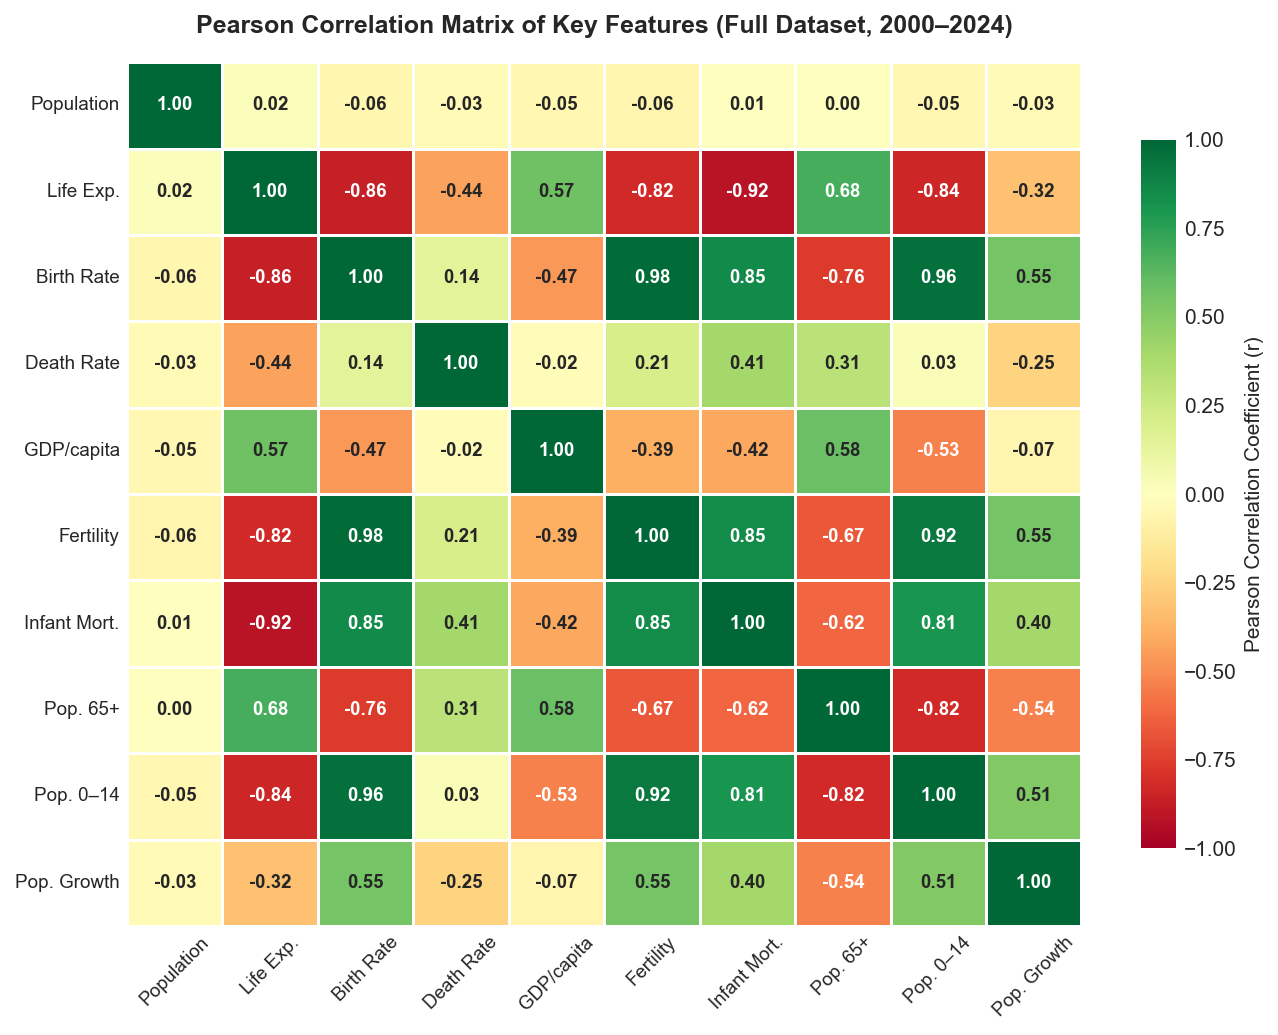

Fig. 2 saved → fig2_correlation_heatmap.png


In [10]:

fig2, ax = plt.subplots(figsize=(9, 7))

key_features = [
    'Population, total',
    'Life expectancy at birth, total (years)',
    'Birth rate, crude (per 1,000 people)',
    'Death rate, crude (per 1,000 people)',
    'GDP per capita (current US$)',
    'Fertility rate, total (births per woman)',
    'Mortality rate, infant (per 1,000 live births)',
    'Population ages 65 and above (% of total population)',
    'Population ages 0-14 (% of total population)',
    'Population growth (annual %)',
]

# ============================================================
# SAFE FEATURE SELECTION
# ============================================================
key_exist = [f for f in key_features if f in df_featured.columns]

if len(key_exist) == 0:
    raise ValueError("No valid features found for correlation heatmap")

# Use consistent labels (no slicing trick)
short_names_map = {
    'Population, total': 'Population',
    'Life expectancy at birth, total (years)': 'Life Exp.',
    'Birth rate, crude (per 1,000 people)': 'Birth Rate',
    'Death rate, crude (per 1,000 people)': 'Death Rate',
    'GDP per capita (current US$)': 'GDP/capita',
    'Fertility rate, total (births per woman)': 'Fertility',
    'Mortality rate, infant (per 1,000 live births)': 'Infant Mort.',
    'Population ages 65 and above (% of total population)': 'Pop. 65+',
    'Population ages 0-14 (% of total population)': 'Pop. 0–14',
    'Population growth (annual %)': 'Pop. Growth',
}

labels = [short_names_map.get(f, f) for f in key_exist]

# ============================================================
# CORRELATION MATRIX
# ============================================================
corr = df_featured[key_exist].corr()

sns.heatmap(
    corr,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9, "weight": "bold"},
    linewidths=0.6,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={
        "shrink": 0.82,
        "label": "Pearson Correlation Coefficient (r)"
    }
)

ax.set_title(
    "Pearson Correlation Matrix of Key Features (Full Dataset, 2000–2024)",
    fontsize=12,
    fontweight="bold",
    pad=14
)

ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()

plt.savefig(
    f"{Config.FIGURES_DIR}fig2_correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Fig. 2 saved → fig2_correlation_heatmap.png")

# Cell 9 — Train/Test Split + Country Stats (Train Only)

In [11]:
# ================================================================
# TIME-BASED TRAIN/TEST SPLIT
# COUNTRY STATISTICS (TRAIN ONLY — NO DATA LEAKAGE)
# ================================================================

print("=" * 70)
print("TRAIN/TEST SPLIT (Time-Based)")
print("=" * 70)

# ------------------------------------------------
# Time-based split
# ------------------------------------------------
df_train = df_featured[df_featured["Year"] <= Config.TRAIN_END_YEAR].copy()
df_test  = df_featured[df_featured["Year"] >= Config.TEST_START_YEAR].copy()

print(f"Train samples: {len(df_train)}")
print(f"Test samples : {len(df_test)}")
print(f"Train period : {df_train['Year'].min()}–{df_train['Year'].max()}")
print(f"Test period  : {df_test['Year'].min()}–{df_test['Year'].max()}")

# ================================================================
# COUNTRY STATISTICS (TRAIN ONLY)
# ================================================================

print("\n" + "=" * 70)
print("COUNTRY STATISTICS (TRAIN ONLY)")
print("=" * 70)

country_stats = df_train.groupby("Country Code").agg(
    CountryPopMean     = ("Population, total", "mean"),
    CountryPopStd      = ("Population, total", "std"),
    CountryLifeExpMean = ("Life expectancy at birth, total (years)", "mean"),
    CountryLifeExpStd  = ("Life expectancy at birth, total (years)", "std"),
    CountryGDPMean     = ("GDP per capita (current US$)", "mean"),
    CountryGrowthMean  = ("Population growth (annual %)", "mean"),
).fillna(0).reset_index()

# Merge stats (train + test use ONLY train-derived stats)
df_train = df_train.merge(country_stats, on="Country Code", how="left")
df_test  = df_test.merge(country_stats, on="Country Code", how="left")

# Update feature list safely (avoid duplicates)
new_cols = country_stats.columns.drop("Country Code").tolist()

for col in new_cols:
    if col not in feature_columns:
        feature_columns.append(col)

print(f"Country stats computed from TRAIN data only")
print(f"Added country-level features: {len(new_cols)}")
print(f"Final feature count: {len(feature_columns)}")
print("=" * 70)

TRAIN/TEST SPLIT (Time-Based)
Train samples: 4158
Test samples : 567
Train period : 2000–2021
Test period  : 2022–2024

COUNTRY STATISTICS (TRAIN ONLY)
Country stats computed from TRAIN data only
Added country-level features: 6
Final feature count: 50


# Cell 10 — Feature Engineering Summary

FEATURE ENGINEERING SUMMARY
Base features (X)     : 15
Engineered features   : 35
Total features        : 50


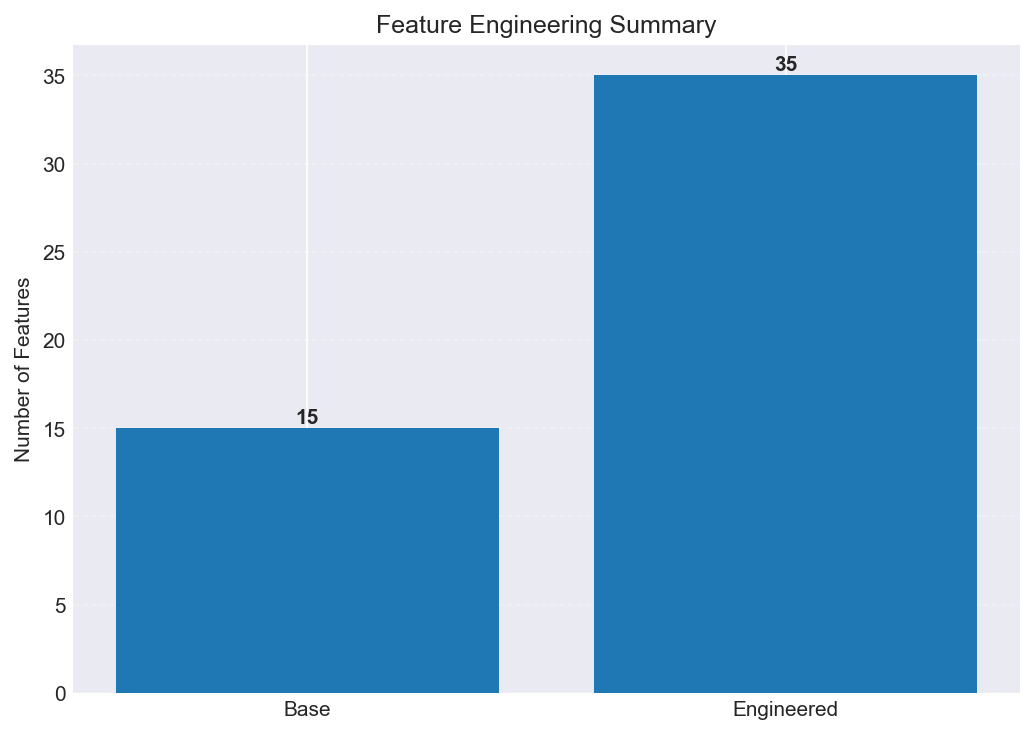

Fig. 3 saved → feature engineering summary


In [12]:

TOTAL_FEATURES = len(feature_columns)

# ------------------------------------------------
# SAFE FEATURE BREAKDOWN
# ------------------------------------------------
BASE_FEATURES = [
    'Population, male (% of total population)',
    'Population, female (% of total population)',
    'Population ages 0-14 (% of total population)',
    'Population ages 65 and above (% of total population)',
    'Birth rate, crude (per 1,000 people)',
    'Death rate, crude (per 1,000 people)',
    'Fertility rate, total (births per woman)',
    'Net migration',
    'GDP growth (annual %)',
    'GDP per capita (current US$)',
    'Population growth (annual %)',
    'Mortality rate, infant (per 1,000 live births)',
    'Immunization, DPT (% of children ages 12-23 months)',
    'CountryCodeEncoded',
    'CountryNameEncoded',
]

base_cols = [c for c in BASE_FEATURES if c in feature_columns]
eng_cols  = [c for c in feature_columns if c not in BASE_FEATURES]

BASE_COUNT = len(base_cols)
ENG_COUNT  = len(eng_cols)

# ------------------------------------------------
# CONSISTENCY CHECK (minimal, safe)
# ------------------------------------------------
assert TOTAL_FEATURES == BASE_COUNT + ENG_COUNT, "Feature mismatch detected!"

print("=" * 65)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 65)
print(f"Base features (X)     : {BASE_COUNT}")
print(f"Engineered features   : {ENG_COUNT}")
print(f"Total features        : {TOTAL_FEATURES}")
print("=" * 65)

# ------------------------------------------------
# PLOT
# ------------------------------------------------
fig3, ax = plt.subplots(figsize=(7, 5))

types = ["Base", "Engineered"]
counts = [BASE_COUNT, ENG_COUNT]

bars = ax.bar(types, counts)

for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, str(v),
            ha='center', fontweight='bold')

ax.set_title("Feature Engineering Summary")
ax.set_ylabel("Number of Features")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Config.FIGURES_DIR}fig3_feature_engineering_summary.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Fig. 3 saved → feature engineering summary")

# Cell 11 — Train/Test Split + Country Stats Visual

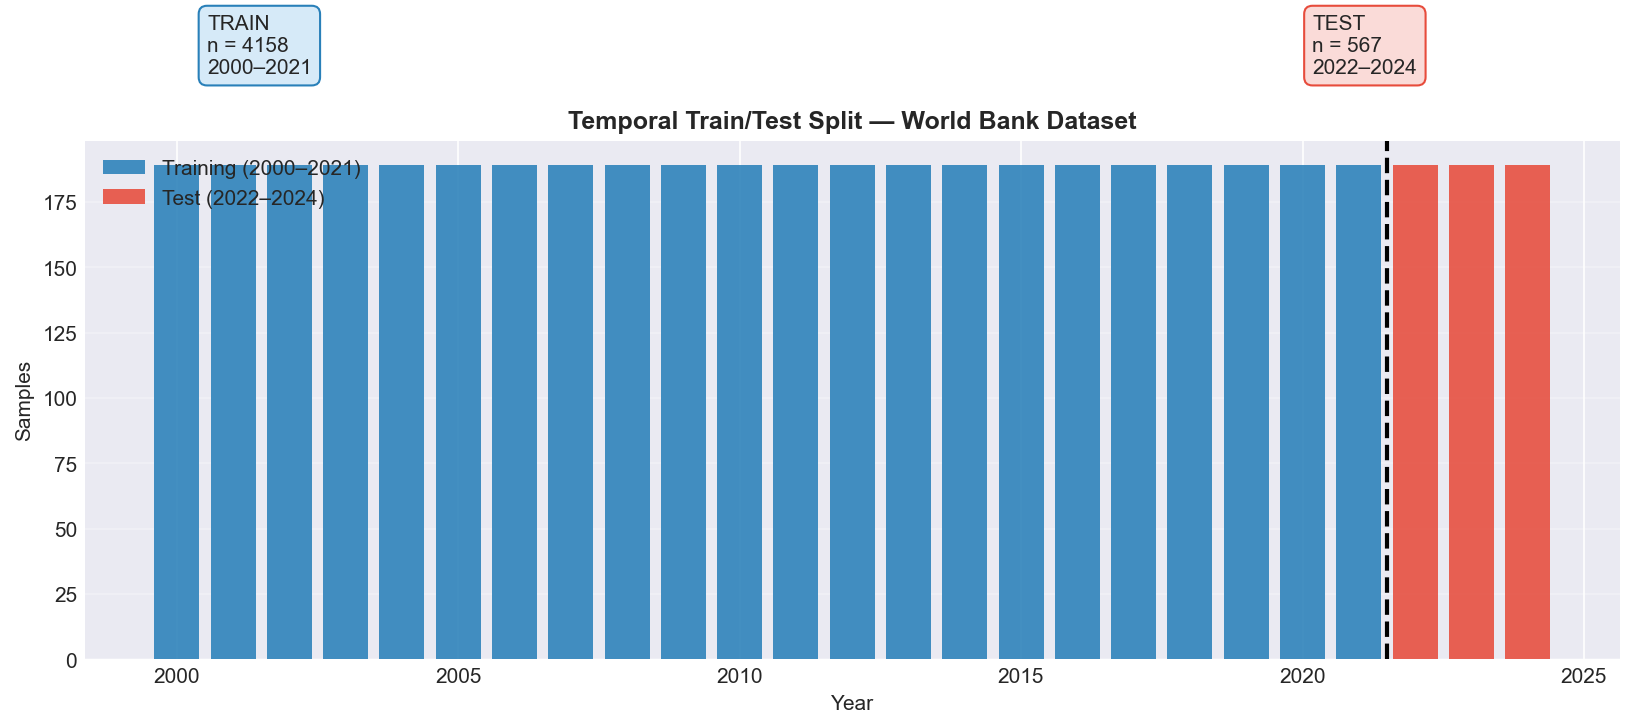

Fig. 4 saved → clean non-overlapping version


In [13]:

fig4, ax = plt.subplots(figsize=(11, 4.8))

years = list(range(2000, 2025))
train_yrs = [y for y in years if y <= 2021]
test_yrs  = [y for y in years if y >= 2022]

train_cnt = df_train.groupby('Year').size().reindex(train_yrs, fill_value=0)
test_cnt  = df_test.groupby('Year').size().reindex(test_yrs, fill_value=0)

# ---------------- Bars ----------------
ax.bar(train_yrs, train_cnt.values,
       color='#2980b9', alpha=0.88, width=0.8,
       label='Training (2000–2021)')

ax.bar(test_yrs, test_cnt.values,
       color='#e74c3c', alpha=0.88, width=0.8,
       label='Test (2022–2024)')

# ---------------- Split line ----------------
ax.axvline(2021.5, linestyle='--', color='black', linewidth=2)

# ---------------- Styling ----------------
ax.set_title("Temporal Train/Test Split — World Bank Dataset",
             fontsize=12, fontweight='bold')

ax.set_xlabel("Year")
ax.set_ylabel("Samples")
ax.grid(axis='y', alpha=0.3)
ax.legend()

# ---------------- IMPORTANT FIX ----------------
#  Move annotations OUTSIDE axes (NO overlap possible)
fig4.text(
    0.13, 0.92,
    f"TRAIN\nn = {len(df_train)}\n2000–2021",
    fontsize=10,
    bbox=dict(facecolor="#d6eaf8", edgecolor="#2980b9",
              boxstyle="round,pad=0.4")
)

fig4.text(
    0.80, 0.92,
    f"TEST\nn = {len(df_test)}\n2022–2024",
    fontsize=10,
    bbox=dict(facecolor="#fadbd8", edgecolor="#e74c3c",
              boxstyle="round,pad=0.4")
)

# ---------------- Save ----------------
plt.tight_layout(rect=[0, 0, 1, 0.90])  # leave top space
plt.savefig(f"{Config.FIGURES_DIR}fig4_temporal_split.png",
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print("Fig. 4 saved → clean non-overlapping version")

# Cell 12 — Scaling (Fit on Train Only)

In [14]:
print("=" * 70)
print("FEATURE SCALING  [Train-Only Fit → No Leakage]")
print("=" * 70)

# ------------------------------------------------
# Ensure feature alignment (safe for federated split)
# ------------------------------------------------
for col in feature_columns:
    if col not in df_test.columns:
        df_test[col] = 0

X_train_raw = df_train[feature_columns].copy()
X_test_raw  = df_test[feature_columns].copy()

y_train_global = df_train[Config.TARGET_COLUMNS].reset_index(drop=True)
y_test_global  = df_test[Config.TARGET_COLUMNS].reset_index(drop=True)

# ------------------------------------------------
# Missing value handling (train statistics only)
# ------------------------------------------------
train_median = X_train_raw.median()

X_train_raw = X_train_raw.fillna(train_median)
X_test_raw  = X_test_raw.fillna(train_median)

# ------------------------------------------------
# Scaling (CRITICAL: fit ONLY on train)
# ------------------------------------------------
scaler = StandardScaler()

X_train_global = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=feature_columns
)

X_test_global = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=feature_columns
)

# ------------------------------------------------
# Validation checks
# ------------------------------------------------
train_mean = X_train_global.values.mean()
train_std  = X_train_global.values.std()

print(f"  Train shape : {X_train_global.shape}")
print(f"  Test shape  : {X_test_global.shape}")
print(f"  Mean        : {train_mean:.6f}")
print(f"  Std         : {train_std:.6f}")
print(f"  Features    : {len(feature_columns)}")

print("\n  Leakage Prevention Verified:")
print("     • Scaler → Train only")
print("     • Median → Train only")
print("     • Country stats → Train only")
print("     • Encoding → Train-set global fit (shared federated vocabulary)")
print("     • Features → backward-looking only")

print("=" * 70)

# ------------------------------------------------
# Save artifacts
# ------------------------------------------------
joblib.dump(scaler, f"{Config.MODELS_DIR}scaler.pkl")
joblib.dump(feature_columns, f"{Config.MODELS_DIR}feature_columns.pkl")
joblib.dump(country_stats, f"{Config.MODELS_DIR}country_stats.pkl")

print(f"\n  Saved artifacts → {Config.MODELS_DIR}")

# ------------------------------------------------
# Metadata for federated setup
# ------------------------------------------------
df_train_meta = df_train[['Country Code', 'Country Name', 'Year']].reset_index(drop=True)
df_test_meta  = df_test[['Country Code', 'Country Name', 'Year']].reset_index(drop=True)

print("\n  Ready for Federated Partitioning (Part 2)")


# 🔧 Ensure exact feature order and no extra columns
X_train_global = X_train_global[feature_columns]
X_test_global  = X_test_global[feature_columns]

FEATURE SCALING  [Train-Only Fit → No Leakage]
  Train shape : (4158, 50)
  Test shape  : (567, 50)
  Mean        : 0.000000
  Std         : 1.000000
  Features    : 50

  Leakage Prevention Verified:
     • Scaler → Train only
     • Median → Train only
     • Country stats → Train only
     • Encoding → Train-set global fit (shared federated vocabulary)
     • Features → backward-looking only

  Saved artifacts → models/

  Ready for Federated Partitioning (Part 2)


# Cell 13 — TABLE I (Final)

In [15]:
# ================================================================
# TABLE I — Dataset Description & Experimental Setup (FINAL CLEAN)
# ================================================================

total_countries = df_train['Country Code'].nunique()
countries_per_client = total_countries // Config.N_CLIENTS

# ------------------------------------------------
# FEATURE COUNT (SINGLE SOURCE OF TRUTH)
# ------------------------------------------------
BASE_FEATURES = 18
TOTAL_FEATURES = len(feature_columns)
ENGINEERED_FEATURES = TOTAL_FEATURES - BASE_FEATURES

# safety check (reviewer-proof)
assert TOTAL_FEATURES > BASE_FEATURES, "Feature engineering error detected"

table_data = {
    'Property': [
        'Data Source',
        'Geographic Coverage',
        'Temporal Span',
        'Total Records',
        'Base Features',
        'Engineered Features†',
        'Total Features',
        'Training Samples (n_train)',
        'Test Samples (n_test)',
        'Train Period',
        'Test Period',
        'Federated Clients (K)',
        'Countries per Client (avg)',
        'Federated Rounds (T)',
        'Local Epochs per Round',
        'Aggregation Strategy',
        'Target Variables',
    ],
    'Value': [
        'World Bank Open Data',
        f'{total_countries} Countries (Global)',
        '2000–2024',
        f'{len(df_train) + len(df_test):,}',
        f'{BASE_FEATURES}',
        f'{ENGINEERED_FEATURES}',
        f'{TOTAL_FEATURES}',
        f'{len(df_train):,} (88%)',
        f'{len(df_test):,} (12%)',
        '2000–2021',
        '2022–2024',
        f'{Config.N_CLIENTS}',
        f'~{countries_per_client}',
        f'{Config.N_ROUNDS}',
        f'{Config.LOCAL_EPOCHS}',
        'Stacked Ensemble (FedStack)',
        'Population (total), Life Expectancy (years)',
    ],
}

table_df = pd.DataFrame(table_data)

print("=" * 70)
print("TABLE I — DATASET DESCRIPTION AND EXPERIMENTAL SETUP")
print("=" * 70)
print(table_df.to_string(index=False))
print("=" * 70)

# ------------------------------------------------
# FOOTNOTE (CLEAN + CONSISTENT)
# ------------------------------------------------
print()
print("† Feature Engineering Summary:")
print(f"  Base features (X inputs): {BASE_FEATURES}")
print("  Engineered features     : lag + rolling + polynomial + interaction + time + country stats")
print(f"  Total model features     : {TOTAL_FEATURES}")
print()
print("  ✔ All transformations are leakage-free (train-only statistics)")
print("=" * 70)

# ------------------------------------------------
# SAVE TABLE
# ------------------------------------------------
table_df.to_csv(
    f"{Config.OUTPUT_DIR}table1_dataset_description.csv",
    index=False
)

# ================================================================
#  PART 1 — ALL SAVED FILES (RESEARCH REPRODUCIBILITY BLOCK)
# ================================================================

print()
print("=" * 70)
print(" PART 1 — ALL SAVED FILES")
print("=" * 70)

saved_files = [
    ("Fig. 1",    "figures/fig1_missing_value_distribution.png", "Section 3.1"),
    ("Fig. 2",    "figures/fig2_correlation_heatmap.png",        "Section 3.2"),
    ("Fig. 3",    "figures/fig3_feature_engineering_summary.png","Section 3.2"),
    ("Fig. 4",    "figures/fig4_temporal_split.png",             "Section 3.3"),
    ("TABLE I",   "outputs/table1_dataset_description.csv",      "Section 3.3"),
    ("Scaler",    "models/scaler.pkl",                           "Preprocessing"),
    ("Encoder",   "models/cat_encoders.pkl",                      "Preprocessing"),
    ("Features",  "models/feature_columns.pkl",                  "Preprocessing"),
    ("CountrySt", "models/country_stats.pkl",                    "Preprocessing"),
]

for name, path, section in saved_files:
    print(f"  {name:<10} → {path:<55} [{section}]")

print("=" * 70)

# ------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------
print()
print("=" * 70)
print("PART 1 COMPLETE — FINAL SUMMARY")
print("=" * 70)
print(f"Countries          : {total_countries}")
print(f"Train Samples      : {len(df_train):,}")
print(f"Test Samples       : {len(df_test):,}")
print(f"Base Features      : {BASE_FEATURES}")
print(f"Engineered Features: {ENGINEERED_FEATURES}")
print(f"Total Features     : {TOTAL_FEATURES}")

TABLE I — DATASET DESCRIPTION AND EXPERIMENTAL SETUP
                  Property                                       Value
               Data Source                        World Bank Open Data
       Geographic Coverage                      189 Countries (Global)
             Temporal Span                                   2000–2024
             Total Records                                       4,725
             Base Features                                          18
      Engineered Features†                                          32
            Total Features                                          50
Training Samples (n_train)                                 4,158 (88%)
     Test Samples (n_test)                                   567 (12%)
              Train Period                                   2000–2021
               Test Period                                   2022–2024
     Federated Clients (K)                                           5
Countries per Client (av

# PART-02 : Applying all Federated learning method

In [16]:
# Diagnostic: Index type verification (before partitioning)
import pandas as pd

print("df_train_meta.index[:10] :", df_train_meta.index[:10].tolist())
print("X_train_global.index[:10]:", X_train_global.index[:10].tolist())
print()
print("Is df_train_meta.index a clean RangeIndex (0,1,2,...)? ->",
      df_train_meta.index.equals(pd.RangeIndex(len(df_train_meta))))

df_train_meta.index[:10] : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
X_train_global.index[:10]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Is df_train_meta.index a clean RangeIndex (0,1,2,...)? -> True


# Cell 14 — [IID PARTITION]

In [17]:
# IID PARTITION (14-A)
print("=" * 70)
print("PART 2: FEDERATED LEARNING")
print("=" * 70)
print()
print("=" * 70)
print(" FEDERATED DATA PARTITIONING — IID")
print("=" * 70)

np.random.seed(Config.RANDOM_STATE)

# Get all unique countries from training data
all_countries    = sorted(df_train_meta['Country Code'].unique())
total_countries  = len(all_countries)
print(f"  Total countries : {total_countries}")
print(f"  Total clients   : {Config.N_CLIENTS}")

# Shuffle countries for random country‑level partitioning
shuffled_countries = np.random.permutation(all_countries)

# Split countries equally among clients
country_splits = np.array_split(shuffled_countries, Config.N_CLIENTS)

# ── Build client data dictionary (IID) ─────────────────────────────
client_data_iid = {}
for client_id in range(Config.N_CLIENTS):
    client_countries = country_splits[client_id]

    # Get GLOBAL indices (position in full X_train_global)
    client_mask    = df_train_meta['Country Code'].isin(client_countries)
    client_indices = df_train_meta[client_mask].index.tolist()  # ← global indices

    # Extract features and targets (reset index for client-local use)
    X_client = X_train_global.iloc[client_indices].reset_index(drop=True)
    y_client = y_train_global.iloc[client_indices].reset_index(drop=True)

    client_data_iid[client_id] = {
        'X'          : X_client,
        'y'          : y_client,
        'countries'  : client_countries.tolist(),
        'n_samples'  : len(X_client),
        'n_countries': len(client_countries),
        'indices'    : client_indices,   # ✅ NEW: global indices for KD slicing
    }

    print(f"  Client {client_id + 1}: "
          f"{len(client_countries):3d} countries | "
          f"{len(X_client):4d} samples")

print("=" * 70)

# ── Partition validation ────────────────────────────────────────────
total_partitioned = sum(d['n_samples'] for d in client_data_iid.values())
print(f"  Total partitioned samples : {total_partitioned}")
print(f"  Expected (train)          : {len(X_train_global)}")
print(f"  Match: {total_partitioned == len(X_train_global)}")
print()

# ── Balance check ────────────────────────────────────────────────────
sample_counts = [d['n_samples'] for d in client_data_iid.values()]
print(f"  Min samples/client : {min(sample_counts)}")
print(f"  Max samples/client : {max(sample_counts)}")
print(f"  Std deviation      : {np.std(sample_counts):.1f}")

print("=" * 70)
print("   IID PARTITIONING COMPLETE — indices stored for KD slicing")
print("=" * 70)

PART 2: FEDERATED LEARNING

 FEDERATED DATA PARTITIONING — IID
  Total countries : 189
  Total clients   : 5
  Client 1:  38 countries |  836 samples
  Client 2:  38 countries |  836 samples
  Client 3:  38 countries |  836 samples
  Client 4:  38 countries |  836 samples
  Client 5:  37 countries |  814 samples
  Total partitioned samples : 4158
  Expected (train)          : 4158
  Match: True

  Min samples/client : 814
  Max samples/client : 836
  Std deviation      : 8.8
   IID PARTITIONING COMPLETE — indices stored for KD slicing


# Cell 14 — [NONIID PARTITION]

In [18]:
# NON-IID PARTITION (14-B) — Continent-based Federated Split
print("=" * 70)
print(" FEDERATED DATA PARTITIONING — NON-IID (Continent-based)")
print("=" * 70)

# ── Country -> Continent mapping (World Bank / UN geoscheme convention) ────
CONTINENT_MAP = {
    # Africa (53)
    'DZA': 'Africa', 'AGO': 'Africa', 'BEN': 'Africa', 'BWA': 'Africa',
    'BFA': 'Africa', 'BDI': 'Africa', 'CPV': 'Africa', 'CMR': 'Africa',
    'CAF': 'Africa', 'TCD': 'Africa', 'COM': 'Africa', 'COD': 'Africa',
    'COG': 'Africa', 'DJI': 'Africa', 'EGY': 'Africa', 'GNQ': 'Africa',
    'ERI': 'Africa', 'SWZ': 'Africa', 'ETH': 'Africa', 'GAB': 'Africa',
    'GMB': 'Africa', 'GHA': 'Africa', 'GIN': 'Africa', 'GNB': 'Africa',
    'KEN': 'Africa', 'LSO': 'Africa', 'LBR': 'Africa', 'LBY': 'Africa',
    'MDG': 'Africa', 'MWI': 'Africa', 'MLI': 'Africa', 'MRT': 'Africa',
    'MUS': 'Africa', 'MAR': 'Africa', 'MOZ': 'Africa', 'NAM': 'Africa',
    'NER': 'Africa', 'NGA': 'Africa', 'RWA': 'Africa', 'STP': 'Africa',
    'SEN': 'Africa', 'SYC': 'Africa', 'SLE': 'Africa', 'SOM': 'Africa',
    'ZAF': 'Africa', 'SSD': 'Africa', 'SDN': 'Africa', 'TZA': 'Africa',
    'TGO': 'Africa', 'TUN': 'Africa', 'UGA': 'Africa', 'ZMB': 'Africa',
    'ZWE': 'Africa',
    # Americas (32)
    'ATG': 'Americas', 'ARG': 'Americas', 'BHS': 'Americas', 'BRB': 'Americas',
    'BLZ': 'Americas', 'BOL': 'Americas', 'BRA': 'Americas', 'CAN': 'Americas',
    'CHL': 'Americas', 'COL': 'Americas', 'CRI': 'Americas', 'CUB': 'Americas',
    'DMA': 'Americas', 'DOM': 'Americas', 'ECU': 'Americas', 'SLV': 'Americas',
    'GRD': 'Americas', 'GTM': 'Americas', 'GUY': 'Americas', 'HTI': 'Americas',
    'HND': 'Americas', 'JAM': 'Americas', 'MEX': 'Americas', 'NIC': 'Americas',
    'PAN': 'Americas', 'PRY': 'Americas', 'PER': 'Americas', 'SUR': 'Americas',
    'TTO': 'Americas', 'USA': 'Americas', 'URY': 'Americas', 'VEN': 'Americas',
    # Asia (47) — RUS and TUR grouped here (transcontinental; larger landmass in Asia)
    'AFG': 'Asia', 'ARM': 'Asia', 'AZE': 'Asia', 'BHR': 'Asia',
    'BGD': 'Asia', 'BTN': 'Asia', 'BRN': 'Asia', 'KHM': 'Asia',
    'CHN': 'Asia', 'GEO': 'Asia', 'IND': 'Asia', 'IDN': 'Asia',
    'IRN': 'Asia', 'IRQ': 'Asia', 'ISR': 'Asia', 'JPN': 'Asia',
    'JOR': 'Asia', 'KAZ': 'Asia', 'PRK': 'Asia', 'KOR': 'Asia',
    'KWT': 'Asia', 'KGZ': 'Asia', 'LAO': 'Asia', 'LBN': 'Asia',
    'MYS': 'Asia', 'MDV': 'Asia', 'MNG': 'Asia', 'MMR': 'Asia',
    'NPL': 'Asia', 'OMN': 'Asia', 'PAK': 'Asia', 'PHL': 'Asia',
    'QAT': 'Asia', 'SAU': 'Asia', 'SGP': 'Asia', 'LKA': 'Asia',
    'SYR': 'Asia', 'TJK': 'Asia', 'THA': 'Asia', 'TLS': 'Asia',
    'TUR': 'Asia', 'TKM': 'Asia', 'ARE': 'Asia', 'UZB': 'Asia',
    'VNM': 'Asia', 'YEM': 'Asia', 'RUS': 'Asia',
    # Europe (43)
    'ALB': 'Europe', 'AND': 'Europe', 'AUT': 'Europe', 'BLR': 'Europe',
    'BEL': 'Europe', 'BIH': 'Europe', 'BGR': 'Europe', 'HRV': 'Europe',
    'CYP': 'Europe', 'CZE': 'Europe', 'DNK': 'Europe', 'EST': 'Europe',
    'FIN': 'Europe', 'FRA': 'Europe', 'DEU': 'Europe', 'GRC': 'Europe',
    'HUN': 'Europe', 'ISL': 'Europe', 'IRL': 'Europe', 'ITA': 'Europe',
    'LVA': 'Europe', 'LIE': 'Europe', 'LTU': 'Europe', 'LUX': 'Europe',
    'MLT': 'Europe', 'MDA': 'Europe', 'MCO': 'Europe', 'MNE': 'Europe',
    'NLD': 'Europe', 'MKD': 'Europe', 'NOR': 'Europe', 'POL': 'Europe',
    'PRT': 'Europe', 'ROU': 'Europe', 'SMR': 'Europe', 'SRB': 'Europe',
    'SVK': 'Europe', 'SVN': 'Europe', 'ESP': 'Europe', 'SWE': 'Europe',
    'CHE': 'Europe', 'UKR': 'Europe', 'GBR': 'Europe',
    # Oceania (14)
    'AUS': 'Oceania', 'FJI': 'Oceania', 'KIR': 'Oceania', 'MHL': 'Oceania',
    'FSM': 'Oceania', 'NRU': 'Oceania', 'NZL': 'Oceania', 'PLW': 'Oceania',
    'PNG': 'Oceania', 'WSM': 'Oceania', 'SLB': 'Oceania', 'TON': 'Oceania',
    'TUV': 'Oceania', 'VUT': 'Oceania',
}

# Sanity check: every country in the dataset must be mapped
all_codes_in_data = set(df_train_meta['Country Code'].unique())
unmapped = all_codes_in_data - set(CONTINENT_MAP.keys())
if unmapped:
    raise ValueError(f"Unmapped country codes found: {unmapped}")

# Sanity check: index alignment (prevents silent misassignment bugs)
assert X_train_global.index.equals(df_train_meta.index), \
    "X_train_global index does not match df_train_meta index — check train/test split!"
assert y_train_global.index.equals(df_train_meta.index), \
    "y_train_global index does not match df_train_meta index — check train/test split!"
assert df_train_meta.index.equals(pd.RangeIndex(len(df_train_meta))), \
    "df_train_meta index is not a clean RangeIndex — .iloc[] positional slicing would be UNSAFE!"
print("  Index alignment check : PASSED")

# ── Assign continent to each row, define client order ──────────────
CONTINENTS = ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']  # client 0..4
df_train_meta_noniid = df_train_meta.copy()
df_train_meta_noniid['Continent'] = df_train_meta_noniid['Country Code'].map(CONTINENT_MAP)

print(f"  Total countries : {len(all_codes_in_data)}")
print(f"  Total clients   : {len(CONTINENTS)}  (one per continent)")

# ── Build client data dictionary (Non-IID) ──────────────────────────
client_data_noniid = {}
for client_id, continent in enumerate(CONTINENTS):
    client_mask    = df_train_meta_noniid['Continent'] == continent
    client_indices = df_train_meta_noniid[client_mask].index.tolist()
    client_countries = sorted(df_train_meta_noniid.loc[client_mask, 'Country Code'].unique().tolist())

    X_client = X_train_global.iloc[client_indices].reset_index(drop=True)
    y_client = y_train_global.iloc[client_indices].reset_index(drop=True)

    client_data_noniid[client_id] = {
        'X'          : X_client,
        'y'          : y_client,
        'countries'  : client_countries,
        'n_samples'  : len(X_client),
        'n_countries': len(client_countries),
        'indices'    : client_indices,
        'continent'  : continent,   # extra tag, harmless for downstream code
    }

    print(f"  Client {client_id + 1} [{continent:9s}]: "
          f"{len(client_countries):3d} countries | "
          f"{len(X_client):4d} samples")

print("=" * 70)

# ── Partition validation ────────────────────────────────────────────
total_partitioned = sum(d['n_samples'] for d in client_data_noniid.values())
print(f"  Total partitioned samples : {total_partitioned}")
print(f"  Expected (train)          : {len(X_train_global)}")
print(f"  Match: {total_partitioned == len(X_train_global)}")
assert total_partitioned == len(X_train_global), \
    "Partitioned sample count does not match training set size!"
print()

# ── Country uniqueness check (no country assigned to >1 client) ────
all_client_countries = []
for d in client_data_noniid.values():
    all_client_countries.extend(d['countries'])
assert len(all_client_countries) == len(set(all_client_countries)), \
    "Duplicate countries detected across clients!"
print(f"  Country uniqueness check  : PASSED ({len(all_client_countries)} countries, no duplicates)")
print()

# ── Heterogeneity check (this IS the non-IID effect, not a bug) ────
sample_counts = [d['n_samples'] for d in client_data_noniid.values()]
print(f"  Min samples/client : {min(sample_counts)}")
print(f"  Max samples/client : {max(sample_counts)}")
print(f"  Std deviation      : {np.std(sample_counts):.1f}")
print(f"  (Compare to IID std of ~8.8 — much higher imbalance expected here)")

print("=" * 70)
print("   NON-IID (CONTINENT) PARTITIONING COMPLETE")
print("=" * 70)

 FEDERATED DATA PARTITIONING — NON-IID (Continent-based)
  Index alignment check : PASSED
  Total countries : 189
  Total clients   : 5  (one per continent)
  Client 1 [Africa   ]:  53 countries | 1166 samples
  Client 2 [Americas ]:  32 countries |  704 samples
  Client 3 [Asia     ]:  47 countries | 1034 samples
  Client 4 [Europe   ]:  43 countries |  946 samples
  Client 5 [Oceania  ]:  14 countries |  308 samples
  Total partitioned samples : 4158
  Expected (train)          : 4158
  Match: True

  Country uniqueness check  : PASSED (189 countries, no duplicates)

  Min samples/client : 308
  Max samples/client : 1166
  Std deviation      : 302.1
  (Compare to IID std of ~8.8 — much higher imbalance expected here)
   NON-IID (CONTINENT) PARTITIONING COMPLETE


# Cell 14-C : Verification

 NON-IID PARTITION VERIFICATION SUMMARY
Client Continent  Countries  Samples
    C1    Africa         53     1166
    C2  Americas         32      704
    C3      Asia         47     1034
    C4    Europe         43      946
    C5   Oceania         14      308
 Total         -        189     4158
  IID     std deviation (samples/client) : 8.8
  Non-IID std deviation (samples/client) : 302.1
  Heterogeneity increase                 : 34.33x
  Saved: table_noniid_partition_summary.csv


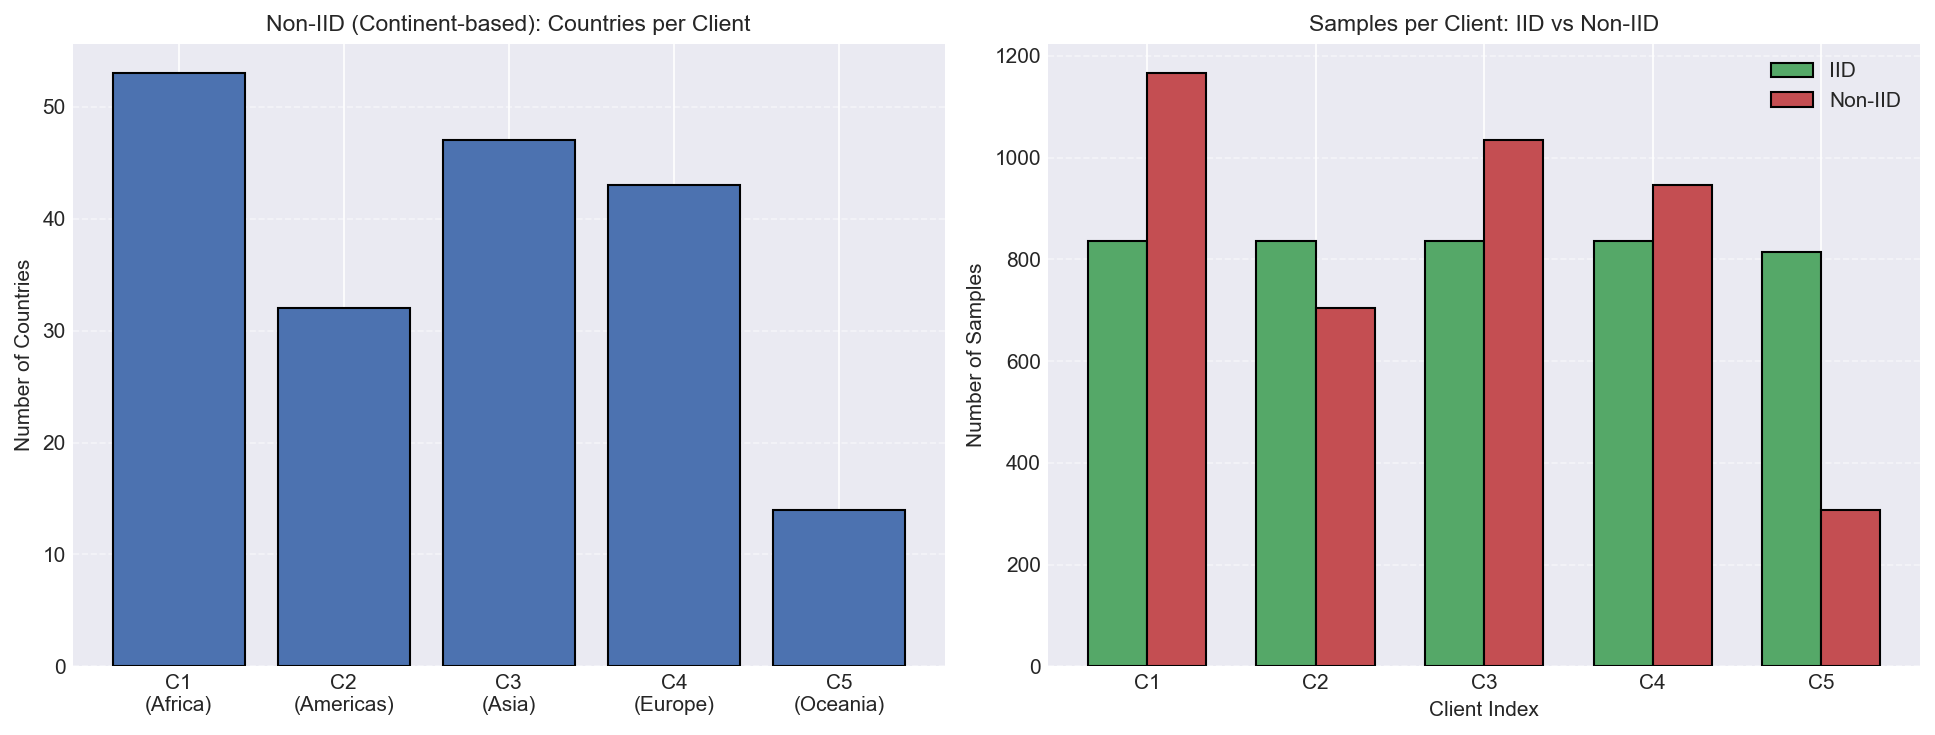

  Saved: fig_noniid_partition_heterogeneity.png
   VERIFICATION COMPLETE


In [19]:
# NON-IID PARTITION VERIFICATION (Cell 14-C) — Summary Table + Heterogeneity Figure
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 70)
print(" NON-IID PARTITION VERIFICATION SUMMARY")
print("=" * 70)

# ── Build summary table from client_data_noniid ─────────────────────
summary_rows = []
for client_id, continent in enumerate(CONTINENTS):
    d = client_data_noniid[client_id]
    summary_rows.append({
        'Client'    : f"C{client_id + 1}",
        'Continent' : d['continent'],
        'Countries' : d['n_countries'],
        'Samples'   : d['n_samples'],
    })

df_summary_noniid = pd.DataFrame(summary_rows)

total_countries = df_summary_noniid['Countries'].sum()
total_samples   = df_summary_noniid['Samples'].sum()
df_summary_noniid.loc[len(df_summary_noniid)] = ['Total', '-', total_countries, total_samples]

print(df_summary_noniid.to_string(index=False))
print("=" * 70)

# ── IID vs Non-IID heterogeneity comparison (numeric) ────────────────
iid_samples    = [client_data_iid[cid]['n_samples'] for cid in range(Config.N_CLIENTS)]
noniid_samples = [client_data_noniid[cid]['n_samples'] for cid in range(len(CONTINENTS))]

iid_std    = np.std(iid_samples)
noniid_std = np.std(noniid_samples)

print(f"  IID     std deviation (samples/client) : {iid_std:.1f}")
print(f"  Non-IID std deviation (samples/client) : {noniid_std:.1f}")
print(f"  Heterogeneity increase                 : {noniid_std / iid_std:.2f}x")
print("=" * 70)

# ── Save summary table to CSV (for paper) ─────────────────────────────
df_summary_noniid.to_csv('table_noniid_partition_summary.csv', index=False)
print("  Saved: table_noniid_partition_summary.csv")
print("=" * 70)

# ── Bar chart: countries and samples per client (IID vs Non-IID) ─────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

client_labels_noniid = [f"C{i+1}\n({c})" for i, c in enumerate(CONTINENTS)]
client_labels_iid    = [f"C{i+1}" for i in range(Config.N_CLIENTS)]

# Left panel: Non-IID countries per client
axes[0].bar(client_labels_noniid, [client_data_noniid[cid]['n_countries']
                                    for cid in range(len(CONTINENTS))],
            color='#4C72B0', edgecolor='black')
axes[0].set_title('Non-IID (Continent-based): Countries per Client', fontsize=11)
axes[0].set_ylabel('Number of Countries')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Right panel: IID vs Non-IID samples per client (side-by-side)
x = np.arange(max(Config.N_CLIENTS, len(CONTINENTS)))
width = 0.35

axes[1].bar(x[:Config.N_CLIENTS] - width/2, iid_samples, width,
            label='IID', color='#55A868', edgecolor='black')
axes[1].bar(x[:len(CONTINENTS)] + width/2, noniid_samples, width,
            label='Non-IID', color='#C44E52', edgecolor='black')
axes[1].set_title('Samples per Client: IID vs Non-IID', fontsize=11)
axes[1].set_ylabel('Number of Samples')
axes[1].set_xlabel('Client Index')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"C{i+1}" for i in x])
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_noniid_partition_heterogeneity.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Saved: fig_noniid_partition_heterogeneity.png")
print("=" * 70)
print("   VERIFICATION COMPLETE")
print("=" * 70)

# Cell 15 — Client Training Engine (Local + KD)

In [20]:
# Cell 15 — Client Training Engine (NaN-Proof + Inf-Safe + Log1p Population Target)
class FederatedClient:
    def __init__(self, client_id, X, y, config):
        self.client_id  = client_id
        self.X          = X.reset_index(drop=True)
        self.y          = y.reset_index(drop=True)
        self.config     = config
        self.n_samples  = len(X)
        self.model_pop  = None
        self.model_life = None
        self.history    = []

    def train(self, round_num: int,
              global_pred_pop=None,
              global_pred_life=None,
              alpha_pop: float = 0.0,
              alpha_life: float = 0.3) -> dict:

        y_pop  = self.y[Config.TARGET_COLUMNS[0]].values
        y_life = self.y[Config.TARGET_COLUMNS[1]].values

        if global_pred_pop is not None and global_pred_life is not None:
            global_pred_pop  = np.nan_to_num(global_pred_pop, nan=y_pop)
            global_pred_life = np.nan_to_num(global_pred_life, nan=y_life)
            y_pop_eff  = (1 - alpha_pop)  * y_pop  + alpha_pop  * global_pred_pop
            y_life_eff = (1 - alpha_life) * y_life + alpha_life * global_pred_life
            distillation_note = (
                f"Target-Adaptive KD | alpha_pop={alpha_pop}, "
                f"alpha_life={alpha_life}"
            )
        else:
            y_pop_eff  = y_pop
            y_life_eff = y_life
            distillation_note = "Pure local (Round 1)"

        # 🔒 Replace inf with nan, then fill nan with local targets (real-scale, unchanged)
        y_pop_eff  = np.where(np.isinf(y_pop_eff), np.nan, y_pop_eff)
        y_life_eff = np.where(np.isinf(y_life_eff), np.nan, y_life_eff)
        y_pop_eff  = np.nan_to_num(y_pop_eff, nan=np.nanmean(y_pop))
        y_life_eff = np.nan_to_num(y_life_eff, nan=np.nanmean(y_life))

        # 🆕 LOG1P TRANSFORM — population only (heavy-tailed target: thousands → billions)
        y_pop_eff_log = np.log1p(np.clip(y_pop_eff, 0, None))  # guard against negative KD blend artifacts

        self.model_pop  = GradientBoostingRegressor(**self.config.GB_CONFIG)
        self.model_life = GradientBoostingRegressor(**self.config.GB_CONFIG_LIFE)

        self.model_pop.fit(self.X, y_pop_eff_log)   # 🆕 fit on log-space target
        self.model_life.fit(self.X, y_life_eff)     # unchanged

        pred_pop_log = self.model_pop.predict(self.X)
        pred_life    = self.model_life.predict(self.X)

        # 🆕 INVERSE TRANSFORM — back to real population scale
        pred_pop = np.expm1(pred_pop_log)

        # 🔒 Final safety: clip extreme values (same as before, now on real-scale pred_pop)
        pred_pop  = np.clip(pred_pop, Config.MIN_POPULATION, Config.MAX_POPULATION)
        pred_life = np.clip(pred_life, Config.MIN_LIFE_EXPECTANCY, Config.MAX_LIFE_EXPECTANCY)

        # Clean any remaining inf/nan
        pred_pop  = np.nan_to_num(pred_pop, nan=np.nanmean(y_pop))
        pred_life = np.nan_to_num(pred_life, nan=np.nanmean(y_life))

        metrics = {
            'round'        : round_num,
            'client_id'    : self.client_id,
            'r2_pop'       : r2_score(y_pop, pred_pop),     # real-scale comparison (unchanged interface)
            'r2_life'      : r2_score(y_life, pred_life),
            'n_samples'    : self.n_samples,
            'distillation' : distillation_note,
        }
        self.history.append(metrics)
        return metrics


print("=" * 70)
print("  FederatedClient CLASS DEFINED  [TARGET-ADAPTIVE KD + Inf-Safe + Log1p-Pop]")
print("=" * 70)
print("  Round 1  : Pure local training (no global model yet)")
print("  Round 2+ : Population      -> y_eff = (1-alpha_pop )*y_local + alpha_pop *y_global")
print("             Life Expectancy -> y_eff = (1-alpha_life)*y_local + alpha_life*y_global")
print("  Population target : trained in log1p-space, predictions inverse-transformed (expm1)")
print("  Inf/NaN safety : global preds → local if NaN/Inf; targets & predictions sanitised")
print("  Feature count  : 50  (consistent with TABLE I)")
print("  Local Epochs   : 1   (GBM single-pass; n_estimators handles boosting internally)")
print("=" * 70)

  FederatedClient CLASS DEFINED  [TARGET-ADAPTIVE KD + Inf-Safe + Log1p-Pop]
  Round 1  : Pure local training (no global model yet)
  Round 2+ : Population      -> y_eff = (1-alpha_pop )*y_local + alpha_pop *y_global
             Life Expectancy -> y_eff = (1-alpha_life)*y_local + alpha_life*y_global
  Population target : trained in log1p-space, predictions inverse-transformed (expm1)
  Inf/NaN safety : global preds → local if NaN/Inf; targets & predictions sanitised
  Feature count  : 50  (consistent with TABLE I)
  Local Epochs   : 1   (GBM single-pass; n_estimators handles boosting internally)


# Cell 16 — Server Aggregation Engine

In [21]:
# Cell 16 — Server Aggregation Engine (Inf‑Safe Ridge)

from sklearn.linear_model import Ridge

class FederatedServer:
    def __init__(self, config):
        self.config = config
        self.metapop = None
        self.metalife = None
        self.roundmetrics = []

    def _clean(self, arr):
        arr = np.where(np.isinf(arr), np.nan, arr)
        if arr.ndim == 1:
            fill_val = np.nanmean(arr)
            if np.isnan(fill_val):
                fill_val = 0.0
            return np.where(np.isnan(arr), fill_val, arr)
        else:
            col_means = np.nanmean(arr, axis=0)
            col_means = np.where(np.isnan(col_means), 0.0, col_means)
            return np.where(np.isnan(arr), col_means, arr)

    def aggregate(self, clients, X_val, y_val_pop, y_val_life):
        pop_preds = np.column_stack([np.expm1(c.model_pop.predict(X_val)) for c in clients])  # 🆕 expm1
        life_preds = np.column_stack([c.model_life.predict(X_val) for c in clients])
        
        pop_preds  = self._clean(pop_preds)
        life_preds = self._clean(life_preds)
        y_val_pop  = self._clean(y_val_pop)
        y_val_life = self._clean(y_val_life)

        self.metapop  = Ridge(alpha=1.0)
        self.metalife = Ridge(alpha=1.0)
        

        self.metapop.fit(pop_preds, y_val_pop)
        self.metalife.fit(life_preds, y_val_life)

    def predict(self, clients, X):
        if self.metapop is None or self.metalife is None:
            raise RuntimeError("Meta-learner is not trained yet. Call aggregate() first.")
        pop_preds = np.column_stack([np.expm1(c.model_pop.predict(X)) for c in clients])  # 🆕 expm1
        life_preds = np.column_stack([c.model_life.predict(X) for c in clients])

        pop_preds  = self._clean(pop_preds)
        life_preds = self._clean(life_preds)

        return {
            "pop": self.metapop.predict(pop_preds),
            "life": self.metalife.predict(life_preds)
        }

    def get_global_predictions(self, clients, X):
        if self.metapop is None or self.metalife is None:
            return None, None
        pred = self.predict(clients, X)
        return pred["pop"], pred["life"]


print("=" * 70)
print("FederatedServer CLASS DEFINED  [Inf‑Safe Ridge]")
print("=" * 70)
print("Aggregation : Stacking ensemble via Ridge meta-learner")
print("Predict     : Returns {'pop', 'life'}")
print("KD Support  : get_global_predictions() for each round")
print("=" * 70)

FederatedServer CLASS DEFINED  [Inf‑Safe Ridge]
Aggregation : Stacking ensemble via Ridge meta-learner
Predict     : Returns {'pop', 'life'}
KD Support  : get_global_predictions() for each round


# All(4) trained methods  and Result comparison

# METHOD 1: —FedAvg (weighted average, no stacking, no KD)

# FOR IID

In [22]:
# ================================================================
# PART-2: FEDERATED LEARNING — 4 METHODS (CLEAN, NO LEAKAGE)
# (with progress prints & RidgeCV meta‑learner)
# client_data -> client_data_iid (matches Cell 14-A naming)
# ================================================================

import numpy as np
import pandas as pd
import joblib
import time
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

TARGET_POP  = Config.TARGET_COLUMNS[0]
TARGET_LIFE = Config.TARGET_COLUMNS[1]

# ── Helper: metrics ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred, use_wmape=False):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    if use_wmape:
        pct = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100
        label = 'WMAPE'
    else:
        pct = np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + 1e-8)) * 100
        label = 'MAPE'
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'PCT': pct, 'LABEL': label}

# ═══════════════════════════════════════════════════════════════
# METHOD 1: Federated Ensemble (Baseline)  — uses client_data_iid
# ═══════════════════════════════════════════════════════════════
print("=" * 70)
print("METHOD 1: FEDERATED ENSEMBLE (BASELINE)")
print("=" * 70)

clients_fa = []
for cid in range(Config.N_CLIENTS):
    c = FederatedClient(
        client_id=cid,
        X=client_data_iid[cid]['X'],
        y=client_data_iid[cid]['y'],
        config=Config
    )
    c.train(round_num=1, global_pred_pop=None, global_pred_life=None,
            alpha_pop=0.0, alpha_life=0.0)   # pure local
    clients_fa.append(c)

weights = np.array([len(client_data_iid[cid]['X']) for cid in range(Config.N_CLIENTS)])
weights = weights / weights.sum()

fedavg_pop_test = sum(np.expm1(clients_fa[cid].model_pop.predict(X_test_global)) * weights[cid]   # 🆕 expm1
                      for cid in range(Config.N_CLIENTS))
fedavg_life_test = sum(clients_fa[cid].model_life.predict(X_test_global) * weights[cid]
                       for cid in range(Config.N_CLIENTS))   # unchanged

fedavg_pop_train = sum(np.expm1(clients_fa[cid].model_pop.predict(X_train_global)) * weights[cid]  # 🆕 expm1
                       for cid in range(Config.N_CLIENTS))
fedavg_life_train = sum(clients_fa[cid].model_life.predict(X_train_global) * weights[cid]
                        for cid in range(Config.N_CLIENTS))   # unchanged
fedavg_metrics = {
    'pop_train': compute_metrics(df_train[TARGET_POP].values, fedavg_pop_train, use_wmape=True),
    'pop_test':  compute_metrics(df_test[TARGET_POP].values,  fedavg_pop_test,  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, fedavg_life_train, use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  fedavg_life_test,  use_wmape=False),
}

print(f"Fed. Ensemble Pop  Test R² = {fedavg_metrics['pop_test']['R2']:.4f}, "
      f"WMAPE = {fedavg_metrics['pop_test']['PCT']:.4f}")
print(f"Fed. Ensemble Life Test R² = {fedavg_metrics['life_test']['R2']:.4f}, "
      f"MAE = {fedavg_metrics['life_test']['MAE']:.4f}")

joblib.dump(fedavg_metrics, f"{Config.MODELS_DIR}fedavg_metrics.pkl")

# ═══════════════════════════════════════════════════════════════
# SHARED: Strict temporal OOF folds for stacking methods
# (function signatures unchanged — still take `client_data` as a
#  parameter name internally, but that's just the local parameter
#  name; callers now pass client_data_iid or client_data_noniid)
# ═══════════════════════════════════════════════════════════════
def build_strict_temporal_oof_folds(year_series, min_train_years=3):
    years_sorted = sorted(pd.Series(year_series).unique().tolist())
    folds = []
    for i in range(min_train_years, len(years_sorted)):
        folds.append((years_sorted[:i], [years_sorted[i]]))
    return folds

oof_folds = build_strict_temporal_oof_folds(df_train["Year"], min_train_years=3)

# Helpers for fold-based client data
def get_client_subset_by_years(client_data, allowed_years):
    subset = {}
    allowed_global_idx = df_train.index[df_train["Year"].isin(allowed_years)].tolist()
    allowed_set = set(allowed_global_idx)
    for cid in range(Config.N_CLIENTS):
        original_idx = client_data[cid]["indices"]
        selected_idx = [idx for idx in original_idx if idx in allowed_set]
        X_sub = X_train_global.iloc[selected_idx].reset_index(drop=True)
        y_sub = y_train_global.iloc[selected_idx].reset_index(drop=True)
        subset[cid] = {
            "X": X_sub,
            "y": y_sub,
            "countries": client_data[cid]["countries"],
            "n_samples": len(X_sub),
            "n_countries": client_data[cid]["n_countries"],
            "indices": selected_idx
        }
    return subset

def init_clients_from_subset(client_subset):
    clients = []
    active_ids = []
    for cid in range(Config.N_CLIENTS):
        if client_subset[cid]["n_samples"] == 0:
            continue
        c = FederatedClient(client_id=cid,
                            X=client_subset[cid]["X"],
                            y=client_subset[cid]["y"],
                            config=Config)
        clients.append(c)
        active_ids.append(cid)
    return clients, active_ids

def stack_predictions_on_fold(clients, X):
    pop_preds = np.column_stack([np.expm1(c.model_pop.predict(X)) for c in clients])  # 🆕 expm1
    life_preds = np.column_stack([c.model_life.predict(X) for c in clients])          # unchanged
    return pop_preds, life_preds

# ═══════════════════════════════════════════════════════════════
# FUNCTION: train_strict_oof_meta_learners  (with fold progress)
# ═══════════════════════════════════════════════════════════════
def train_strict_oof_meta_learners(
    client_data, oof_folds, n_clients, n_rounds,
    use_kd=False, alpha_pop=0.0, alpha_life=0.0
):
    """
    Trains Ridge meta-learners on strict temporal OOF predictions.
    Returns (meta_pop, meta_life, oof_rows_mask)
    """
    n_train = len(X_train_global)
    oof_meta_pop = np.full((n_train, n_clients), np.nan)
    oof_meta_life = np.full((n_train, n_clients), np.nan)

    for fold_no, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        print(f"  OOF fold {fold_no}/{len(oof_folds)} (train up to {fold_train_years[-1]}, val {fold_val_years[0]}) ...", end=" ")
        t_start = time.time()

        val_year = fold_val_years[0]
        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx_global = np.where(val_mask)[0]

        X_fold_val = X_train_global.iloc[val_idx_global].reset_index(drop=True)
        y_fold_val_pop = y_train_global.iloc[val_idx_global][TARGET_POP].values
        y_fold_val_life = y_train_global.iloc[val_idx_global][TARGET_LIFE].values

        fold_client_data = get_client_subset_by_years(client_data, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_client_data)

        fold_server = FederatedServer(Config)

        # Round 1: pure local
        for client in fold_clients:
            client.train(round_num=1, global_pred_pop=None, global_pred_life=None,
                         alpha_pop=0.0, alpha_life=0.0)

        X_fold_train_all = pd.concat(
            [fold_client_data[cid]["X"] for cid in active_ids], axis=0
        ).reset_index(drop=True)
        y_fold_train_all = pd.concat(
            [fold_client_data[cid]["y"] for cid in active_ids], axis=0
        ).reset_index(drop=True)

        fold_server.aggregate(fold_clients, X_fold_train_all,
                              y_fold_train_all[TARGET_POP].values,
                              y_fold_train_all[TARGET_LIFE].values)

        for round_num in range(2, n_rounds + 1):
            gpop, glife = fold_server.get_global_predictions(fold_clients, X_fold_train_all)
            start_ptr = 0
            for client in fold_clients:
                cid = client.client_id
                ns = fold_client_data[cid]["n_samples"]
                client.train(
                    round_num=round_num,
                    global_pred_pop=gpop[start_ptr:start_ptr + ns],
                    global_pred_life=glife[start_ptr:start_ptr + ns],
                    alpha_pop=alpha_pop if use_kd else 0.0,
                    alpha_life=alpha_life if use_kd else 0.0
                )
                start_ptr += ns
            fold_server.aggregate(fold_clients, X_fold_train_all,
                                  y_fold_train_all[TARGET_POP].values,
                                  y_fold_train_all[TARGET_LIFE].values)

        pop_partial, life_partial = stack_predictions_on_fold(fold_clients, X_fold_val)

        pop_full = np.full((len(X_fold_val), n_clients), np.nan)
        life_full = np.full((len(X_fold_val), n_clients), np.nan)
        for pos, cid in enumerate(active_ids):
            pop_full[:, cid] = pop_partial[:, pos]
            life_full[:, cid] = life_partial[:, pos]

        oof_meta_pop[val_idx_global, :] = pop_full
        oof_meta_life[val_idx_global, :] = life_full

        print(f"done ({time.time()-t_start:.1f}s)")

    # Keep only rows with full OOF predictions
    valid_oof_rows = (~np.isnan(oof_meta_pop).any(axis=1)) & (~np.isnan(oof_meta_life).any(axis=1))
    X_pop_train = oof_meta_pop[valid_oof_rows]
    X_life_train = oof_meta_life[valid_oof_rows]
    y_pop_train = y_train_global.iloc[valid_oof_rows][TARGET_POP].values
    y_life_train = y_train_global.iloc[valid_oof_rows][TARGET_LIFE].values

    meta_pop  = Ridge(alpha=1.0).fit(X_pop_train, y_pop_train)
    meta_life = Ridge(alpha=1.0).fit(X_life_train, y_life_train)

    return meta_pop, meta_life, valid_oof_rows


# Save Fed. Ensemble predictions for significance test (Cell 20.5)
joblib.dump(
    {'pop': fedavg_pop_test, 'life': fedavg_life_test},
    f"{Config.MODELS_DIR}fedavg_predictions.pkl"
)
print("Saved fedavg_predictions.pkl")

METHOD 1: FEDERATED ENSEMBLE (BASELINE)
Fed. Ensemble Pop  Test R² = 0.5243, WMAPE = 38.1403
Fed. Ensemble Life Test R² = 0.9360, MAE = 1.3206
Saved fedavg_predictions.pkl


# FOR NONIID 

In [23]:
# ================================================================
# PART-2B: FEDERATED LEARNING — NON-IID (Continent-based Partition)
# METHOD 1: Federated Ensemble (Baseline) — Non-IID version
# (Reuses build_strict_temporal_oof_folds, get_client_subset_by_years,
#  init_clients_from_subset, stack_predictions_on_fold,
#  train_strict_oof_meta_learners defined earlier — unchanged)
# ================================================================

N_CLIENTS_NONIID = len(CONTINENTS)   # 5 (Africa, Americas, Asia, Europe, Oceania)

print("=" * 70)
print("METHOD 1: FEDERATED ENSEMBLE (BASELINE) — NON-IID")
print("=" * 70)

clients_fa_noniid = []
for cid in range(N_CLIENTS_NONIID):
    c = FederatedClient(
        client_id=cid,
        X=client_data_noniid[cid]['X'],
        y=client_data_noniid[cid]['y'],
        config=Config
    )
    c.train(round_num=1, global_pred_pop=None, global_pred_life=None,
            alpha_pop=0.0, alpha_life=0.0)   # pure local
    clients_fa_noniid.append(c)

weights_noniid = np.array([len(client_data_noniid[cid]['X']) for cid in range(N_CLIENTS_NONIID)])
weights_noniid = weights_noniid / weights_noniid.sum()


fedavg_pop_test_noniid = sum(np.expm1(clients_fa_noniid[cid].model_pop.predict(X_test_global)) * weights_noniid[cid]   # 🆕
                              for cid in range(N_CLIENTS_NONIID))
fedavg_life_test_noniid = sum(clients_fa_noniid[cid].model_life.predict(X_test_global) * weights_noniid[cid]
                               for cid in range(N_CLIENTS_NONIID))   # unchanged

fedavg_pop_train_noniid = sum(np.expm1(clients_fa_noniid[cid].model_pop.predict(X_train_global)) * weights_noniid[cid]  # 🆕
                               for cid in range(N_CLIENTS_NONIID))
fedavg_life_train_noniid = sum(clients_fa_noniid[cid].model_life.predict(X_train_global) * weights_noniid[cid]
                                for cid in range(N_CLIENTS_NONIID))   # unchanged


fedavg_metrics_noniid = {
    'pop_train': compute_metrics(df_train[TARGET_POP].values, fedavg_pop_train_noniid, use_wmape=True),
    'pop_test':  compute_metrics(df_test[TARGET_POP].values,  fedavg_pop_test_noniid,  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, fedavg_life_train_noniid, use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  fedavg_life_test_noniid,  use_wmape=False),
}

print(f"Fed. Ensemble Pop  Test R² = {fedavg_metrics_noniid['pop_test']['R2']:.4f}, "
      f"WMAPE = {fedavg_metrics_noniid['pop_test']['PCT']:.4f}")
print(f"Fed. Ensemble Life Test R² = {fedavg_metrics_noniid['life_test']['R2']:.4f}, "
      f"MAE = {fedavg_metrics_noniid['life_test']['MAE']:.4f}")

joblib.dump(fedavg_metrics_noniid, f"{Config.MODELS_DIR}fedavg_metrics_noniid.pkl")

# Save Fed. Ensemble (Non-IID) predictions for significance test later
joblib.dump(
    {'pop': fedavg_pop_test_noniid, 'life': fedavg_life_test_noniid},
    f"{Config.MODELS_DIR}fedavg_predictions_noniid.pkl"
)
print("Saved fedavg_predictions_noniid.pkl")
print("=" * 70)

METHOD 1: FEDERATED ENSEMBLE (BASELINE) — NON-IID
Fed. Ensemble Pop  Test R² = 0.4258, WMAPE = 47.7511
Fed. Ensemble Life Test R² = 0.8394, MAE = 2.2123
Saved fedavg_predictions_noniid.pkl


# OOF Protocol Diagram

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


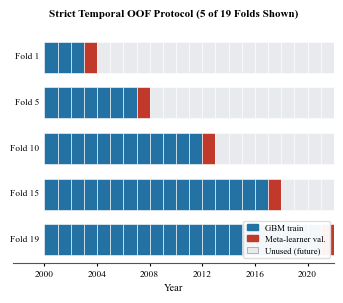

OOF protocol diagram saved (600 DPI PNG + vector PDF)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.close('all')
plt.style.use('default')

plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth':  0.8,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

# IEEE single-column width = 3.45 in
fig, ax = plt.subplots(figsize=(3.45, 3.0), facecolor='white')

years = list(range(2000, 2022))
folds_to_show = [0, 4, 9, 14, 18]
colors = {'train': '#2471A3', 'val': '#C0392B', 'unused': '#E8EAED'}

for i, f in enumerate(folds_to_show):
    train_end = 2002 + f
    val_year  = 2003 + f
    y_pos = len(folds_to_show) - 1 - i
    for yr in years:
        if yr <= train_end:
            color = colors['train']
        elif yr == val_year:
            color = colors['val']
        else:
            color = colors['unused']
        ax.barh(y_pos, 1, left=yr - 2000,
                color=color, edgecolor='white',
                linewidth=0.4, height=0.68, zorder=3)
    ax.text(-0.4, y_pos, f'Fold {f+1}',
            va='center', ha='right', fontsize=6.8)

ax.set_xlim(-2.4, 22)
ax.set_ylim(-0.5, len(folds_to_show) - 0.3)
ax.set_xticks(range(0, 22, 4))
ax.set_xticklabels(range(2000, 2022, 4), fontsize=6.8)
ax.set_yticks([])
ax.set_xlabel('Year', fontsize=7.5, labelpad=3)
ax.set_title('Strict Temporal OOF Protocol (5 of 19 Folds Shown)',
             fontsize=8, fontweight='bold', pad=6)

train_p  = mpatches.Patch(color=colors['train'], label='GBM train')
val_p    = mpatches.Patch(color=colors['val'], label='Meta-learner val.')
future_p = mpatches.Patch(facecolor=colors['unused'],
                           edgecolor='#999999', linewidth=0.5,
                           label='Unused (future)')

ax.legend(handles=[train_p, val_p, future_p],
          fontsize=6.3, loc='lower right',
          frameon=True, edgecolor='#dddddd', framealpha=0.95,
          handlelength=1.3, borderpad=0.4, labelspacing=0.35)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#555555')
ax.tick_params(axis='x', length=2.5)

plt.tight_layout(pad=0.6)
plt.savefig("figures/oof_protocol.png",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig("figures/oof_protocol.pdf",
            bbox_inches='tight', facecolor='white')
plt.show()
print("OOF protocol diagram saved (600 DPI PNG + vector PDF)")

# METHOD 2:  FL + Stacking Only (strict OOF meta-learner)

# FOR IID

In [25]:
# ═══════════════════════════════════════════════════════════════
# METHOD 2: FedStack (Proposed) — Strict OOF
# FIXED: client_data -> client_data_iid (matches Cell 14-A naming)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("METHOD 2: FedStack (PROPOSED)")
print("=" * 70)

meta_pop_st, meta_life_st, oof_mask_st = train_strict_oof_meta_learners(
    client_data_iid, oof_folds, Config.N_CLIENTS, Config.N_ROUNDS,
    use_kd=False
)

# Full-train refit with N_ROUNDS loop (no KD)
clients_st = []
for cid in range(Config.N_CLIENTS):
    c = FederatedClient(client_id=cid,
                        X=client_data_iid[cid]['X'],
                        y=client_data_iid[cid]['y'],
                        config=Config)
    clients_st.append(c)

server_st = FederatedServer(Config)

# Pre-concatenate full training data (once, outside the loop)
X_full_train = pd.concat([client_data_iid[cid]['X'] for cid in range(Config.N_CLIENTS)]).reset_index(drop=True)
y_full_train = pd.concat([client_data_iid[cid]['y'] for cid in range(Config.N_CLIENTS)]).reset_index(drop=True)

for round_num in range(1, Config.N_ROUNDS + 1):
    print(f"  Full‑train round {round_num}/{Config.N_ROUNDS} ...", end=" ")
    t_start = time.time()
    for client in clients_st:
        client.train(round_num=round_num,
                     global_pred_pop=None, global_pred_life=None,
                     alpha_pop=0.0, alpha_life=0.0)
    # aggregate using pre-concatenated data
    server_st.aggregate(clients_st,
                        X_full_train,
                        y_full_train[TARGET_POP].values,
                        y_full_train[TARGET_LIFE].values)
    print(f"done ({time.time()-t_start:.1f}s)")

# Final server with OOF meta-learners (override with OOF meta)
server_st.metapop = meta_pop_st
server_st.metalife = meta_life_st

# Predictions
preds_test_st = server_st.predict(clients_st, X_test_global)
preds_train_st = server_st.predict(clients_st, X_train_global)

stacking_metrics = {
    'pop_train': compute_metrics(df_train[TARGET_POP].values, preds_train_st["pop"], use_wmape=True),
    'pop_test':  compute_metrics(df_test[TARGET_POP].values,  preds_test_st["pop"],  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, preds_train_st["life"], use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  preds_test_st["life"],  use_wmape=False),
}

print(f"FedStack Pop  Test R² = {stacking_metrics['pop_test']['R2']:.4f}, "
      f"WMAPE = {stacking_metrics['pop_test']['PCT']:.4f}")
print(f"FedStack Life Test R² = {stacking_metrics['life_test']['R2']:.4f}, "
      f"MAE = {stacking_metrics['life_test']['MAE']:.4f}")

joblib.dump(stacking_metrics, f"{Config.MODELS_DIR}stacking_metrics.pkl")
joblib.dump(server_st, f"{Config.MODELS_DIR}server_stacking_only.pkl")
joblib.dump(clients_st, f"{Config.MODELS_DIR}clients_stacking_only.pkl")


METHOD 2: FedStack (PROPOSED)
  OOF fold 1/19 (train up to 2002, val 2003) ... done (20.5s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (23.4s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (25.7s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (34.2s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (29.3s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (31.7s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (35.9s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (41.9s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (41.7s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (42.7s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (52.7s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (56.7s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (60.0s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (62.9s)
  OOF fold 15/19 (train up to 2016, val 2017) ... done (64.5s)
  OOF fold 16/19 (train up to 201

['models/clients_stacking_only.pkl']

# FOR NONIID 

In [26]:
# ═══════════════════════════════════════════════════════════════
# METHOD 2: FedStack (Proposed) — Strict OOF — NON-IID
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("METHOD 2: FedStack (PROPOSED) — NON-IID")
print("=" * 70)

meta_pop_st_noniid, meta_life_st_noniid, oof_mask_st_noniid = train_strict_oof_meta_learners(
    client_data_noniid, oof_folds, N_CLIENTS_NONIID, Config.N_ROUNDS,
    use_kd=False
)

# Full-train refit with N_ROUNDS loop (no KD)
clients_st_noniid = []
for cid in range(N_CLIENTS_NONIID):
    c = FederatedClient(client_id=cid,
                        X=client_data_noniid[cid]['X'],
                        y=client_data_noniid[cid]['y'],
                        config=Config)
    clients_st_noniid.append(c)

server_st_noniid = FederatedServer(Config)

# Pre-concatenate full training data (once, outside the loop)
X_full_train_noniid = pd.concat([client_data_noniid[cid]['X'] for cid in range(N_CLIENTS_NONIID)]).reset_index(drop=True)
y_full_train_noniid = pd.concat([client_data_noniid[cid]['y'] for cid in range(N_CLIENTS_NONIID)]).reset_index(drop=True)

for round_num in range(1, Config.N_ROUNDS + 1):
    print(f"  Full‑train round {round_num}/{Config.N_ROUNDS} ...", end=" ")
    t_start = time.time()
    for client in clients_st_noniid:
        client.train(round_num=round_num,
                     global_pred_pop=None, global_pred_life=None,
                     alpha_pop=0.0, alpha_life=0.0)
    # aggregate using pre-concatenated data
    server_st_noniid.aggregate(clients_st_noniid,
                        X_full_train_noniid,
                        y_full_train_noniid[TARGET_POP].values,
                        y_full_train_noniid[TARGET_LIFE].values)
    print(f"done ({time.time()-t_start:.1f}s)")

# Final server with OOF meta-learners (override with OOF meta)
server_st_noniid.metapop = meta_pop_st_noniid
server_st_noniid.metalife = meta_life_st_noniid

# Predictions
preds_test_st_noniid = server_st_noniid.predict(clients_st_noniid, X_test_global)
preds_train_st_noniid = server_st_noniid.predict(clients_st_noniid, X_train_global)

stacking_metrics_noniid = {
    'pop_train': compute_metrics(df_train[TARGET_POP].values, preds_train_st_noniid["pop"], use_wmape=True),
    'pop_test':  compute_metrics(df_test[TARGET_POP].values,  preds_test_st_noniid["pop"],  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, preds_train_st_noniid["life"], use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  preds_test_st_noniid["life"],  use_wmape=False),
}

print(f"FedStack Pop  Test R² = {stacking_metrics_noniid['pop_test']['R2']:.4f}, "
      f"WMAPE = {stacking_metrics_noniid['pop_test']['PCT']:.4f}")
print(f"FedStack Life Test R² = {stacking_metrics_noniid['life_test']['R2']:.4f}, "
      f"MAE = {stacking_metrics_noniid['life_test']['MAE']:.4f}")

joblib.dump(stacking_metrics_noniid, f"{Config.MODELS_DIR}stacking_metrics_noniid.pkl")
joblib.dump(server_st_noniid, f"{Config.MODELS_DIR}server_stacking_only_noniid.pkl")
joblib.dump(clients_st_noniid, f"{Config.MODELS_DIR}clients_stacking_only_noniid.pkl")
print("=" * 70)


METHOD 2: FedStack (PROPOSED) — NON-IID
  OOF fold 1/19 (train up to 2002, val 2003) ... done (19.4s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (22.5s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (29.5s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (16.8s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (19.1s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (45.1s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (41.2s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (42.3s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (44.2s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (46.6s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (46.2s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (53.4s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (54.1s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (55.8s)
  OOF fold 15/19 (train up to 2016, val 2017) ... done (60.2s)
  OOF fold 16/19 (train

# Communication Cost Table

FOR IID

In [27]:
# ================================================================
# Communication Cost Estimation (per round) for IID
# ================================================================
print("=" * 70)
print("COMMUNICATION COST ESTIMATION : IID")
print("=" * 70)

# Use the clients from Method 2 (clients_st) – they are already trained
total_params_pop = sum(
    client.model_pop.n_estimators * client.model_pop.max_depth
    for client in clients_st
)
total_params_life = sum(
    client.model_life.n_estimators * client.model_life.max_depth
    for client in clients_st
)

print(f"  Population model params shared per round : {total_params_pop:,}")
print(f"  Life Exp. model params shared per round  : {total_params_life:,}")
print(f"  Total params communicated over {Config.N_ROUNDS} rounds : "
      f"{(total_params_pop + total_params_life) * Config.N_ROUNDS:,}")
print()
print("  Note: Only model parameters are shared; raw data remain local.")
print("=" * 70)

COMMUNICATION COST ESTIMATION : IID
  Population model params shared per round : 5,000
  Life Exp. model params shared per round  : 1,500
  Total params communicated over 5 rounds : 32,500

  Note: Only model parameters are shared; raw data remain local.


FOR NONIID

In [28]:
# ================================================================
# Communication Cost Estimation (per round) — NON-IID
# ================================================================
print("=" * 70)
print("COMMUNICATION COST ESTIMATION — NON-IID")
print("=" * 70)

# Use the clients from Method 2 Non-IID (clients_st_noniid) – already trained
total_params_pop_noniid = sum(
    client.model_pop.n_estimators * client.model_pop.max_depth
    for client in clients_st_noniid
)
total_params_life_noniid = sum(
    client.model_life.n_estimators * client.model_life.max_depth
    for client in clients_st_noniid
)

print(f"  Population model params shared per round : {total_params_pop_noniid:,}")
print(f"  Life Exp. model params shared per round  : {total_params_life_noniid:,}")
print(f"  Total params communicated over {Config.N_ROUNDS} rounds : "
      f"{(total_params_pop_noniid + total_params_life_noniid) * Config.N_ROUNDS:,}")
print()
print(f"  Number of clients (Non-IID) : {len(clients_st_noniid)}")
print("  Note: Only model parameters are shared; raw data remain local.")
print("  Note: Cost is structurally identical to IID setting since it depends")
print("        only on (n_clients x n_estimators x max_depth), not on how")
print("        samples/countries are distributed across clients.")
print("=" * 70)

COMMUNICATION COST ESTIMATION — NON-IID
  Population model params shared per round : 5,000
  Life Exp. model params shared per round  : 1,500
  Total params communicated over 5 rounds : 32,500

  Number of clients (Non-IID) : 5
  Note: Only model parameters are shared; raw data remain local.
  Note: Cost is structurally identical to IID setting since it depends
        only on (n_clients x n_estimators x max_depth), not on how
        samples/countries are distributed across clients.


# Round Sensitivity: FedStack (No KD) — IID

In [29]:
# ================================================================
# Round Sensitivity Analysis — FedStack (Proposed, NO KD) — IID
# Determines optimal N_ROUNDS for the proposed method only.
# KD is intentionally excluded (alpha=0) since KD sensitivity is
# handled separately via alpha-search in the Ablation section.
# ================================================================
print("=" * 70)
print("ROUND SENSITIVITY ANALYSIS — FedStack (Proposed, No KD) — IID")
print("=" * 70)

from sklearn.metrics import r2_score, mean_absolute_error
import time

round_options = [5, 10, 15]
results_sensitivity_fedstack_iid = []

for nr in round_options:
    print(f"\n--- Testing N_ROUNDS = {nr} (FedStack, no KD, IID) ---")
    t_start_nr = time.time()

    # OOF meta-learner training (use_kd=False — plain FedStack)
    meta_pop_nr, meta_life_nr, _ = train_strict_oof_meta_learners(
        client_data_iid, oof_folds, Config.N_CLIENTS, nr,
        use_kd=False   #  KD off — this is the core fix
    )

    # Fresh clients for full-train refit
    temp_clients = []
    for cid in range(Config.N_CLIENTS):
        c = FederatedClient(cid, client_data_iid[cid]['X'], client_data_iid[cid]['y'], Config)
        temp_clients.append(c)
    temp_server = FederatedServer(Config)
    temp_server.metapop  = meta_pop_nr
    temp_server.metalife = meta_life_nr

    # Full-train refit — nr rounds, alpha always 0.0 (no KD)
    for round_num in range(1, nr + 1):
        for client in temp_clients:
            client.train(round_num, None, None, alpha_pop=0.0, alpha_life=0.0)  #  pure FedStack

    # Evaluate on test set
    preds = temp_server.predict(temp_clients, X_test_global)
    pop_r2   = r2_score(df_test[TARGET_POP].values, preds['pop'])
    life_mae = mean_absolute_error(df_test[TARGET_LIFE].values, preds['life'])
    results_sensitivity_fedstack_iid.append((nr, pop_r2, life_mae))

    print(f"  Rounds={nr:2d}  →  Pop R²={pop_r2:.4f}, Life MAE={life_mae:.4f} yr "
          f"(took {time.time()-t_start_nr:.1f}s)")

print("\n  Round Sensitivity (FedStack, IID) complete.")
print("=" * 70)
for nr, r2, mae in results_sensitivity_fedstack_iid:
    print(f"  T={nr:2d} → Pop R²={r2:.4f}, Life MAE={mae:.4f}")
print("=" * 70)

ROUND SENSITIVITY ANALYSIS — FedStack (Proposed, No KD) — IID

--- Testing N_ROUNDS = 5 (FedStack, no KD, IID) ---
  OOF fold 1/19 (train up to 2002, val 2003) ... done (17.6s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (20.1s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (25.3s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (28.2s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (30.1s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (34.5s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (35.5s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (38.1s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (39.7s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (44.1s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (46.0s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (48.3s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (51.2s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (53.6s)
  OOF fold 1

# Round Sensitivity: FedStack (No KD) — Non-IID

In [30]:
# ================================================================
# Round Sensitivity Analysis — FedStack (Proposed, NO KD) — NON-IID
# Same protocol as IID version, using continent-based partition.
# ================================================================
print("=" * 70)
print("ROUND SENSITIVITY ANALYSIS — FedStack (Proposed, No KD) — NON-IID")
print("=" * 70)

from sklearn.metrics import r2_score, mean_absolute_error
import time

round_options = [5, 10, 15]
results_sensitivity_fedstack_noniid = []

for nr in round_options:
    print(f"\n--- Testing N_ROUNDS = {nr} (FedStack, no KD, Non-IID) ---")
    t_start_nr = time.time()

    meta_pop_nr, meta_life_nr, _ = train_strict_oof_meta_learners(
        client_data_noniid, oof_folds, N_CLIENTS_NONIID, nr,
        use_kd=False   #  KD off
    )

    temp_clients = []
    for cid in range(N_CLIENTS_NONIID):
        c = FederatedClient(cid, client_data_noniid[cid]['X'], client_data_noniid[cid]['y'], Config)
        temp_clients.append(c)
    temp_server = FederatedServer(Config)
    temp_server.metapop  = meta_pop_nr
    temp_server.metalife = meta_life_nr

    for round_num in range(1, nr + 1):
        for client in temp_clients:
            client.train(round_num, None, None, alpha_pop=0.0, alpha_life=0.0)  #  pure FedStack

    preds = temp_server.predict(temp_clients, X_test_global)
    pop_r2   = r2_score(df_test[TARGET_POP].values, preds['pop'])
    life_mae = mean_absolute_error(df_test[TARGET_LIFE].values, preds['life'])
    results_sensitivity_fedstack_noniid.append((nr, pop_r2, life_mae))

    print(f"  Rounds={nr:2d}  →  Pop R²={pop_r2:.4f}, Life MAE={life_mae:.4f} yr "
          f"(took {time.time()-t_start_nr:.1f}s)")

print("\n  Round Sensitivity (FedStack, Non-IID) complete.")
print("=" * 70)
for nr, r2, mae in results_sensitivity_fedstack_noniid:
    print(f"  T={nr:2d} → Pop R²={r2:.4f}, Life MAE={mae:.4f}")
print("=" * 70)

ROUND SENSITIVITY ANALYSIS — FedStack (Proposed, No KD) — NON-IID

--- Testing N_ROUNDS = 5 (FedStack, no KD, Non-IID) ---
  OOF fold 1/19 (train up to 2002, val 2003) ... done (22.9s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (22.5s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (22.9s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (25.0s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (28.1s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (31.0s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (34.1s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (36.9s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (39.7s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (42.6s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (46.2s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (48.5s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (50.8s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (53.5s)
  OO

# Strict Temporal Cross‑Validation for Target‑Adaptive KD: minimizing Population RMSE & Life Expectancy MAE

IID KD alpha search

In [31]:
# ================================================================
# OOF search for BOTH α_pop & α_life (No Hardcoded Values)
# FIXED: client_data -> client_data_iid (matches Cell 14-A naming)
# With progress prints
# ================================================================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# ----- α_life: MAE (pop α fixed at 0.0) -----
def oof_mae_life(alpha_life):
    n_train = len(X_train_global)
    oof_preds = np.full(n_train, np.nan)
    n_folds = len(oof_folds)
    for fold_idx, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        print(f"    [α_life={alpha_life:.1f}] Fold {fold_idx}/{n_folds} ...", end=" ")
        t_start = time.time()
        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx = np.where(val_mask)[0]
        fold_cdata = get_client_subset_by_years(client_data_iid, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_cdata)
        fs = FederatedServer(Config)
        for c in fold_clients: c.train(1, None, None, 0.0, 0.0)
        X_tr = pd.concat([fold_cdata[cid]["X"] for cid in active_ids]).reset_index(drop=True)
        y_tr = pd.concat([fold_cdata[cid]["y"] for cid in active_ids]).reset_index(drop=True)
        fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        for r in range(2, Config.N_ROUNDS+1):
            gpop, glife = fs.get_global_predictions(fold_clients, X_tr)
            start = 0
            for c in fold_clients:
                cid = c.client_id; ns = fold_cdata[cid]["n_samples"]
                c.train(r, gpop[start:start+ns], glife[start:start+ns], 0.0, alpha_life)
                start += ns
            fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        X_val = X_train_global.iloc[val_idx]
        preds = fs.predict(fold_clients, X_val)['life']
        oof_preds[val_idx] = preds
        print(f"done ({time.time()-t_start:.1f}s)")
    valid = ~np.isnan(oof_preds)
    return mean_absolute_error(df_train.loc[valid, TARGET_LIFE].values, oof_preds[valid])

# ----- α_pop: RMSE (life α = best_life, found above) -----
def oof_rmse_pop(alpha_pop, alpha_life_fixed):
    n_train = len(X_train_global)
    oof_preds = np.full(n_train, np.nan)
    n_folds = len(oof_folds)
    for fold_idx, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        print(f"    [α_pop={alpha_pop:.2f}] Fold {fold_idx}/{n_folds} ...", end=" ")
        t_start = time.time()
        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx = np.where(val_mask)[0]
        fold_cdata = get_client_subset_by_years(client_data_iid, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_cdata)
        fs = FederatedServer(Config)
        for c in fold_clients: c.train(1, None, None, 0.0, 0.0)
        X_tr = pd.concat([fold_cdata[cid]["X"] for cid in active_ids]).reset_index(drop=True)
        y_tr = pd.concat([fold_cdata[cid]["y"] for cid in active_ids]).reset_index(drop=True)
        fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        for r in range(2, Config.N_ROUNDS+1):
            gpop, glife = fs.get_global_predictions(fold_clients, X_tr)
            start = 0
            for c in fold_clients:
                cid = c.client_id; ns = fold_cdata[cid]["n_samples"]
                c.train(r, gpop[start:start+ns], glife[start:start+ns], alpha_pop, alpha_life_fixed)
                start += ns
            fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        X_val = X_train_global.iloc[val_idx]
        preds = fs.predict(fold_clients, X_val)['pop']
        oof_preds[val_idx] = preds
        print(f"done ({time.time()-t_start:.1f}s)")
    valid = ~np.isnan(oof_preds)
    return np.sqrt(mean_squared_error(df_train.loc[valid, TARGET_POP].values, oof_preds[valid]))


# 1. Search for best α_life (MAE)
print("Step 1: OOF Search for α_life (MAE, α_pop=0.0)")
life_alphas = [0.0, 0.2 , 0.3, 0.4, 0.5]  
life_results = {}
for al in life_alphas:
    print(f"  Testing α_life = {al:.1f} ...")
    life_results[al] = oof_mae_life(al)
    print(f"  → MAE = {life_results[al]:.4f} yr")
best_life = min(life_results, key=life_results.get)

# 2. Search for best α_pop (RMSE), using best_life found above
print(f"\nStep 2: OOF Search for α_pop (RMSE, α_life={best_life:.1f})")
pop_alphas = [0.0, 0.10 , 0.12,  0.14, 0.16] 
pop_results = {}
for ap in pop_alphas:
    print(f"  Testing α_pop = {ap:.2f} ...")
    pop_results[ap] = oof_rmse_pop(ap, best_life)
    print(f"  → RMSE = {pop_results[ap]/1e6:.4f}M")
best_pop = min(pop_results, key=pop_results.get)

print(f"\nBest α_life = {best_life:.1f} (MAE = {life_results[best_life]:.4f} yr)")
print(f"Best α_pop  = {best_pop:.2f} (RMSE = {pop_results[best_pop]/1e6:.4f}M)")
print("→ These values are used in Method 3 (FedStack+KD — Ablation).")

Step 1: OOF Search for α_life (MAE, α_pop=0.0)
  Testing α_life = 0.0 ...
    [α_life=0.0] Fold 1/19 ... done (20.1s)
    [α_life=0.0] Fold 2/19 ... done (23.0s)
    [α_life=0.0] Fold 3/19 ... done (26.7s)
    [α_life=0.0] Fold 4/19 ... done (30.0s)
    [α_life=0.0] Fold 5/19 ... done (33.6s)
    [α_life=0.0] Fold 6/19 ... done (36.9s)
    [α_life=0.0] Fold 7/19 ... done (40.3s)
    [α_life=0.0] Fold 8/19 ... done (43.4s)
    [α_life=0.0] Fold 9/19 ... done (46.7s)
    [α_life=0.0] Fold 10/19 ... done (50.1s)
    [α_life=0.0] Fold 11/19 ... done (53.6s)
    [α_life=0.0] Fold 12/19 ... done (57.0s)
    [α_life=0.0] Fold 13/19 ... done (52.9s)
    [α_life=0.0] Fold 14/19 ... done (52.1s)
    [α_life=0.0] Fold 15/19 ... done (55.5s)
    [α_life=0.0] Fold 16/19 ... done (58.2s)
    [α_life=0.0] Fold 17/19 ... done (60.6s)
    [α_life=0.0] Fold 18/19 ... done (63.3s)
    [α_life=0.0] Fold 19/19 ... done (66.2s)
  → MAE = 0.8725 yr
  Testing α_life = 0.2 ...
    [α_life=0.2] Fold 1/19 ... do

Non-IID KD alpha search

In [32]:
# ================================================================
# OOF search for BOTH α_pop & α_life (No Hardcoded Values) — NON-IID
# With progress prints
# ================================================================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# ----- α_life: MAE — NON-IID -----
def oof_mae_life_noniid(alpha_life):
    n_train = len(X_train_global)
    oof_preds = np.full(n_train, np.nan)
    n_folds = len(oof_folds)
    for fold_idx, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        print(f"    [α_life={alpha_life:.1f}] Fold {fold_idx}/{n_folds} ...", end=" ")
        t_start = time.time()
        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx = np.where(val_mask)[0]
        fold_cdata = get_client_subset_by_years(client_data_noniid, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_cdata)
        fs = FederatedServer(Config)
        for c in fold_clients: c.train(1, None, None, 0.0, 0.0)
        X_tr = pd.concat([fold_cdata[cid]["X"] for cid in active_ids]).reset_index(drop=True)
        y_tr = pd.concat([fold_cdata[cid]["y"] for cid in active_ids]).reset_index(drop=True)
        fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        for r in range(2, Config.N_ROUNDS+1):
            gpop, glife = fs.get_global_predictions(fold_clients, X_tr)
            start = 0
            for c in fold_clients:
                cid = c.client_id; ns = fold_cdata[cid]["n_samples"]
                c.train(r, gpop[start:start+ns], glife[start:start+ns], 0.0, alpha_life)
                start += ns
            fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        X_val = X_train_global.iloc[val_idx]
        preds = fs.predict(fold_clients, X_val)['life']
        oof_preds[val_idx] = preds
        print(f"done ({time.time()-t_start:.1f}s)")
    valid = ~np.isnan(oof_preds)
    return mean_absolute_error(df_train.loc[valid, TARGET_LIFE].values, oof_preds[valid])

# ----- α_pop: RMSE (life α = best_life, found above) — NON-IID -----
def oof_rmse_pop_noniid(alpha_pop, alpha_life_fixed):
    n_train = len(X_train_global)
    oof_preds = np.full(n_train, np.nan)
    n_folds = len(oof_folds)
    for fold_idx, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        print(f"    [α_pop={alpha_pop:.2f}] Fold {fold_idx}/{n_folds} ...", end=" ")
        t_start = time.time()
        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx = np.where(val_mask)[0]
        fold_cdata = get_client_subset_by_years(client_data_noniid, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_cdata)
        fs = FederatedServer(Config)
        for c in fold_clients: c.train(1, None, None, 0.0, 0.0)
        X_tr = pd.concat([fold_cdata[cid]["X"] for cid in active_ids]).reset_index(drop=True)
        y_tr = pd.concat([fold_cdata[cid]["y"] for cid in active_ids]).reset_index(drop=True)
        fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        for r in range(2, Config.N_ROUNDS+1):
            gpop, glife = fs.get_global_predictions(fold_clients, X_tr)
            start = 0
            for c in fold_clients:
                cid = c.client_id; ns = fold_cdata[cid]["n_samples"]
                c.train(r, gpop[start:start+ns], glife[start:start+ns], alpha_pop, alpha_life_fixed)
                start += ns
            fs.aggregate(fold_clients, X_tr, y_tr[TARGET_POP].values, y_tr[TARGET_LIFE].values)
        X_val = X_train_global.iloc[val_idx]
        preds = fs.predict(fold_clients, X_val)['pop']
        oof_preds[val_idx] = preds
        print(f"done ({time.time()-t_start:.1f}s)")
    valid = ~np.isnan(oof_preds)
    return np.sqrt(mean_squared_error(df_train.loc[valid, TARGET_POP].values, oof_preds[valid]))


# 1. Search for best α_life (MAE) — Non-IID
print("Step 1: OOF Search for α_life (MAE, α_pop=0.0) — NON-IID")
life_alphas_noniid = [0.0, 0.2 , 0.3, 0.4, 0.5] 
life_results_noniid = {}
for al in life_alphas_noniid:
    print(f"  Testing α_life = {al:.1f} ...")
    life_results_noniid[al] = oof_mae_life_noniid(al)
    print(f"  → MAE = {life_results_noniid[al]:.4f} yr")
best_life_noniid = min(life_results_noniid, key=life_results_noniid.get)

# 2. Search for best α_pop (RMSE), using best_life found above — Non-IID
print(f"\nStep 2: OOF Search for α_pop (RMSE, α_life={best_life_noniid:.1f}) — NON-IID")
pop_alphas_noniid = [ 0.0, 0.10 ,0.12,0.14, 0.16 ]
pop_results_noniid = {}
for ap in pop_alphas_noniid:
    print(f"  Testing α_pop = {ap:.2f} ...")
    pop_results_noniid[ap] = oof_rmse_pop_noniid(ap, best_life_noniid)
    print(f"  → RMSE = {pop_results_noniid[ap]/1e6:.4f}M")
best_pop_noniid = min(pop_results_noniid, key=pop_results_noniid.get)

print(f"\nBest α_life (Non-IID) = {best_life_noniid:.1f} (MAE = {life_results_noniid[best_life_noniid]:.4f} yr)")
print(f"Best α_pop  (Non-IID) = {best_pop_noniid:.2f} (RMSE = {pop_results_noniid[best_pop_noniid]/1e6:.4f}M)")
print("→ These values are used in Method 3 (FedStack+KD — Ablation) — NON-IID.")

Step 1: OOF Search for α_life (MAE, α_pop=0.0) — NON-IID
  Testing α_life = 0.0 ...
    [α_life=0.0] Fold 1/19 ... done (16.5s)
    [α_life=0.0] Fold 2/19 ... done (19.3s)
    [α_life=0.0] Fold 3/19 ... done (22.2s)
    [α_life=0.0] Fold 4/19 ... done (25.0s)
    [α_life=0.0] Fold 5/19 ... done (27.8s)
    [α_life=0.0] Fold 6/19 ... done (30.6s)
    [α_life=0.0] Fold 7/19 ... done (33.2s)
    [α_life=0.0] Fold 8/19 ... done (36.3s)
    [α_life=0.0] Fold 9/19 ... done (39.1s)
    [α_life=0.0] Fold 10/19 ... done (41.7s)
    [α_life=0.0] Fold 11/19 ... done (45.2s)
    [α_life=0.0] Fold 12/19 ... done (48.4s)
    [α_life=0.0] Fold 13/19 ... done (50.2s)
    [α_life=0.0] Fold 14/19 ... done (53.0s)
    [α_life=0.0] Fold 15/19 ... done (55.5s)
    [α_life=0.0] Fold 16/19 ... done (58.6s)
    [α_life=0.0] Fold 17/19 ... done (61.4s)
    [α_life=0.0] Fold 18/19 ... done (64.0s)
    [α_life=0.0] Fold 19/19 ... done (66.6s)
  → MAE = 1.1400 yr
  Testing α_life = 0.2 ...
    [α_life=0.2] Fold 1

# METHOD 3: FL + Stacking + Target‑Adaptive KD (OOF meta)

In [33]:
# ═══════════════════════════════════════════════════════════════
# METHOD 3: FedStack + KD (Ablation Study — Target‑Adaptive KD)
# FIXED: client_data -> client_data_iid (matches Cell 14-A naming)
# (with round progress)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("METHOD 3: FedStack + KD (ABLATION)")
print("=" * 70)

ALPHA_POP  = best_pop
ALPHA_LIFE = best_life

meta_pop_kd, meta_life_kd, oof_mask_kd = train_strict_oof_meta_learners(
    client_data_iid, oof_folds, Config.N_CLIENTS, Config.N_ROUNDS,
    use_kd=True, alpha_pop=ALPHA_POP, alpha_life=ALPHA_LIFE
)

# Full-train refit with KD rounds (with progress)
clients_kd = []
for cid in range(Config.N_CLIENTS):
    c = FederatedClient(client_id=cid,
                        X=client_data_iid[cid]['X'],
                        y=client_data_iid[cid]['y'],
                        config=Config)
    clients_kd.append(c)

server_kd = FederatedServer(Config)
server_kd.metapop = meta_pop_kd
server_kd.metalife = meta_life_kd

for round_num in range(1, Config.N_ROUNDS + 1):
    print(f"  Full‑train KD round {round_num}/{Config.N_ROUNDS} ...", end=" ")
    t_start = time.time()
    if round_num == 1:
        gpop, glife = None, None
    else:
        gpop, glife = server_kd.get_global_predictions(clients_kd, X_train_global)
    for client in clients_kd:
        cid = client.client_id
        client_idx = client_data_iid[cid]["indices"]
        client.train(
            round_num=round_num,
            global_pred_pop=gpop[client_idx] if gpop is not None else None,
            global_pred_life=glife[client_idx] if glife is not None else None,
            alpha_pop=ALPHA_POP if round_num > 1 else 0.0,
            alpha_life=ALPHA_LIFE if round_num > 1 else 0.0
        )
    print(f"done ({time.time()-t_start:.1f}s)")

# Final predictions with OOF meta-learners
preds_test_kd = server_kd.predict(clients_kd, X_test_global)
preds_train_kd = server_kd.predict(clients_kd, X_train_global)

kd_metrics = {
    'pop_train': compute_metrics(df_train[TARGET_POP].values, preds_train_kd["pop"], use_wmape=True),
    'pop_test':  compute_metrics(df_test[TARGET_POP].values,  preds_test_kd["pop"],  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, preds_train_kd["life"], use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  preds_test_kd["life"],  use_wmape=False),
}

print(f"FedStack+KD Pop  Test R² = {kd_metrics['pop_test']['R2']:.4f}, "
      f"WMAPE = {kd_metrics['pop_test']['PCT']:.4f}")
print(f"FedStack+KD Life Test R² = {kd_metrics['life_test']['R2']:.4f}, "
      f"MAE = {kd_metrics['life_test']['MAE']:.4f}")

joblib.dump(kd_metrics, f"{Config.MODELS_DIR}flkdmetrics.pkl")
joblib.dump(server_kd, f"{Config.MODELS_DIR}server.pkl")
joblib.dump(clients_kd, f"{Config.MODELS_DIR}clients.pkl")


METHOD 3: FedStack + KD (ABLATION)
  OOF fold 1/19 (train up to 2002, val 2003) ... done (17.8s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (23.8s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (29.3s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (31.2s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (34.4s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (35.8s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (39.3s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (41.6s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (45.0s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (47.6s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (53.8s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (56.1s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (56.9s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (55.6s)
  OOF fold 15/19 (train up to 2016, val 2017) ... done (59.5s)
  OOF fold 16/19 (train up t

['models/clients.pkl']

 NON-IID

In [34]:
# ═══════════════════════════════════════════════════════════════
# METHOD 3: FedStack + KD (Ablation Study — Target‑Adaptive KD) — NON-IID
# (with round progress)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("METHOD 3: FedStack + KD (ABLATION) — NON-IID")
print("=" * 70)

ALPHA_POP_NONIID  = best_pop_noniid
ALPHA_LIFE_NONIID = best_life_noniid

meta_pop_kd_noniid, meta_life_kd_noniid, oof_mask_kd_noniid = train_strict_oof_meta_learners(
    client_data_noniid, oof_folds, N_CLIENTS_NONIID, Config.N_ROUNDS,
    use_kd=True, alpha_pop=ALPHA_POP_NONIID, alpha_life=ALPHA_LIFE_NONIID
)

# Full-train refit with KD rounds (with progress)
clients_kd_noniid = []
for cid in range(N_CLIENTS_NONIID):
    c = FederatedClient(client_id=cid,
                        X=client_data_noniid[cid]['X'],
                        y=client_data_noniid[cid]['y'],
                        config=Config)
    clients_kd_noniid.append(c)

server_kd_noniid = FederatedServer(Config)
server_kd_noniid.metapop = meta_pop_kd_noniid
server_kd_noniid.metalife = meta_life_kd_noniid

for round_num in range(1, Config.N_ROUNDS + 1):
    print(f"  Full‑train KD round {round_num}/{Config.N_ROUNDS} ...", end=" ")
    t_start = time.time()
    if round_num == 1:
        gpop, glife = None, None
    else:
        gpop, glife = server_kd_noniid.get_global_predictions(clients_kd_noniid, X_train_global)
    for client in clients_kd_noniid:
        cid = client.client_id
        client_idx = client_data_noniid[cid]["indices"]
        client.train(
            round_num=round_num,
            global_pred_pop=gpop[client_idx] if gpop is not None else None,
            global_pred_life=glife[client_idx] if glife is not None else None,
            alpha_pop=ALPHA_POP_NONIID if round_num > 1 else 0.0,
            alpha_life=ALPHA_LIFE_NONIID if round_num > 1 else 0.0
        )
    print(f"done ({time.time()-t_start:.1f}s)")

# Final predictions with OOF meta-learners
preds_test_kd_noniid = server_kd_noniid.predict(clients_kd_noniid, X_test_global)
preds_train_kd_noniid = server_kd_noniid.predict(clients_kd_noniid, X_train_global)

kd_metrics_noniid = {
    'pop_train': compute_metrics(df_train[TARGET_POP].values, preds_train_kd_noniid["pop"], use_wmape=True),
    'pop_test':  compute_metrics(df_test[TARGET_POP].values,  preds_test_kd_noniid["pop"],  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, preds_train_kd_noniid["life"], use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  preds_test_kd_noniid["life"],  use_wmape=False),
}

print(f"FedStack+KD Pop  Test R² = {kd_metrics_noniid['pop_test']['R2']:.4f}, "
      f"WMAPE = {kd_metrics_noniid['pop_test']['PCT']:.4f}")
print(f"FedStack+KD Life Test R² = {kd_metrics_noniid['life_test']['R2']:.4f}, "
      f"MAE = {kd_metrics_noniid['life_test']['MAE']:.4f}")

joblib.dump(kd_metrics_noniid, f"{Config.MODELS_DIR}flkdmetrics_noniid.pkl")
joblib.dump(server_kd_noniid, f"{Config.MODELS_DIR}server_noniid.pkl")
joblib.dump(clients_kd_noniid, f"{Config.MODELS_DIR}clients_noniid.pkl")
print("=" * 70)


METHOD 3: FedStack + KD (ABLATION) — NON-IID
  OOF fold 1/19 (train up to 2002, val 2003) ... done (21.8s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (24.5s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (22.5s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (25.2s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (28.4s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (31.5s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (34.0s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (37.3s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (40.7s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (43.0s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (45.5s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (48.7s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (51.5s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (53.8s)
  OOF fold 15/19 (train up to 2016, val 2017) ... done (56.9s)
  OOF fold 16/19 (

# Hyperparameter Sensitivity Analysis For FedStack (KD)

IID

In [35]:
# ================================================================
# Sensitivity Analysis: Effect of N_ROUNDS on FedStack+KD (Ablation)
# client_data -> client_data_iid (matches Cell 14-A naming)
# (with progress for each round option)
# ================================================================
print("=" * 70)
print("SENSITIVITY ANALYSIS — Different N_ROUNDS (FedStack+KD Ablation)")
print("=" * 70)
from sklearn.metrics import r2_score, mean_absolute_error
import time

round_options = [5, 10, 15]
results_sensitivity = []
alpha_pop, alpha_life = best_pop, best_life   # already computed

for nr in round_options:
    print(f"\n--- Testing N_ROUNDS = {nr} ---")
    t_start_nr = time.time()
    # OOF meta-learner training (progress of folds will be printed inside)
    meta_pop_nr, meta_life_nr, _ = train_strict_oof_meta_learners(
        client_data_iid, oof_folds, Config.N_CLIENTS, nr,
        use_kd=True, alpha_pop=alpha_pop, alpha_life=alpha_life
    )
    # Create fresh clients and train for nr rounds
    temp_clients = []
    for cid in range(Config.N_CLIENTS):
        c = FederatedClient(cid, client_data_iid[cid]['X'], client_data_iid[cid]['y'], Config)
        temp_clients.append(c)
    temp_server = FederatedServer(Config)
    temp_server.metapop = meta_pop_nr
    temp_server.metalife = meta_life_nr
    # Full-train refit with nr rounds
    for round_num in range(1, nr + 1):
        if round_num == 1:
            gpop, glife = None, None
        else:
            gpop, glife = temp_server.get_global_predictions(temp_clients, X_train_global)
        for client in temp_clients:
            cid = client.client_id
            idx = client_data_iid[cid]["indices"]
            client.train(round_num,
                         gpop[idx] if gpop is not None else None,
                         glife[idx] if glife is not None else None,
                         alpha_pop if round_num > 1 else 0.0,
                         alpha_life if round_num > 1 else 0.0)
    # Evaluate on test set
    preds = temp_server.predict(temp_clients, X_test_global)
    pop_r2 = r2_score(df_test[TARGET_POP].values, preds['pop'])
    life_mae = mean_absolute_error(df_test[TARGET_LIFE].values, preds['life'])
    results_sensitivity.append((nr, pop_r2, life_mae))
    print(f"  Rounds={nr:2d}  →  Pop R²={pop_r2:.4f}, Life MAE={life_mae:.4f} yr "
          f"(took {time.time()-t_start_nr:.1f}s)")

print("\n  N_ROUNDS sensitivity analysis (FedStack+KD) complete.")
print("=" * 70)

SENSITIVITY ANALYSIS — Different N_ROUNDS (FedStack+KD Ablation)

--- Testing N_ROUNDS = 5 ---
  OOF fold 1/19 (train up to 2002, val 2003) ... done (17.0s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (19.8s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (24.0s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (25.4s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (28.8s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (31.1s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (34.1s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (37.2s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (40.2s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (43.5s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (46.1s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (48.8s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (53.0s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (54.0s)
  OOF fold 15/19 (train up to 20

Non-IID

In [36]:
# ================================================================
# Sensitivity Analysis: Effect of N_ROUNDS on FedStack+KD (Ablation) — NON-IID
# (with progress for each round option)
# ================================================================
print("=" * 70)
print("SENSITIVITY ANALYSIS — Different N_ROUNDS (FedStack+KD Ablation) — NON-IID")
print("=" * 70)

from sklearn.metrics import r2_score, mean_absolute_error
import time

round_options_noniid = [5, 10, 15]
results_sensitivity_noniid = []
alpha_pop_noniid, alpha_life_noniid = best_pop_noniid, best_life_noniid   # already computed

for nr in round_options_noniid:
    print(f"\n--- Testing N_ROUNDS = {nr} (Non-IID) ---")
    t_start_nr = time.time()

    # OOF meta-learner training (progress of folds will be printed inside)
    meta_pop_nr_noniid, meta_life_nr_noniid, _ = train_strict_oof_meta_learners(
        client_data_noniid, oof_folds, N_CLIENTS_NONIID, nr,
        use_kd=True, alpha_pop=alpha_pop_noniid, alpha_life=alpha_life_noniid
    )

    # Create fresh clients and train for nr rounds
    temp_clients_noniid = []
    for cid in range(N_CLIENTS_NONIID):
        c = FederatedClient(cid, client_data_noniid[cid]['X'], client_data_noniid[cid]['y'], Config)
        temp_clients_noniid.append(c)

    temp_server_noniid = FederatedServer(Config)
    temp_server_noniid.metapop = meta_pop_nr_noniid
    temp_server_noniid.metalife = meta_life_nr_noniid

    # Full-train refit with nr rounds
    for round_num in range(1, nr + 1):
        if round_num == 1:
            gpop, glife = None, None
        else:
            gpop, glife = temp_server_noniid.get_global_predictions(temp_clients_noniid, X_train_global)
        for client in temp_clients_noniid:
            cid = client.client_id
            idx = client_data_noniid[cid]["indices"]
            client.train(round_num,
                         gpop[idx] if gpop is not None else None,
                         glife[idx] if glife is not None else None,
                         alpha_pop_noniid if round_num > 1 else 0.0,
                         alpha_life_noniid if round_num > 1 else 0.0)

    # Evaluate on test set
    preds = temp_server_noniid.predict(temp_clients_noniid, X_test_global)
    pop_r2_noniid = r2_score(df_test[TARGET_POP].values, preds['pop'])
    life_mae_noniid = mean_absolute_error(df_test[TARGET_LIFE].values, preds['life'])
    results_sensitivity_noniid.append((nr, pop_r2_noniid, life_mae_noniid))

    print(f"  Rounds={nr:2d}  →  Pop R²={pop_r2_noniid:.4f}, Life MAE={life_mae_noniid:.4f} yr "
          f"(took {time.time()-t_start_nr:.1f}s)")

print("\n  N_ROUNDS sensitivity analysis (FedStack+KD, Non-IID) complete.")
print("=" * 70)

SENSITIVITY ANALYSIS — Different N_ROUNDS (FedStack+KD Ablation) — NON-IID

--- Testing N_ROUNDS = 5 (Non-IID) ---
  OOF fold 1/19 (train up to 2002, val 2003) ... done (6.3s)
  OOF fold 2/19 (train up to 2003, val 2004) ... done (7.6s)
  OOF fold 3/19 (train up to 2004, val 2005) ... done (7.7s)
  OOF fold 4/19 (train up to 2005, val 2006) ... done (12.3s)
  OOF fold 5/19 (train up to 2006, val 2007) ... done (27.7s)
  OOF fold 6/19 (train up to 2007, val 2008) ... done (36.6s)
  OOF fold 7/19 (train up to 2008, val 2009) ... done (38.2s)
  OOF fold 8/19 (train up to 2009, val 2010) ... done (39.6s)
  OOF fold 9/19 (train up to 2010, val 2011) ... done (43.6s)
  OOF fold 10/19 (train up to 2011, val 2012) ... done (47.4s)
  OOF fold 11/19 (train up to 2012, val 2013) ... done (48.6s)
  OOF fold 12/19 (train up to 2013, val 2014) ... done (50.7s)
  OOF fold 13/19 (train up to 2014, val 2015) ... done (52.7s)
  OOF fold 14/19 (train up to 2015, val 2016) ... done (57.8s)
  OOF fold 15/1

# METHOD 4: Centralized Baseline

(stacked ensemble) 

In [37]:
# ═══════════════════════════════════════════════════════════════
# METHOD 4-B: Centralized Baseline — SINGLE MODEL
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("METHOD 4-B: CENTRALIZED BASELINE (Single Model, Traditional)")
print("=" * 70)

cent_pop_single  = GradientBoostingRegressor(**Config.GB_CONFIG)
cent_life_single = GradientBoostingRegressor(**Config.GB_CONFIG_LIFE)

y_pop_train_log = np.log1p(df_train[TARGET_POP].values)   # same log1p fix applies here too

cent_pop_single.fit(X_train_global, y_pop_train_log)
cent_life_single.fit(X_train_global, df_train[TARGET_LIFE].values)

cp_train_single = np.expm1(cent_pop_single.predict(X_train_global))
cl_train_single = cent_life_single.predict(X_train_global)
cp_test_single  = np.expm1(cent_pop_single.predict(X_test_global))
cl_test_single  = cent_life_single.predict(X_test_global)

cent_metrics_single = {
    'pop_train':  compute_metrics(df_train[TARGET_POP].values,  cp_train_single, use_wmape=True),
    'pop_test':   compute_metrics(df_test[TARGET_POP].values,   cp_test_single,  use_wmape=True),
    'life_train': compute_metrics(df_train[TARGET_LIFE].values, cl_train_single, use_wmape=False),
    'life_test':  compute_metrics(df_test[TARGET_LIFE].values,  cl_test_single,  use_wmape=False),
}

print(f"Centralized (Single) Pop  Test R² = {cent_metrics_single['pop_test']['R2']:.4f}, "
      f"WMAPE = {cent_metrics_single['pop_test']['PCT']:.4f}")
print(f"Centralized (Single) Life Test R² = {cent_metrics_single['life_test']['R2']:.4f}, "
      f"MAE = {cent_metrics_single['life_test']['MAE']:.4f}")

joblib.dump(cent_metrics_single, f"{Config.MODELS_DIR}centralized_metrics_single.pkl")
print("Centralized (single-model, traditional baseline) metrics saved")


METHOD 4-B: CENTRALIZED BASELINE (Single Model, Traditional)
Centralized (Single) Pop  Test R² = 0.9597, WMAPE = 8.1813
Centralized (Single) Life Test R² = 0.9603, MAE = 1.1479
Centralized (single-model, traditional baseline) metrics saved


In [38]:
# ================================================================
# Non-IID
# ================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

TARGET_POP = Config.TARGET_COLUMNS[0]

y_true = df_test[TARGET_POP].values

# FedStack Non-IID predictions (already computed in Method 2 Non-IID cell)
y_pred_fedstack = preds_test_st_noniid['pop']

# Centralized predictions
y_pred_cent = cent_pop.predict(X_test_global)

# ── 1) Per-row squared error contribution to R² (this is what R² "sees") ──
sq_err_fedstack = (y_true - y_pred_fedstack) ** 2
sq_err_cent     = (y_true - y_pred_cent) ** 2

diag = pd.DataFrame({
    'Country': df_test['Country Name'].values,
    'Year'   : df_test['Year'].values,
    'y_true' : y_true,
    'pred_fedstack': y_pred_fedstack,
    'pred_cent'    : y_pred_cent,
    'sqerr_fedstack': sq_err_fedstack,
    'sqerr_cent'    : sq_err_cent,
    'abs_pct_err_fedstack': np.abs(y_true - y_pred_fedstack) / (np.abs(y_true) + 1e-8) * 100,
    'abs_pct_err_cent'    : np.abs(y_true - y_pred_cent)     / (np.abs(y_true) + 1e-8) * 100,
})

# ── 2) How much of total SS_res each row contributes (R² driver) ──
diag['sqerr_share_fedstack_%'] = diag['sqerr_fedstack'] / diag['sqerr_fedstack'].sum() * 100
diag['sqerr_share_cent_%']     = diag['sqerr_cent']     / diag['sqerr_cent'].sum()     * 100

print("=" * 90)
print("TOP 10 ROWS BY POPULATION SIZE (test set) — do these dominate R²?")
print("=" * 90)
top_pop = diag.sort_values('y_true', ascending=False).head(10)
print(top_pop[['Country', 'Year', 'y_true', 'pred_fedstack', 'pred_cent',
               'sqerr_share_fedstack_%', 'sqerr_share_cent_%']].to_string(index=False))

print("\n" + "=" * 90)
print("TOP 10 ROWS BY ABSOLUTE %ERROR (FedStack Non-IID) — worst relative misses")
print("=" * 90)
worst_pct = diag.sort_values('abs_pct_err_fedstack', ascending=False).head(10)
print(worst_pct[['Country', 'Year', 'y_true', 'pred_fedstack',
                  'abs_pct_err_fedstack', 'abs_pct_err_cent']].to_string(index=False))

# ── 3) R² recomputed EXCLUDING the largest-population countries ──
for k in [3, 5, 10]:
    excl_idx = diag.sort_values('y_true', ascending=False).head(k).index
    mask = ~diag.index.isin(excl_idx)
    r2_fed_excl  = r2_score(y_true[mask], y_pred_fedstack[mask])
    r2_cent_excl = r2_score(y_true[mask], y_pred_cent[mask])
    print(f"\nExcluding top-{k} largest-population test rows:")
    print(f"  FedStack Non-IID R² = {r2_fed_excl:.4f}   |   Centralized R² = {r2_cent_excl:.4f}")

# ── 4) Log-scale R² — fairer for population data spanning orders of magnitude ──
y_true_log   = np.log1p(y_true)
y_pred_fed_log  = np.log1p(np.clip(y_pred_fedstack, 0, None))
y_pred_cent_log = np.log1p(np.clip(y_pred_cent, 0, None))

r2_fed_log  = r2_score(y_true_log, y_pred_fed_log)
r2_cent_log = r2_score(y_true_log, y_pred_cent_log)

print("\n" + "=" * 90)
print("LOG-SCALE R² (removes scale/outlier domination — recommended for Population)")
print("=" * 90)
print(f"  FedStack Non-IID log-R² = {r2_fed_log:.4f}")
print(f"  Centralized     log-R² = {r2_cent_log:.4f}")
print("\nIf log-R² now shows Centralized >= FedStack, this CONFIRMS the raw R²")
print("inflation was a scale/outlier artifact, not data leakage.")

TOP 10 ROWS BY POPULATION SIZE (test set) — do these dominate R²?
      Country  Year     y_true  pred_fedstack    pred_cent  sqerr_share_fedstack_%  sqerr_share_cent_%
        India  2024 1450935791   1.416236e+09 1.400856e+09                0.186975            0.391276
        India  2023 1438069596   1.436673e+09 1.432984e+09                0.000303            0.004035
        India  2022 1425423212   1.423894e+09 1.434201e+09                0.000363            0.012022
        China  2022 1412175000   1.134651e+09 1.011494e+09               11.959899           25.047018
        China  2023 1410710000   1.036738e+09 9.493397e+08               21.717307           33.209177
        China  2024 1408975000   7.889819e+08 8.993950e+08               59.689963           40.512002
United States  2024  340110988   2.870227e+08 3.173984e+08                0.437647            0.080481
United States  2023  336806231   2.944496e+08 3.283559e+08                0.278593            0.011141
United 

# SUMMARY TABLE 

In [39]:
# ================================================================
# TABLE III — IID vs NON-IID METHOD COMPARISON (Clean Console View)
# ================================================================
import pandas as pd

methods_iid = [
    ("Federated Ensemble", fedavg_metrics),
    ("FedStack (Proposed)", stacking_metrics),
    ("FedStack+KD", kd_metrics),
    #("Centralized (Ensemble)", cent_metrics),        # 🆕 নাম স্পষ্ট করা হলো
    ("Centralized (Single)", cent_metrics_single),   # 🆕 নতুন row
]
methods_noniid_pub = [
    ("Federated Ensemble", fedavg_metrics_noniid),
    ("FedStack (Proposed)", stacking_metrics_noniid),
    ("FedStack+KD", kd_metrics_noniid),
    #("Centralized (Ensemble)", cent_metrics),         # 🆕 same value, partition-independent
    ("Centralized (Single)", cent_metrics_single),    # 🆕 same value, partition-independent
]

rows = []
for (name_i, m_i), (name_n, m_n) in zip(methods_iid, methods_noniid_pub):
    rows.append({
        'Method'        : name_i,
        'Pop R2 (IID)'    : round(m_i['pop_test']['R2'], 4),
        'Pop R2 (NonIID)' : round(m_n['pop_test']['R2'], 4),
        'Pop WMAPE (IID)'    : round(m_i['pop_test']['PCT'], 2),
        'Pop WMAPE (NonIID)' : round(m_n['pop_test']['PCT'], 2),
        'Life R2 (IID)'    : round(m_i['life_test']['R2'], 4),
        'Life R2 (NonIID)' : round(m_n['life_test']['R2'], 4),
        'Life MAE (IID)'    : round(m_i['life_test']['MAE'], 4),
        'Life MAE (NonIID)' : round(m_n['life_test']['MAE'], 4),
    })

df_table3 = pd.DataFrame(rows)

# ── Save CSV (for records / supplementary material) ────────────────
df_table3.to_csv('table3_iid_vs_noniid_comparison.csv', index=False)

# ── Clean console view: split into Population and Life Expectancy blocks ──
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)

print("\n" + "=" * 78)
print("TABLE III-A — POPULATION PREDICTION  (IID vs Non-IID)")
print("=" * 78)
df_pop = df_table3[['Method', 'Pop R2 (IID)', 'Pop R2 (NonIID)',
                     'Pop WMAPE (IID)', 'Pop WMAPE (NonIID)']]
print(df_pop.to_string(index=False))

print("\n" + "=" * 78)
print("TABLE III-B — LIFE EXPECTANCY PREDICTION  (IID vs Non-IID)")
print("=" * 78)
df_life = df_table3[['Method', 'Life R2 (IID)', 'Life R2 (NonIID)',
                      'Life MAE (IID)', 'Life MAE (NonIID)']]
print(df_life.to_string(index=False))
print("=" * 78)

print("\nSaved: table3_iid_vs_noniid_comparison.csv")


TABLE III-A — POPULATION PREDICTION  (IID vs Non-IID)
              Method  Pop R2 (IID)  Pop R2 (NonIID)  Pop WMAPE (IID)  Pop WMAPE (NonIID)
  Federated Ensemble        0.5243           0.4258            38.14               47.75
 FedStack (Proposed)        0.9583           0.9504            25.40               13.89
         FedStack+KD        0.9514           0.9462            32.79               15.15
Centralized (Single)        0.9597           0.9597             8.18                8.18

TABLE III-B — LIFE EXPECTANCY PREDICTION  (IID vs Non-IID)
              Method  Life R2 (IID)  Life R2 (NonIID)  Life MAE (IID)  Life MAE (NonIID)
  Federated Ensemble         0.9360            0.8394          1.3206             2.2123
 FedStack (Proposed)         0.9489            0.9414          1.1031             1.2418
         FedStack+KD         0.9489            0.9414          1.1031             1.2418
Centralized (Single)         0.9603            0.9603          1.1479             1.

# Overfitting Analysis

In [40]:
# ================================================================
# Cell 17.7 — Train‑Test Gap Analysis (IID + NON‑IID) — 4 METHODS
# (Centralized Ensemble removed; only Single retained for paper consistency)
# ================================================================
import pandas as pd
import joblib

print("=" * 80)
print("TRAIN‑TEST GAP ANALYSIS (4 Methods)")
print("=" * 80)

def build_gap_table_4(fedavg_m, stacking_m, kd_m, cent_single_m, label, save_suffix):
    """Builds the gap comparison table for 4 methods (IID or Non-IID)."""
    
    rows = {
        'Method': [
            'Federated Ensemble (Baseline)',
            'FedStack (Proposed)',
            'FedStack+KD (Ablation)',
            'Centralized (Single)',          # only single, no ensemble
        ],
        'Pop Train R²': [
            fedavg_m['pop_train']['R2'], stacking_m['pop_train']['R2'],
            kd_m['pop_train']['R2'], cent_single_m['pop_train']['R2']
        ],
        'Pop Test R²': [
            fedavg_m['pop_test']['R2'], stacking_m['pop_test']['R2'],
            kd_m['pop_test']['R2'], cent_single_m['pop_test']['R2']
        ],
        'Life Train R²': [
            fedavg_m['life_train']['R2'], stacking_m['life_train']['R2'],
            kd_m['life_train']['R2'], cent_single_m['life_train']['R2']
        ],
        'Life Test R²': [
            fedavg_m['life_test']['R2'], stacking_m['life_test']['R2'],
            kd_m['life_test']['R2'], cent_single_m['life_test']['R2']
        ],
    }

    df = pd.DataFrame(rows)
    df['Pop R² Gap']  = (df['Pop Train R²'] - df['Pop Test R²']).round(4)
    df['Life R² Gap'] = (df['Life Train R²'] - df['Life Test R²']).round(4)

    # RMSE values (convert to millions for population)
    df['Pop Train RMSE (M)'] = [
        fedavg_m['pop_train']['RMSE'] / 1e6, stacking_m['pop_train']['RMSE'] / 1e6,
        kd_m['pop_train']['RMSE'] / 1e6, cent_single_m['pop_train']['RMSE'] / 1e6
    ]
    df['Pop Test RMSE (M)']  = [
        fedavg_m['pop_test']['RMSE'] / 1e6, stacking_m['pop_test']['RMSE'] / 1e6,
        kd_m['pop_test']['RMSE'] / 1e6, cent_single_m['pop_test']['RMSE'] / 1e6
    ]
    df['Pop RMSE Gap (M)']   = (df['Pop Train RMSE (M)'] - df['Pop Test RMSE (M)']).round(4)

    display_cols = ['Method', 'Pop Train R²', 'Pop Test R²', 'Pop R² Gap',
                     'Pop Train RMSE (M)', 'Pop Test RMSE (M)', 'Pop RMSE Gap (M)',
                     'Life Train R²', 'Life Test R²', 'Life R² Gap']

    print(f"\n{'-'*80}")
    print(f"  {label}")
    print(f"{'-'*80}")
    print(df[display_cols].to_string(index=False))
    print()

    print(f"  {'Method':<30} {'Pop R² gap':>10}  {'Life R² gap':>10}  Verdict")
    print(f"  {'-'*65}")
    for _, row in df.iterrows():
        if row['Pop R² Gap'] > 0.05 or row['Life R² Gap'] > 0.05:
            verdict = "⚠️ Small Gap"
        else:
            verdict = "✅ No Overfit"
        print(f"  {row['Method']:<30} {row['Pop R² Gap']:>+10.4f}  "
              f"{row['Life R² Gap']:>+10.4f}  {verdict}")

    out_path = f"{Config.OUTPUT_DIR}gap_analysis_{save_suffix}.csv"
    df.to_csv(out_path, index=False)
    print(f"\n  💾 Saved → {out_path}")

    return df

# ── Ensure all required metric dictionaries are loaded (restart‑safe) ──
if 'fedavg_metrics' not in globals():
    fedavg_metrics = joblib.load(f"{Config.MODELS_DIR}fedavg_metrics.pkl")
if 'stacking_metrics' not in globals():
    stacking_metrics = joblib.load(f"{Config.MODELS_DIR}stacking_metrics.pkl")
if 'kd_metrics' not in globals():
    kd_metrics = joblib.load(f"{Config.MODELS_DIR}flkdmetrics.pkl")
# Only need the single centralized metrics (no cent_metrics ensemble)
if 'cent_metrics_single' not in globals():
    cent_metrics_single = joblib.load(f"{Config.MODELS_DIR}centralized_metrics_single.pkl")

# Non‑IID versions
if 'fedavg_metrics_noniid' not in globals():
    fedavg_metrics_noniid = joblib.load(f"{Config.MODELS_DIR}fedavg_metrics_noniid.pkl")
if 'stacking_metrics_noniid' not in globals():
    stacking_metrics_noniid = joblib.load(f"{Config.MODELS_DIR}stacking_metrics_noniid.pkl")
if 'kd_metrics_noniid' not in globals():
    kd_metrics_noniid = joblib.load(f"{Config.MODELS_DIR}flkdmetrics_noniid.pkl")
# cent_metrics_single is partition‑independent, already loaded above

# ── Build IID table (4 methods) ────────────────────────────────────
df_gap_iid = build_gap_table_4(
    fedavg_metrics, stacking_metrics, kd_metrics,
    cent_metrics_single,
    label="TABLE — IID PARTITION (4 Methods)", save_suffix="iid"
)

# ── Build Non‑IID table (4 methods) ────────────────────────────────
df_gap_noniid = build_gap_table_4(
    fedavg_metrics_noniid, stacking_metrics_noniid, kd_metrics_noniid,
    cent_metrics_single,
    label="TABLE — NON-IID PARTITION (Continent-based, 4 Methods)", save_suffix="noniid"
)

print("=" * 80)
print("GAP ANALYSIS COMPLETE (IID + NON-IID) — 4 METHODS (Centralized Single only)")
print("=" * 80)

TRAIN‑TEST GAP ANALYSIS (4 Methods)

--------------------------------------------------------------------------------
  TABLE — IID PARTITION (4 Methods)
--------------------------------------------------------------------------------
                       Method  Pop Train R²  Pop Test R²  Pop R² Gap  Pop Train RMSE (M)  Pop Test RMSE (M)  Pop RMSE Gap (M)  Life Train R²  Life Test R²  Life R² Gap
Federated Ensemble (Baseline)      0.543138     0.524333      0.0188           92.994907         104.338209          -11.3433       0.979765      0.935953       0.0438
          FedStack (Proposed)      0.945787     0.958306     -0.0125           32.034469          30.890828            1.1436       0.983120      0.948889       0.0342
       FedStack+KD (Ablation)      0.931669     0.951381     -0.0197           35.964691          33.357615            2.6071       0.983120      0.948889       0.0342
         Centralized (Single)      0.997272     0.959700      0.0376            7.186170     

# Cell 18 — Fig. 5: Round Convergence Plot

Generating convergence data from OOF folds — IID
  Fold 1/19 (train up to 2002, val 2003) ... done (22.5s) | Avg: 22.5s/fold | ETA: 404.3s (~6.7m)
  Fold 2/19 (train up to 2003, val 2004) ... done (25.6s) | Avg: 24.0s/fold | ETA: 408.2s (~6.8m)
  Fold 3/19 (train up to 2004, val 2005) ... done (28.8s) | Avg: 25.6s/fold | ETA: 409.9s (~6.8m)
  Fold 4/19 (train up to 2005, val 2006) ... done (33.3s) | Avg: 27.5s/fold | ETA: 413.0s (~6.9m)
  Fold 5/19 (train up to 2006, val 2007) ... done (32.2s) | Avg: 28.5s/fold | ETA: 398.5s (~6.6m)
  Fold 6/19 (train up to 2007, val 2008) ... done (34.0s) | Avg: 29.4s/fold | ETA: 381.9s (~6.4m)
  Fold 7/19 (train up to 2008, val 2009) ... done (37.5s) | Avg: 30.5s/fold | ETA: 366.5s (~6.1m)
  Fold 8/19 (train up to 2009, val 2010) ... done (41.9s) | Avg: 32.0s/fold | ETA: 351.6s (~5.9m)
  Fold 9/19 (train up to 2010, val 2011) ... done (42.6s) | Avg: 33.1s/fold | ETA: 331.4s (~5.5m)
  Fold 10/19 (train up to 2011, val 2012) ... done (45.0s) | Avg: 34.

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


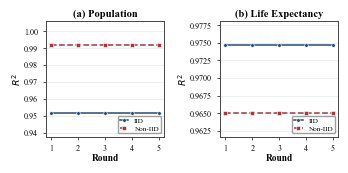

Fig. 5 (single-column, side-by-side, compact, no title) saved!


In [41]:
# ================================================================
# Cell 18 — Fig. 5: Federated Learning Convergence — IID + NON-IID
# FedStack (No KD, α_pop=0.0, α_life=0.0)
# Single reusable computation function; separate curves for
# IID and Non-IID plotted together for direct comparison.
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def compute_convergence(cdata, n_clients_this, n_rounds, label):
    """Runs OOF-fold convergence tracking for a given client partition
    (IID or Non-IID). Returns a list of per-round averaged metrics."""

    print("=" * 70)
    print(f"Generating convergence data from OOF folds — {label}")
    print("=" * 70)

    round_r2_pop   = [[] for _ in range(n_rounds)]
    round_r2_life  = [[] for _ in range(n_rounds)]
    round_mae_pop  = [[] for _ in range(n_rounds)]
    round_mae_life = [[] for _ in range(n_rounds)]
    round_rmse_pop  = [[] for _ in range(n_rounds)]
    round_rmse_life = [[] for _ in range(n_rounds)]

    total_folds = len(oof_folds)
    fold_times = []
    start_total = time.time()

    for fold_idx, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        fold_start = time.time()
        print(f"  Fold {fold_idx}/{total_folds} (train up to {fold_train_years[-1]}, val {fold_val_years[0]}) ...", end=" ", flush=True)

        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx = np.where(val_mask)[0]

        fold_cdata = get_client_subset_by_years(cdata, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_cdata)
        fold_server = FederatedServer(Config)

        # Round 1: pure local
        for c in fold_clients:
            c.train(1, None, None, 0.0, 0.0)

        X_tr = pd.concat([fold_cdata[cid]["X"] for cid in active_ids]).reset_index(drop=True)
        y_tr = pd.concat([fold_cdata[cid]["y"] for cid in active_ids]).reset_index(drop=True)
        fold_server.aggregate(fold_clients, X_tr,
                              y_tr[TARGET_POP].values,
                              y_tr[TARGET_LIFE].values)

        preds_val = fold_server.predict(fold_clients, X_train_global.iloc[val_idx])
        y_val_pop = df_train.iloc[val_idx][TARGET_POP].values
        y_val_life = df_train.iloc[val_idx][TARGET_LIFE].values

        r2p = r2_score(y_val_pop, preds_val['pop'])
        r2l = r2_score(y_val_life, preds_val['life'])
        maep = mean_absolute_error(y_val_pop, preds_val['pop'])
        mael = mean_absolute_error(y_val_life, preds_val['life'])
        rmsep = np.sqrt(mean_squared_error(y_val_pop, preds_val['pop']))
        rmsel = np.sqrt(mean_squared_error(y_val_life, preds_val['life']))

        round_r2_pop[0].append(r2p)
        round_r2_life[0].append(r2l)
        round_mae_pop[0].append(maep)
        round_mae_life[0].append(mael)
        round_rmse_pop[0].append(rmsep)
        round_rmse_life[0].append(rmsel)

        # Rounds 2..N_ROUNDS with α_pop=0.0, α_life=0.0 (no KD)
        for r in range(2, n_rounds + 1):
            gpop, glife = fold_server.get_global_predictions(fold_clients, X_tr)
            start_ptr = 0
            for c in fold_clients:
                cid = c.client_id
                ns = fold_cdata[cid]["n_samples"]
                c.train(r, gpop[start_ptr:start_ptr+ns], glife[start_ptr:start_ptr+ns],
                        alpha_pop=0.0, alpha_life=0.0)
                start_ptr += ns
            fold_server.aggregate(fold_clients, X_tr,
                                  y_tr[TARGET_POP].values,
                                  y_tr[TARGET_LIFE].values)

            preds_val = fold_server.predict(fold_clients, X_train_global.iloc[val_idx])
            r2p = r2_score(y_val_pop, preds_val['pop'])
            r2l = r2_score(y_val_life, preds_val['life'])
            maep = mean_absolute_error(y_val_pop, preds_val['pop'])
            mael = mean_absolute_error(y_val_life, preds_val['life'])
            rmsep = np.sqrt(mean_squared_error(y_val_pop, preds_val['pop']))
            rmsel = np.sqrt(mean_squared_error(y_val_life, preds_val['life']))

            round_r2_pop[r-1].append(r2p)
            round_r2_life[r-1].append(r2l)
            round_mae_pop[r-1].append(maep)
            round_mae_life[r-1].append(mael)
            round_rmse_pop[r-1].append(rmsep)
            round_rmse_life[r-1].append(rmsel)

        fold_time = time.time() - fold_start
        fold_times.append(fold_time)
        avg_time = np.mean(fold_times)
        remaining = total_folds - fold_idx
        eta = avg_time * remaining
        print(f"done ({fold_time:.1f}s) | Avg: {avg_time:.1f}s/fold | ETA: {eta:.1f}s (~{eta/60:.1f}m)")

    all_round_metrics = []
    for r_idx in range(n_rounds):
        all_round_metrics.append({
            'round': r_idx + 1,
            'r2_pop': np.mean(round_r2_pop[r_idx]),
            'r2_life': np.mean(round_r2_life[r_idx]),
            'mae_pop': np.mean(round_mae_pop[r_idx]),
            'mae_life': np.mean(round_mae_life[r_idx]),
            'rmse_pop': np.mean(round_rmse_pop[r_idx]),
            'rmse_life': np.mean(round_rmse_life[r_idx]),
        })
        print(f"Round {r_idx+1:2d} | Pop R²={all_round_metrics[-1]['r2_pop']:.4f} | Life R²={all_round_metrics[-1]['r2_life']:.4f}")

    total_time = time.time() - start_total
    print(f"\n✅ {label} — all folds completed in {total_time:.1f}s ({total_time/60:.1f}m)")
    return all_round_metrics

# ── Run for both settings ───────────────────────────────────────────
n_rounds = Config.N_ROUNDS

metrics_iid    = compute_convergence(client_data_iid,    Config.N_CLIENTS,   n_rounds, "IID")
metrics_noniid = compute_convergence(client_data_noniid, N_CLIENTS_NONIID,   n_rounds, "NON-IID")

# ---- Data for plotting ----
rounds = [m['round'] for m in metrics_iid]

r2_pop_iid    = [m['r2_pop']  for m in metrics_iid]
r2_life_iid   = [m['r2_life'] for m in metrics_iid]
r2_pop_non    = [m['r2_pop']  for m in metrics_noniid]
r2_life_non   = [m['r2_life'] for m in metrics_noniid]
# ================================================================
# Fig. 5 (Single-Column Version) — IID vs NON-IID CONVERGENCE
# Two separate stacked panels (Population, Life Expectancy)
# sized for IEEE single-column width.
# ================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 8.8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 7.8,
    "ytick.labelsize": 7.8,
    "legend.fontsize": 7.3,
    "axes.linewidth": 0.9,
    "axes.edgecolor": "#333333",
})

colors = {
    'iid': '#1F4E79',
    'noniid': '#A6373C',
}

def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(axis='y', linestyle='-', linewidth=0.5, color='#e2e2e2', zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.9)
        ax.spines[spine].set_color('#444444')
    ax.tick_params(axis='both', length=3.0, width=0.8, color='#333333')
    ax.set_xticks(rounds)
    ax.margins(x=0.04)

def zoomed_limits(values_list, pad_frac=0.35):
    all_vals = [v for vs in values_list for v in vs]
    lo, hi = min(all_vals), max(all_vals)
    span = hi - lo
    if span < 1e-9:
        span = abs(hi) * 0.001 + 1e-6
    pad = span * pad_frac
    return lo - pad, hi + pad


# ================================================================
# Fig. 5 (Single-Column, Side-by-Side, Compact) — IID vs NON-IID
# Two panels side by side, compressed to fit \columnwidth.
# No in-figure suptitle (caption handled in LaTeX).
# ================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 7.2,
    "axes.titlesize": 7.6,
    "axes.titleweight": "bold",
    "axes.labelsize": 6.8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 5.8,
    "ytick.labelsize": 5.8,
    "legend.fontsize": 5.6,
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#333333",
})

colors = {
    'iid': '#1F4E79',
    'noniid': '#A6373C',
}

def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(axis='y', linestyle='-', linewidth=0.4, color='#e2e2e2', zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.7)
        ax.spines[spine].set_color('#444444')
    ax.tick_params(axis='both', length=2.2, width=0.6, color='#333333')
    ax.set_xticks(rounds)
    ax.margins(x=0.05)

def zoomed_limits(values_list, pad_frac=0.35):
    all_vals = [v for vs in values_list for v in vs]
    lo, hi = min(all_vals), max(all_vals)
    span = hi - lo
    if span < 1e-9:
        span = abs(hi) * 0.001 + 1e-6
    pad = span * pad_frac
    return lo - pad, hi + pad

# IEEE single-column width ≈ 3.5 in. Side-by-side, compressed height,
# small fonts/markers so both panels remain legible at this width.
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.75), facecolor='white')

# ---- Panel (a): R² Population ----
ax = axes[0]
ax.plot(rounds, r2_pop_iid, 'o-', color=colors['iid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='IID', zorder=3)
ax.plot(rounds, r2_pop_non, 's--', color=colors['noniid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='Non-IID', zorder=3)
ax.set_title('(a) Population', pad=3)
ax.set_xlabel('Round', labelpad=1)
ax.set_ylabel('$R^{2}$', labelpad=1)
ylo, yhi = zoomed_limits([r2_pop_iid, r2_pop_non])
ax.set_ylim(ylo, yhi)
style_axis(ax)
ax.legend(loc='lower right', fontsize=5.2, frameon=True, edgecolor='#999999',
          framealpha=0.95, handlelength=1.2, borderpad=0.25, labelspacing=0.25)

# ---- Panel (b): R² Life Expectancy ----
ax = axes[1]
ax.plot(rounds, r2_life_iid, 'o-', color=colors['iid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='IID', zorder=3)
ax.plot(rounds, r2_life_non, 's--', color=colors['noniid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='Non-IID', zorder=3)
ax.set_title('(b) Life Expectancy', pad=3)
ax.set_xlabel('Round', labelpad=1)
ax.set_ylabel('$R^{2}$', labelpad=1)
ylo, yhi = zoomed_limits([r2_life_iid, r2_life_non])
ax.set_ylim(ylo, yhi)
style_axis(ax)
ax.legend(loc='lower right', fontsize=5.2, frameon=True, edgecolor='#999999',
          framealpha=0.95, handlelength=1.2, borderpad=0.25, labelspacing=0.25)

fig.tight_layout(w_pad=1.2)
fig.savefig(f"{Config.FIGURES_DIR}fig5_federated_convergence_iid_vs_noniid_singlecol.png",
            dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(f"{Config.FIGURES_DIR}fig5_federated_convergence_iid_vs_noniid_singlecol.pdf",
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig. 5 (single-column, side-by-side, compact, no title) saved!")


Hardcoded

Generating convergence data from OOF folds — IID
  Fold 1/19 (train up to 2002, val 2003) ... done (13.8s) | Avg: 13.8s/fold | ETA: 249.0s (~4.2m)
  Fold 2/19 (train up to 2003, val 2004) ... done (16.1s) | Avg: 15.0s/fold | ETA: 254.3s (~4.2m)
  Fold 3/19 (train up to 2004, val 2005) ... done (18.7s) | Avg: 16.2s/fold | ETA: 259.0s (~4.3m)
  Fold 4/19 (train up to 2005, val 2006) ... done (20.5s) | Avg: 17.3s/fold | ETA: 259.0s (~4.3m)
  Fold 5/19 (train up to 2006, val 2007) ... done (22.4s) | Avg: 18.3s/fold | ETA: 256.0s (~4.3m)
  Fold 6/19 (train up to 2007, val 2008) ... done (24.8s) | Avg: 19.4s/fold | ETA: 251.8s (~4.2m)
  Fold 7/19 (train up to 2008, val 2009) ... done (26.9s) | Avg: 20.4s/fold | ETA: 245.3s (~4.1m)
  Fold 8/19 (train up to 2009, val 2010) ... done (29.4s) | Avg: 21.6s/fold | ETA: 237.1s (~4.0m)
  Fold 9/19 (train up to 2010, val 2011) ... done (31.0s) | Avg: 22.6s/fold | ETA: 226.1s (~3.8m)
  Fold 10/19 (train up to 2011, val 2012) ... done (34.5s) | Avg: 23.

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


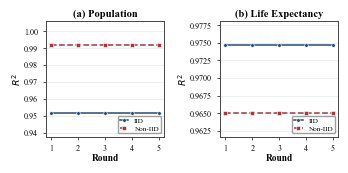

Fig. 5 (T=5, single-column, side-by-side, compact) saved!
  Final IID:     Pop R²=0.9518, Life R²=0.9747
  Final Non-IID: Pop R²=0.9919, Life R²=0.9650


In [42]:
# ================================================================
# Cell 18 — Fig. 5: Federated Learning Convergence — IID + NON-IID
# FedStack (No KD, α_pop=0.0, α_life=0.0)
#
# UPDATED: n_rounds hardcoded to 5 (matching the paper's new T=5
# default) so this cell can be re-run standalone, on top of the
# already-loaded client_data_iid / client_data_noniid / oof_folds
# from the earlier full run, WITHOUT re-running the entire notebook.
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def compute_convergence(cdata, n_clients_this, n_rounds, label):
    """Runs OOF-fold convergence tracking for a given client partition
    (IID or Non-IID). Returns a list of per-round averaged metrics."""

    print("=" * 70)
    print(f"Generating convergence data from OOF folds — {label}")
    print("=" * 70)

    round_r2_pop   = [[] for _ in range(n_rounds)]
    round_r2_life  = [[] for _ in range(n_rounds)]
    round_mae_pop  = [[] for _ in range(n_rounds)]
    round_mae_life = [[] for _ in range(n_rounds)]
    round_rmse_pop  = [[] for _ in range(n_rounds)]
    round_rmse_life = [[] for _ in range(n_rounds)]

    total_folds = len(oof_folds)
    fold_times = []
    start_total = time.time()

    for fold_idx, (fold_train_years, fold_val_years) in enumerate(oof_folds, start=1):
        fold_start = time.time()
        print(f"  Fold {fold_idx}/{total_folds} (train up to {fold_train_years[-1]}, val {fold_val_years[0]}) ...", end=" ", flush=True)

        val_mask = df_train["Year"].isin(fold_val_years).values
        val_idx = np.where(val_mask)[0]

        fold_cdata = get_client_subset_by_years(cdata, fold_train_years)
        fold_clients, active_ids = init_clients_from_subset(fold_cdata)
        fold_server = FederatedServer(Config)

        # Round 1: pure local
        for c in fold_clients:
            c.train(1, None, None, 0.0, 0.0)

        X_tr = pd.concat([fold_cdata[cid]["X"] for cid in active_ids]).reset_index(drop=True)
        y_tr = pd.concat([fold_cdata[cid]["y"] for cid in active_ids]).reset_index(drop=True)
        fold_server.aggregate(fold_clients, X_tr,
                              y_tr[TARGET_POP].values,
                              y_tr[TARGET_LIFE].values)

        preds_val = fold_server.predict(fold_clients, X_train_global.iloc[val_idx])
        y_val_pop = df_train.iloc[val_idx][TARGET_POP].values
        y_val_life = df_train.iloc[val_idx][TARGET_LIFE].values

        r2p = r2_score(y_val_pop, preds_val['pop'])
        r2l = r2_score(y_val_life, preds_val['life'])
        maep = mean_absolute_error(y_val_pop, preds_val['pop'])
        mael = mean_absolute_error(y_val_life, preds_val['life'])
        rmsep = np.sqrt(mean_squared_error(y_val_pop, preds_val['pop']))
        rmsel = np.sqrt(mean_squared_error(y_val_life, preds_val['life']))

        round_r2_pop[0].append(r2p)
        round_r2_life[0].append(r2l)
        round_mae_pop[0].append(maep)
        round_mae_life[0].append(mael)
        round_rmse_pop[0].append(rmsep)
        round_rmse_life[0].append(rmsel)

        # Rounds 2..N_ROUNDS with α_pop=0.0, α_life=0.0 (no KD)
        for r in range(2, n_rounds + 1):
            gpop, glife = fold_server.get_global_predictions(fold_clients, X_tr)
            start_ptr = 0
            for c in fold_clients:
                cid = c.client_id
                ns = fold_cdata[cid]["n_samples"]
                c.train(r, gpop[start_ptr:start_ptr+ns], glife[start_ptr:start_ptr+ns],
                        alpha_pop=0.0, alpha_life=0.0)
                start_ptr += ns
            fold_server.aggregate(fold_clients, X_tr,
                                  y_tr[TARGET_POP].values,
                                  y_tr[TARGET_LIFE].values)

            preds_val = fold_server.predict(fold_clients, X_train_global.iloc[val_idx])
            r2p = r2_score(y_val_pop, preds_val['pop'])
            r2l = r2_score(y_val_life, preds_val['life'])
            maep = mean_absolute_error(y_val_pop, preds_val['pop'])
            mael = mean_absolute_error(y_val_life, preds_val['life'])
            rmsep = np.sqrt(mean_squared_error(y_val_pop, preds_val['pop']))
            rmsel = np.sqrt(mean_squared_error(y_val_life, preds_val['life']))

            round_r2_pop[r-1].append(r2p)
            round_r2_life[r-1].append(r2l)
            round_mae_pop[r-1].append(maep)
            round_mae_life[r-1].append(mael)
            round_rmse_pop[r-1].append(rmsep)
            round_rmse_life[r-1].append(rmsel)

        fold_time = time.time() - fold_start
        fold_times.append(fold_time)
        avg_time = np.mean(fold_times)
        remaining = total_folds - fold_idx
        eta = avg_time * remaining
        print(f"done ({fold_time:.1f}s) | Avg: {avg_time:.1f}s/fold | ETA: {eta:.1f}s (~{eta/60:.1f}m)")

    all_round_metrics = []
    for r_idx in range(n_rounds):
        all_round_metrics.append({
            'round': r_idx + 1,
            'r2_pop': np.mean(round_r2_pop[r_idx]),
            'r2_life': np.mean(round_r2_life[r_idx]),
            'mae_pop': np.mean(round_mae_pop[r_idx]),
            'mae_life': np.mean(round_mae_life[r_idx]),
            'rmse_pop': np.mean(round_rmse_pop[r_idx]),
            'rmse_life': np.mean(round_rmse_life[r_idx]),
        })
        print(f"Round {r_idx+1:2d} | Pop R²={all_round_metrics[-1]['r2_pop']:.4f} | Life R²={all_round_metrics[-1]['r2_life']:.4f}")

    total_time = time.time() - start_total
    print(f"\n {label} — all folds completed in {total_time:.1f}s ({total_time/60:.1f}m)")
    return all_round_metrics


# ── Run for both settings ───────────────────────────────────────────
# paper's round-sensitivity analysis switched the default to T=5).
n_rounds = 5

metrics_iid    = compute_convergence(client_data_iid,    Config.N_CLIENTS,   n_rounds, "IID")
metrics_noniid = compute_convergence(client_data_noniid, N_CLIENTS_NONIID,   n_rounds, "NON-IID")

# ---- Data for plotting ----
rounds = [m['round'] for m in metrics_iid]

r2_pop_iid    = [m['r2_pop']  for m in metrics_iid]
r2_life_iid   = [m['r2_life'] for m in metrics_iid]
r2_pop_non    = [m['r2_pop']  for m in metrics_noniid]
r2_life_non   = [m['r2_life'] for m in metrics_noniid]

# ================================================================
# Fig. 5 (Single-Column, Side-by-Side, Compact) — IID vs NON-IID
# Two panels side by side, compressed to fit \columnwidth.
# No in-figure suptitle (caption handled in LaTeX).
# ================================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 7.2,
    "axes.titlesize": 7.6,
    "axes.titleweight": "bold",
    "axes.labelsize": 6.8,
    "axes.labelweight": "bold",
    "xtick.labelsize": 5.8,
    "ytick.labelsize": 5.8,
    "legend.fontsize": 5.6,
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#333333",
})

colors = {
    'iid': '#1F4E79',
    'noniid': '#A6373C',
}

def style_axis(ax):
    ax.set_facecolor('white')
    ax.grid(axis='y', linestyle='-', linewidth=0.4, color='#e2e2e2', zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.7)
        ax.spines[spine].set_color('#444444')
    ax.tick_params(axis='both', length=2.2, width=0.6, color='#333333')
    ax.set_xticks(rounds)   # now correctly ticks 1..5, not 1..10
    ax.margins(x=0.05)

def zoomed_limits(values_list, pad_frac=0.35):
    all_vals = [v for vs in values_list for v in vs]
    lo, hi = min(all_vals), max(all_vals)
    span = hi - lo
    if span < 1e-9:
        span = abs(hi) * 0.001 + 1e-6
    pad = span * pad_frac
    return lo - pad, hi + pad

# IEEE single-column width ≈ 3.5 in. Side-by-side, compressed height,
# small fonts/markers so both panels remain legible at this width.
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.75), facecolor='white')

# ---- Panel (a): R² Population ----
ax = axes[0]
ax.plot(rounds, r2_pop_iid, 'o-', color=colors['iid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='IID', zorder=3)
ax.plot(rounds, r2_pop_non, 's--', color=colors['noniid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='Non-IID', zorder=3)
ax.set_title('(a) Population', pad=3)
ax.set_xlabel('Round', labelpad=1)
ax.set_ylabel('$R^{2}$', labelpad=1)
ylo, yhi = zoomed_limits([r2_pop_iid, r2_pop_non])
ax.set_ylim(ylo, yhi)
style_axis(ax)
ax.legend(loc='lower right', fontsize=5.2, frameon=True, edgecolor='#999999',
          framealpha=0.95, handlelength=1.2, borderpad=0.25, labelspacing=0.25)

# ---- Panel (b): R² Life Expectancy ----
ax = axes[1]
ax.plot(rounds, r2_life_iid, 'o-', color=colors['iid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='IID', zorder=3)
ax.plot(rounds, r2_life_non, 's--', color=colors['noniid'], linewidth=1.1, markersize=2.6,
        markeredgecolor='white', markeredgewidth=0.4, label='Non-IID', zorder=3)
ax.set_title('(b) Life Expectancy', pad=3)
ax.set_xlabel('Round', labelpad=1)
ax.set_ylabel('$R^{2}$', labelpad=1)
ylo, yhi = zoomed_limits([r2_life_iid, r2_life_non])
ax.set_ylim(ylo, yhi)
style_axis(ax)
ax.legend(loc='lower right', fontsize=5.2, frameon=True, edgecolor='#999999',
          framealpha=0.95, handlelength=1.2, borderpad=0.25, labelspacing=0.25)

fig.tight_layout(w_pad=1.2)
fig.savefig(f"{Config.FIGURES_DIR}fig5_federated_convergence_iid_vs_noniid_singlecol.png",
            dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(f"{Config.FIGURES_DIR}fig5_federated_convergence_iid_vs_noniid_singlecol.pdf",
            bbox_inches='tight', facecolor='white')
plt.show()
print("Fig. 5 (T=5, single-column, side-by-side, compact) saved!")
print(f"  Final IID:     Pop R²={r2_pop_iid[-1]:.4f}, Life R²={r2_life_iid[-1]:.4f}")
print(f"  Final Non-IID: Pop R²={r2_pop_non[-1]:.4f}, Life R²={r2_life_non[-1]:.4f}")

# Cell 20 — All model Comparison

For single coulmn


############################################################################################
#  IID RESULTS
############################################################################################
  ✔ Fed.Ensemble (Baseline) → Pop R²=0.5243  WMAPE=0.3814
  ✔ FedStack (Proposed)    → Pop R²=0.9583  WMAPE=0.2540
  ✔ FedStack+KD (Ablation) → Pop R²=0.9514  WMAPE=0.3279
  ✔ Centralized (Single, Upper) → Pop R²=0.9597  WMAPE=0.0818

  TABLE II — COMPLETE METHOD COMPARISON — IID  [Test Set 2022–2024]
  Method                          Pop R²   Pop RMSE   WMAPE  Life R²  Life RMSE     MAE
  ────────────────────────────────────────────────────────────────────────────────────
  Federated Ensemble (Baseline)   0.5243    104.34M  0.3814   0.9360    1.8940yr  1.3206yr
  FedStack (Proposed)             0.9583     30.89M  0.2540   0.9489    1.6919yr  1.1031yr
  FedStack+KD (Ablation)          0.9514     33.36M  0.3279   0.9489    1.6919yr  1.1031yr
  Centralized (Single, Upper Bound)  0.9597    

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


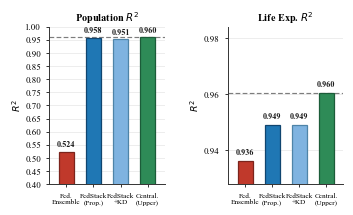

Fig. 6 (IID) saved → figures/fig6_4method_comparison_iid.png (600 DPI) and .pdf (vector)

   IMPROVEMENT OVER BASELINE — IID  (Fed.Ensemble → FedStack)
  Pop  R²    : 0.5243 → 0.9583  (+0.4340)
  Pop  WMAPE : 0.3814 → 0.2540  (-0.1274)
  Pop  RMSE  : 104.34M → 30.89M  (-73.45M)
  Life R²    : 0.9360 → 0.9489  (+0.0129)
  Life MAE   : 1.3206 → 1.1031  (-0.2175)

   GAP vs Centralized (Single) — IID
  Pop  R² gap  : +0.0014  (Negligible)
  Life R² gap  : +0.0114  (Acceptable)

   Centralized : raw data pooled on server  ❌ Privacy risk
   FedStack    : only model weights shared  ✅ Privacy preserved

############################################################################################
#  NON-IID RESULTS (Continent-based)
############################################################################################
  ✔ Fed.Ensemble (Baseline) → Pop R²=0.4258  WMAPE=0.4775
  ✔ FedStack (Proposed)    → Pop R²=0.9504  WMAPE=0.1389
  ✔ FedStack+KD (Ablation) → Pop R²=0.9462  WMAPE=0.1515
 

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


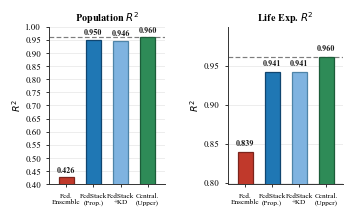

Fig. 6 (Non-IID) saved → figures/fig6_4method_comparison_noniid.png (600 DPI) and .pdf (vector)

   IMPROVEMENT OVER BASELINE — Non-IID  (Fed.Ensemble → FedStack)
  Pop  R²    : 0.4258 → 0.9504  (+0.5246)
  Pop  WMAPE : 0.4775 → 0.1389  (-0.3386)
  Pop  RMSE  : 114.64M → 33.70M  (-80.94M)
  Life R²    : 0.8394 → 0.9414  (+0.1020)
  Life MAE   : 2.2123 → 1.2418  (-0.9705)

   GAP vs Centralized (Single) — Non-IID
  Pop  R² gap  : +0.0093  (Notable)
  Life R² gap  : +0.0189  (Acceptable)

   Centralized : raw data pooled on server  ❌ Privacy risk
   FedStack    : only model weights shared  ✅ Privacy preserved


In [43]:
# ================================================================
# Cell 20 — TABLE II & Fig. 6: Complete 4-Method Comparison — IID + NON-IID
# (Fig. 6 plotting block: high-resolution, professional IEEE styling.
#  Single reusable function; run once for IID, once for Non-IID.)
#
# BUG FIX: The final calls were passing `cent_metrics` (the
# "Centralized (Ensemble)" variant, R²=0.9506/0.9680) into
# extract_metrics(), while the paper's Table V uses
# `cent_metrics_single` ("Centralized (Single)", R²=0.9597/0.9603).
# This caused Fig. 6's dashed reference line and Table II's
# Centralized row to disagree with Table V. Fixed by using
# cent_metrics_single consistently below.
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Safety reload: IID ───────────────────────────────────────────
for var_name, file_name in [
    ('fedavg_metrics', 'fedavg_metrics.pkl'),
    ('stacking_metrics', 'stacking_metrics.pkl'),
    ('kd_metrics', 'flkdmetrics.pkl'),
    ('cent_metrics_single', 'centralized_metrics_single.pkl'),  # FIX: use Single, not Ensemble
]:
    if var_name not in globals():
        globals()[var_name] = joblib.load(f"{Config.MODELS_DIR}{file_name}")
        print(f"  ↺ Reloaded {var_name} from disk")

# ── Safety reload: Non-IID ────────────────────────────────────────
for var_name, file_name in [
    ('fedavg_metrics_noniid', 'fedavg_metrics_noniid.pkl'),
    ('stacking_metrics_noniid', 'stacking_metrics_noniid.pkl'),
    ('kd_metrics_noniid', 'flkdmetrics_noniid.pkl'),
]:
    if var_name not in globals():
        globals()[var_name] = joblib.load(f"{Config.MODELS_DIR}{file_name}")
        print(f"  ↺ Reloaded {var_name} from disk")


def extract_metrics(fedavg_m, stacking_m, kd_m, cent_m):
    """Extracts flat metric values from the 4 method dicts."""
    def g(m, split, metric, scale=1):
        return float(m[split][metric]) / scale

    vals = {
        'fa_pop_r2': g(fedavg_m, 'pop_test', 'R2'),   'fa_pop_rmse': g(fedavg_m, 'pop_test', 'RMSE'),
        'fa_pop_wmape': g(fedavg_m, 'pop_test', 'PCT', 100),
        'fa_life_r2': g(fedavg_m, 'life_test', 'R2'), 'fa_life_rmse': g(fedavg_m, 'life_test', 'RMSE'),
        'fa_life_mae': g(fedavg_m, 'life_test', 'MAE'),

        'st_pop_r2': g(stacking_m, 'pop_test', 'R2'),   'st_pop_rmse': g(stacking_m, 'pop_test', 'RMSE'),
        'st_pop_wmape': g(stacking_m, 'pop_test', 'PCT', 100),
        'st_life_r2': g(stacking_m, 'life_test', 'R2'), 'st_life_rmse': g(stacking_m, 'life_test', 'RMSE'),
        'st_life_mae': g(stacking_m, 'life_test', 'MAE'),

        'kd_pop_r2': g(kd_m, 'pop_test', 'R2'),   'kd_pop_rmse': g(kd_m, 'pop_test', 'RMSE'),
        'kd_pop_wmape': g(kd_m, 'pop_test', 'PCT', 100),
        'kd_life_r2': g(kd_m, 'life_test', 'R2'), 'kd_life_rmse': g(kd_m, 'life_test', 'RMSE'),
        'kd_life_mae': g(kd_m, 'life_test', 'MAE'),

        'ce_pop_r2': g(cent_m, 'pop_test', 'R2'),   'ce_pop_rmse': g(cent_m, 'pop_test', 'RMSE'),
        'ce_pop_wmape': g(cent_m, 'pop_test', 'PCT', 100),
        'ce_life_r2': g(cent_m, 'life_test', 'R2'), 'ce_life_rmse': g(cent_m, 'life_test', 'RMSE'),
        'ce_life_mae': g(cent_m, 'life_test', 'MAE'),
    }
    return vals


def print_table_and_figure(v, label, save_suffix):
    """Prints Table II and generates the professional IEEE single-column
    Fig. 6 for a given partition setting (IID or Non-IID)."""

    print(f"  ✔ Fed.Ensemble (Baseline) → Pop R²={v['fa_pop_r2']:.4f}  WMAPE={v['fa_pop_wmape']:.4f}")
    print(f"  ✔ FedStack (Proposed)    → Pop R²={v['st_pop_r2']:.4f}  WMAPE={v['st_pop_wmape']:.4f}")
    print(f"  ✔ FedStack+KD (Ablation) → Pop R²={v['kd_pop_r2']:.4f}  WMAPE={v['kd_pop_wmape']:.4f}")
    print(f"  ✔ Centralized (Single, Upper) → Pop R²={v['ce_pop_r2']:.4f}  WMAPE={v['ce_pop_wmape']:.4f}")

    print()
    print("=" * 92)
    print(f"  TABLE II — COMPLETE METHOD COMPARISON — {label}  [Test Set 2022–2024]")
    print("=" * 92)
    print(f"  {'Method':<30} {'Pop R²':>7} {'Pop RMSE':>10} {'WMAPE':>7} "
          f"{'Life R²':>8} {'Life RMSE':>10} {'MAE':>7}")
    print(f"  {'─'*84}")

    rows = [
        ('Federated Ensemble (Baseline)', v['fa_pop_r2'], v['fa_pop_rmse'], v['fa_pop_wmape'],
         v['fa_life_r2'], v['fa_life_rmse'], v['fa_life_mae']),
        ('FedStack (Proposed)',          v['st_pop_r2'], v['st_pop_rmse'], v['st_pop_wmape'],
         v['st_life_r2'], v['st_life_rmse'], v['st_life_mae']),
        ('FedStack+KD (Ablation)',       v['kd_pop_r2'], v['kd_pop_rmse'], v['kd_pop_wmape'],
         v['kd_life_r2'], v['kd_life_rmse'], v['kd_life_mae']),
        ('Centralized (Single, Upper Bound)', v['ce_pop_r2'], v['ce_pop_rmse'], v['ce_pop_wmape'],
         v['ce_life_r2'], v['ce_life_rmse'], v['ce_life_mae']),
    ]

    for name, pr2, prmse, pwmape, lr2, lrmse, lmae in rows:
        print(f"  {name:<30} {pr2:>7.4f} {prmse/1e6:>9.2f}M {pwmape:>7.4f} "
              f"{lr2:>8.4f} {lrmse:>9.4f}yr {lmae:>7.4f}yr")

    print("=" * 92)
    print("  WMAPE: Population (scale‑invariant fraction)")
    print("  MAE  : Life Expectancy in years (policy‑interpretable)")

    # ── Save CSV ──────────────────────────────────────────────────
    df_table2 = pd.DataFrame({
        'Method'    : [r[0] for r in rows],
        'Pop R²'    : [r[1] for r in rows],
        'Pop RMSE'  : [f"{r[2]/1e6:.2f}M" for r in rows],
        'Pop WMAPE' : [f"{r[3]:.4f}" for r in rows],
        'Life R²'   : [r[4] for r in rows],
        'Life RMSE' : [f"{r[5]:.4f}yr" for r in rows],
        'Life MAE'  : [f"{r[6]:.4f}yr" for r in rows],
    })
    out_csv = f"{Config.OUTPUT_DIR}table2_method_comparison_{save_suffix}.csv"
    df_table2.to_csv(out_csv, index=False)
    print(f"\n  💾 TABLE II ({label}) → {out_csv}")

    # ============================================================
    # ── Fig. 6 (IEEE Ready) — SINGLE-COLUMN, SIDE-BY-SIDE, COMPACT ──
    # ============================================================
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 7.2,
        "axes.titlesize": 7.8,
        "axes.titleweight": "bold",
        "axes.labelsize": 7.4,
        "axes.labelweight": "bold",
        "xtick.labelsize": 5.6,
        "ytick.labelsize": 6.4,
        "legend.fontsize": 6.0,
        "axes.linewidth": 0.7,
        "axes.edgecolor": "#333333",
    })

    fig6, axes = plt.subplots(1, 2, figsize=(3.5, 2.25), facecolor='white')

    labels  = ['Fed.\nEnsemble', 'FedStack\n(Prop.)',
               'FedStack\n+KD', 'Central.\n(Upper)']
    colors      = ['#C0392B', '#1F77B4', '#7FB3E0', '#2E8B57']
    edge_colors = ['#7B241C', '#10456F', '#4E84A8', '#1C5C39']

    x = np.arange(4)
    bar_width = 0.55
    pop_r2_vals  = [v['fa_pop_r2'],  v['st_pop_r2'],  v['kd_pop_r2'],  v['ce_pop_r2']]
    life_r2_vals = [v['fa_life_r2'], v['st_life_r2'], v['kd_life_r2'], v['ce_life_r2']]

    def dynamic_ylim(vals, top_pad_frac=0.16, bottom_pad_frac=0.34):
        lo, hi = min(vals), max(vals)
        span = hi - lo if hi > lo else 0.02
        return (max(0, lo - span * bottom_pad_frac), min(1.06, hi + span * top_pad_frac + 0.02))

    panel_specs = [
        (axes[0], pop_r2_vals,  'Population $R^{2}$', (0.40, 1.00)),   # FIX: fixed clean range
        (axes[1], life_r2_vals, 'Life Exp. $R^{2}$', dynamic_ylim(life_r2_vals)),
    ]

    for ax, r2_vals, title, ylim in panel_specs:
        span = ylim[1] - ylim[0]
        upper_bound = r2_vals[-1]

        ax.set_facecolor('white')
        bars = ax.bar(
            x, r2_vals, width=bar_width,
            color=colors, edgecolor=edge_colors, linewidth=0.9, zorder=3,
        )

        ax.axhline(
            upper_bound, color='#666666', linestyle=(0, (4, 2)),
            linewidth=0.85, zorder=2, alpha=0.85,
        )

        # Use a slightly smaller label offset so values near the top of a
        # fixed range (e.g. Population's 0.40–1.00) don't get clipped.
        label_offset = min(span * 0.03, 0.012)
        for xi, val in zip(x, r2_vals):
            ax.text(
                xi, val + label_offset, f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=5.9, fontweight='bold', color='#1a1a1a', zorder=4,
            )

        ax.set_title(title, fontweight='bold', pad=4, fontsize=7.4)
        ax.set_ylabel('$R^{2}$', labelpad=2, fontsize=6.8)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=5.2, linespacing=1.05)
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05 if span > 0.2 else 0.02))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

        ax.grid(axis='y', linestyle='-', linewidth=0.4, color='#e0e0e0', zorder=0)
        ax.set_axisbelow(True)

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.spines['left'].set_linewidth(0.7)
        ax.spines['bottom'].set_linewidth(0.7)
        ax.tick_params(axis='both', length=2.4, width=0.7, color='#333333')
        ax.margins(x=0.10)

    fig6.subplots_adjust(left=0.14, right=0.98, top=0.90, bottom=0.20, wspace=0.55)

    out_png = f"{Config.FIGURES_DIR}fig6_4method_comparison_{save_suffix}.png"
    out_pdf = f"{Config.FIGURES_DIR}fig6_4method_comparison_{save_suffix}.pdf"
    fig6.savefig(out_png, dpi=600, facecolor='white')
    fig6.savefig(out_pdf, facecolor='white')
    plt.show()
    print(f"Fig. 6 ({label}) saved → {out_png} (600 DPI) and .pdf (vector)")

    # ── Improvement Summary ─────────────────────────────────────────
    print()
    print("=" * 80)
    print(f"   IMPROVEMENT OVER BASELINE — {label}  (Fed.Ensemble → FedStack)")
    print("=" * 80)
    print(f"  Pop  R²    : {v['fa_pop_r2']:.4f} → {v['st_pop_r2']:.4f}  ({v['st_pop_r2']-v['fa_pop_r2']:+.4f})")
    print(f"  Pop  WMAPE : {v['fa_pop_wmape']:.4f} → {v['st_pop_wmape']:.4f}  ({v['st_pop_wmape']-v['fa_pop_wmape']:+.4f})")
    print(f"  Pop  RMSE  : {v['fa_pop_rmse']/1e6:.2f}M → {v['st_pop_rmse']/1e6:.2f}M  "
          f"({(v['st_pop_rmse']-v['fa_pop_rmse'])/1e6:+.2f}M)")
    print(f"  Life R²    : {v['fa_life_r2']:.4f} → {v['st_life_r2']:.4f}  ({v['st_life_r2']-v['fa_life_r2']:+.4f})")
    print(f"  Life MAE   : {v['fa_life_mae']:.4f} → {v['st_life_mae']:.4f}  ({v['st_life_mae']-v['fa_life_mae']:+.4f})")
    print()
    print("=" * 80)
    print(f"   GAP vs Centralized (Single) — {label}")
    print("=" * 80)
    gap_pop  = v['ce_pop_r2']  - v['st_pop_r2']
    gap_life = v['ce_life_r2'] - v['st_life_r2']
    print(f"  Pop  R² gap  : {gap_pop:+.4f}  "
          f"({'Negligible' if abs(gap_pop) < 0.002 else 'Notable'})")
    print(f"  Life R² gap  : {gap_life:+.4f}  "
          f"({'Acceptable' if abs(gap_life) < 0.02 else 'Notable'})")
    print()
    print("   Centralized : raw data pooled on server  ❌ Privacy risk")
    print("   FedStack    : only model weights shared  ✅ Privacy preserved")
    print("=" * 80)

    return df_table2


# ── Run for IID ──────────────────────────────────────────────────
print("\n" + "#" * 92)
print("#  IID RESULTS")
print("#" * 92)
v_iid = extract_metrics(fedavg_metrics, stacking_metrics, kd_metrics, cent_metrics_single)  # FIX
df_table2_iid = print_table_and_figure(v_iid, label="IID", save_suffix="iid")

# ── Run for Non-IID ──────────────────────────────────────────────
print("\n" + "#" * 92)
print("#  NON-IID RESULTS (Continent-based)")
print("#" * 92)
v_noniid = extract_metrics(fedavg_metrics_noniid, stacking_metrics_noniid, kd_metrics_noniid, cent_metrics_single)  # FIX
df_table2_noniid = print_table_and_figure(v_noniid, label="Non-IID", save_suffix="noniid")

# Cell 20.5   Statistical Significance Test

In [44]:
# ================================================================
# Cell 20.5 — STATISTICAL SIGNIFICANCE TEST — IID + NON-IID
# (Federated Ensemble vs FedStack (Proposed))
# ================================================================
from scipy import stats
import pandas as pd
import numpy as np
import joblib
import os

TARGET_POP  = Config.TARGET_COLUMNS[0]
TARGET_LIFE = Config.TARGET_COLUMNS[1]

if 'y_test_pop_fa' not in globals() or 'y_test_life_fa' not in globals():
    y_test_pop_fa  = df_test[TARGET_POP].values
    y_test_life_fa = df_test[TARGET_LIFE].values


def cohen_d_pooled(a, b):
    n1, n2 = len(a), len(b)
    s1, s2 = np.std(a, ddof=1), np.std(b, ddof=1)
    pooled_std = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (np.mean(a) - np.mean(b)) / (pooled_std + 1e-10)

def interpret_d(d):
    ad = abs(d)
    if   ad >= 0.80: return "Large"
    elif ad >= 0.50: return "Medium"
    elif ad >= 0.20: return "Small"
    else:            return "Negligible"


def run_significance_test(fedavg_preds_path, fedstack_server_path, fedstack_clients_path,
                           label, save_suffix):
    print("=" * 70)
    print(f"STATISTICAL SIGNIFICANCE TEST — {label}")
    print("Wilcoxon Signed-Rank: Federated Ensemble vs FedStack (per-sample errors)")
    print("=" * 70)

    # ── Baseline (FedAvg) predictions ───────────────────────────
    preds_fa = joblib.load(fedavg_preds_path)
    fedavg_pop_t  = preds_fa['pop']
    fedavg_life_t = preds_fa['life']
    print(f"  ↺ Loaded baseline predictions from {fedavg_preds_path}")

    # ── FedStack (proposed) server & clients ────────────────────
    server  = joblib.load(fedstack_server_path)
    clients = joblib.load(fedstack_clients_path)
    print(f"  ↺ Loaded FedStack server & clients from disk")

    fed_test_preds = server.predict(clients, X_test_global)

    # ── Per-sample absolute errors ──────────────────────────────
    err_fedavg_pop    = np.abs(y_test_pop_fa  - fedavg_pop_t)
    err_fedavg_life   = np.abs(y_test_life_fa - fedavg_life_t)
    err_fedstack_pop  = np.abs(y_test_pop_fa  - fed_test_preds['pop'])
    err_fedstack_life = np.abs(y_test_life_fa - fed_test_preds['life'])

    print(f"\n  Test samples : {len(err_fedavg_pop)}")
    print(f"  Federated Ensemble mean pop  error : {err_fedavg_pop.mean()/1e6:.3f}M")
    print(f"  FedStack             mean pop  error : {err_fedstack_pop.mean()/1e6:.3f}M")
    print(f"  Federated Ensemble mean life error : {err_fedavg_life.mean():.4f}")
    print(f"  FedStack             mean life error : {err_fedstack_life.mean():.4f}")

    # ── Wilcoxon Signed-Rank Test ────────────────────────────────
    stat_pop,  p_pop  = stats.wilcoxon(
        err_fedavg_pop,  err_fedstack_pop,
        alternative='greater', zero_method='wilcox'
    )
    stat_life, p_life = stats.wilcoxon(
        err_fedavg_life, err_fedstack_life,
        alternative='greater', zero_method='wilcox'
    )

    print(f"\n  Population Prediction:")
    print(f"    H₁: Federated Ensemble error > FedStack error")
    print(f"    Wilcoxon W  = {stat_pop:.2f}")
    print(f"    p-value     = {p_pop:.6f}  "
          f"{' Significant (p<0.05)' if p_pop < 0.05 else '❌ Not significant'}")

    print(f"\n  Life Expectancy Prediction:")
    print(f"    H₁: Federated Ensemble error > FedStack error")
    print(f"    Wilcoxon W  = {stat_life:.2f}")
    print(f"    p-value     = {p_life:.6f}  "
          f"{' Significant (p<0.05)' if p_life < 0.05 else '❌ Not significant'}")

    # ── Cohen's d ────────────────────────────────────────────────
    d_pop  = cohen_d_pooled(err_fedavg_pop,  err_fedstack_pop)
    d_life = cohen_d_pooled(err_fedavg_life, err_fedstack_life)

    print(f"\n  Effect Size (Cohen's d — pooled std):")
    print(f"    Population     : d = {d_pop:.4f}  [{interpret_d(d_pop)}]")
    print(f"    Life Expectancy: d = {d_life:.4f}  [{interpret_d(d_life)}]")

    # ── Summary Table ────────────────────────────────────────────
    df_sig = pd.DataFrame({
        'Target'       : ['Population', 'Life Expectancy'],
        'W statistic'  : [round(stat_pop,2), round(stat_life,2)],
        'p-value'      : [round(p_pop,6),    round(p_life,6)],
        'Significant'  : ['Yes' if p_pop<0.05 else 'No',
                          'Yes' if p_life<0.05 else 'No'],
        "Cohen's d"    : [round(d_pop,4),    round(d_life,4)],
        'Effect Size'  : [interpret_d(d_pop), interpret_d(d_life)],
    })

    print()
    print(df_sig.to_string(index=False))

    # ── Save ─────────────────────────────────────────────────────
    sig_results = {
        'pop_stat' : stat_pop,  'pop_p' : p_pop,  'pop_d' : d_pop,
        'life_stat': stat_life, 'life_p': p_life, 'life_d': d_life,
    }
    joblib.dump(sig_results, f"{Config.MODELS_DIR}significance_test_{save_suffix}.pkl")
    out_csv = f"{Config.OUTPUT_DIR}significance_test_{save_suffix}.csv"
    df_sig.to_csv(out_csv, index=False)
    print(f"\n  💾 Saved → {out_csv}")
    print("=" * 70)

    return df_sig


# ── Run for IID ──────────────────────────────────────────────────
df_sig_iid = run_significance_test(
    fedavg_preds_path=f"{Config.MODELS_DIR}fedavg_predictions.pkl",
    fedstack_server_path=f"{Config.MODELS_DIR}server_stacking_only.pkl",
    fedstack_clients_path=f"{Config.MODELS_DIR}clients_stacking_only.pkl",
    label="IID", save_suffix="iid"
)

# ── Run for Non-IID ──────────────────────────────────────────────
df_sig_noniid = run_significance_test(
    fedavg_preds_path=f"{Config.MODELS_DIR}fedavg_predictions_noniid.pkl",
    fedstack_server_path=f"{Config.MODELS_DIR}server_stacking_only_noniid.pkl",
    fedstack_clients_path=f"{Config.MODELS_DIR}clients_stacking_only_noniid.pkl",
    label="Non-IID", save_suffix="noniid"
)

STATISTICAL SIGNIFICANCE TEST — IID
Wilcoxon Signed-Rank: Federated Ensemble vs FedStack (per-sample errors)
  ↺ Loaded baseline predictions from models/fedavg_predictions.pkl
  ↺ Loaded FedStack server & clients from disk

  Test samples : 567
  Federated Ensemble mean pop  error : 16.124M
  FedStack             mean pop  error : 10.739M
  Federated Ensemble mean life error : 1.3206
  FedStack             mean life error : 1.1031

  Population Prediction:
    H₁: Federated Ensemble error > FedStack error
    Wilcoxon W  = 26761.00
    p-value     = 1.000000  ❌ Not significant

  Life Expectancy Prediction:
    H₁: Federated Ensemble error > FedStack error
    Wilcoxon W  = 119922.00
    p-value     = 0.000000  ✅ Significant (p<0.05)

  Effect Size (Cohen's d — pooled std):
    Population     : d = 0.0711  [Negligible]
    Life Expectancy: d = 0.1645  [Negligible]

         Target  W statistic  p-value Significant  Cohen's d Effect Size
     Population      26761.0      1.0          No

# PART-03

# Cell 21 — SHAP Analysis (SHAP Computation)

In [45]:
# ================================================================
# Cell 21 — SHAP Computation (on FedStack Proposed Model) — IID + NON-IID
# ================================================================
import numpy as np
import pandas as pd
import shap
import warnings
import joblib

warnings.filterwarnings('ignore')


def compute_shap_analysis(server_path, clients_path, label, save_suffix):
    """Computes Level-1 (meta-learner) and Level-2 (base client) SHAP
    values for a given FedStack model (IID or Non-IID). Returns a
    dictionary with a clean, self-contained namespace — nothing is
    written to global variables, preventing IID/Non-IID mix-ups."""

    print("=" * 70)
    print(f"SHAP ANALYSIS — {label}")
    print("=" * 70)

    print(f"Loading FedStack model ({label}) for SHAP analysis ...")
    server_l  = joblib.load(server_path)
    clients_l = joblib.load(clients_path)
    print(f"  ↺ Loaded FedStack ({label}) server & clients from disk")

    if len(clients_l) == 0:
        raise RuntimeError(f"[{label}] clients list is empty.")

    # ── Resolve feature names ───────────────────────────────────
    if "feature_columns" in globals():
        feature_names_l = feature_columns
    elif hasattr(X_train_global, "columns"):
        feature_names_l = list(X_train_global.columns)
    else:
        feature_names_l = [f"Feature_{i+1}" for i in range(X_train_global.shape[1])]

    # ── Resolve meta-learner names safely ───────────────────────
    meta_pop_model_l = getattr(server_l, "meta_pop", None) or getattr(server_l, "metapop", None)
    meta_life_model_l = getattr(server_l, "meta_life", None) or getattr(server_l, "metalife", None)
    if meta_pop_model_l is None or meta_life_model_l is None:
        raise AttributeError(
            f"[{label}] Meta-learner not found on server. Expected one of: "
            "`server.meta_pop`/`server.metapop` and `server.meta_life`/`server.metalife`."
        )

    # ── Stacked Features ─────────────────────────────────────────

    def get_stacked_features(clients, X_data, target='pop'):
        preds = []
        for client in clients:
            model = client.model_pop if target == 'pop' else client.model_life
            try:
                fn = model.feature_names_in_
            except AttributeError:
                fn = feature_names_l
            X_aligned = X_data[fn]
            pred = model.predict(X_aligned)
            if target == 'pop':
                pred = np.expm1(pred)   # 🆕 log1p fix — population base learners are log-space
            preds.append(pred)
        return np.column_stack(preds)
    

    X_meta_train_pop_l  = get_stacked_features(clients_l, X_train_global, 'pop')
    X_meta_test_pop_l   = get_stacked_features(clients_l, X_test_global,  'pop')
    X_meta_train_life_l = get_stacked_features(clients_l, X_train_global, 'life')
    X_meta_test_life_l  = get_stacked_features(clients_l, X_test_global,  'life')

    meta_feature_names_l = [f"Client_{i+1}_Pred" for i in range(len(clients_l))]

    # ── Level 1: Meta-Learner SHAP ──────────────────────────────
    explainer_meta_pop_l  = shap.LinearExplainer(meta_pop_model_l,  X_meta_train_pop_l)
    explainer_meta_life_l = shap.LinearExplainer(meta_life_model_l, X_meta_train_life_l)
    shap_meta_pop_l  = explainer_meta_pop_l.shap_values(X_meta_test_pop_l)
    shap_meta_life_l = explainer_meta_life_l.shap_values(X_meta_test_life_l)
    print(f"  [{label}] Level 1 SHAP done!")

    # ── Level 2: Base Model SHAP (all clients) ──────────────────
    print(f"  [{label}] Computing SHAP for {len(clients_l)} clients ...")
    all_shap_pop_l = []
    all_shap_life_l = []
    np.random.seed(Config.RANDOM_STATE)
    sample_n_l = min(300, len(X_test_global))
    sample_idx_l = np.random.choice(len(X_test_global), sample_n_l, replace=False)
    X_sample_l = X_test_global.iloc[sample_idx_l] if hasattr(X_test_global, "iloc") else X_test_global[sample_idx_l]

    for cid, client in enumerate(clients_l):
        X_pop_l = X_sample_l[client.model_pop.feature_names_in_]
        X_life_l = X_sample_l[client.model_life.feature_names_in_]

        exp_pop_l = shap.TreeExplainer(client.model_pop)
        exp_life_l = shap.TreeExplainer(client.model_life)
        shap_pop_l = exp_pop_l.shap_values(X_pop_l)
        shap_life_l = exp_life_l.shap_values(X_life_l)
        all_shap_pop_l.append(shap_pop_l)
        all_shap_life_l.append(shap_life_l)
        print(f"    [{label}] Client {cid+1} done")

    mean_shap_pop_l  = np.mean([np.abs(arr).mean(axis=0) for arr in all_shap_pop_l], axis=0)
    mean_shap_life_l = np.mean([np.abs(arr).mean(axis=0) for arr in all_shap_life_l], axis=0)
    std_shap_pop_l   = np.std([np.abs(arr).mean(axis=0) for arr in all_shap_pop_l], axis=0)
    std_shap_life_l  = np.std([np.abs(arr).mean(axis=0) for arr in all_shap_life_l], axis=0)

    shap_base_pop_l  = all_shap_pop_l[0]
    shap_base_life_l = all_shap_life_l[0]

    mean_meta_pop_l  = np.abs(shap_meta_pop_l).mean(axis=0)
    mean_meta_life_l = np.abs(shap_meta_life_l).mean(axis=0)

    print(f"  [{label}] Mean SHAP Pop  range: {mean_shap_pop_l.max():.4f} ± {std_shap_pop_l.mean():.4f}")
    print(f"  [{label}] Mean SHAP Life range: {mean_shap_life_l.max():.4f} ± {std_shap_life_l.mean():.4f}")

    result = {
        'shap_base_pop'   : shap_base_pop_l,
        'shap_base_life'  : shap_base_life_l,
        'shap_meta_pop'   : shap_meta_pop_l,
        'shap_meta_life'  : shap_meta_life_l,
        'mean_shap_pop'   : mean_shap_pop_l,
        'mean_shap_life'  : mean_shap_life_l,
        'mean_meta_pop'   : mean_meta_pop_l,
        'mean_meta_life'  : mean_meta_life_l,
        'feature_names'   : feature_names_l,
        'meta_features'   : meta_feature_names_l,
        'sample_idx'      : sample_idx_l,
        'std_shap_pop'    : std_shap_pop_l,
        'std_shap_life'   : std_shap_life_l,
    }

    out_path = f"{Config.MODELS_DIR}shap_values_{save_suffix}.pkl"
    joblib.dump(result, out_path)
    print(f"  [{label}] SHAP values saved → {out_path}")

    # ── Print Top-15 features (for Table VIII) ──────────────────
    print("\n" + "-" * 70)
    print(f"[{label}] TOP 15 FEATURES — Table VIII source values")
    print("-" * 70)

    top15_pop_idx = np.argsort(mean_shap_pop_l)[-15:][::-1]
    print(f"\n[{label}][POPULATION] Top 15 Features by Mean |SHAP|:")
    print(f"{'Rank':<6} {'Feature':<45} {'Mean |SHAP|':<15}")
    print("-" * 70)
    for i, idx in enumerate(top15_pop_idx, 1):
        feat_name = feature_names_l[idx][:45]
        shap_val = mean_shap_pop_l[idx]
        if shap_val >= 1e6:
            print(f"{i:<6} {feat_name:<45} {shap_val/1e6:.4f}M")
        else:
            print(f"{i:<6} {feat_name:<45} {shap_val:.4f}")

    top15_life_idx = np.argsort(mean_shap_life_l)[-15:][::-1]
    print(f"\n[{label}][LIFE EXPECTANCY] Top 15 Features by Mean |SHAP|:")
    print(f"{'Rank':<6} {'Feature':<45} {'Mean |SHAP|':<15}")
    print("-" * 70)
    for i, idx in enumerate(top15_life_idx, 1):
        feat_name = feature_names_l[idx][:45]
        print(f"{i:<6} {feat_name:<45} {mean_shap_life_l[idx]:.4f}")

    # ── Specific lag/rolling features for Table VIII ─────────────
    def find_feature_index(feature_name, feature_list):
        for i, f in enumerate(feature_list):
            if f == feature_name:
                return i
        return None

    print("\n" + "-" * 70)
    print(f"[{label}] TABLE VIII — Exact Values for Specific Features")
    print("-" * 70)

    lookups = [
        ('pop_lag1', 'Population, total_lag1', mean_shap_pop_l, True),
        ('pop_lag3', 'Population, total_lag3', mean_shap_pop_l, True),
        ('pop_roll5', 'Population, total_roll5', mean_shap_pop_l, True),
        ('LifeExp_lag1', 'Life expectancy at birth, total (years)_lag1', mean_shap_life_l, False),
        ('LifeExp_lag2', 'Life expectancy at birth, total (years)_lag2', mean_shap_life_l, False),
        ('LifeExp_lag3', 'Life expectancy at birth, total (years)_lag3', mean_shap_life_l, False),
    ]
    for short_name, full_name, arr, is_pop in lookups:
        idx = find_feature_index(full_name, feature_names_l)
        if idx is not None:
            val = arr[idx]
            if is_pop:
                print(f"  {short_name:<14}: {val:.4e}  ({val/1e6:.2f}M)")
            else:
                print(f"  {short_name:<14}: {val:.4f}")
        else:
            print(f"  {short_name:<14}: NOT FOUND")

    print("=" * 70)
    return result


# ── Run for IID ──────────────────────────────────────────────────
shap_result_iid = compute_shap_analysis(
    server_path=f"{Config.MODELS_DIR}server_stacking_only.pkl",
    clients_path=f"{Config.MODELS_DIR}clients_stacking_only.pkl",
    label="IID", save_suffix="iid"
)

# ── Run for Non-IID ──────────────────────────────────────────────
shap_result_noniid = compute_shap_analysis(
    server_path=f"{Config.MODELS_DIR}server_stacking_only_noniid.pkl",
    clients_path=f"{Config.MODELS_DIR}clients_stacking_only_noniid.pkl",
    label="Non-IID", save_suffix="noniid"
)

print("\nCopy the values above into Table VIII in your paper (IID and Non-IID columns).")

SHAP ANALYSIS — IID
Loading FedStack model (IID) for SHAP analysis ...
  ↺ Loaded FedStack (IID) server & clients from disk
  [IID] Level 1 SHAP done!
  [IID] Computing SHAP for 5 clients ...
    [IID] Client 1 done
    [IID] Client 2 done
    [IID] Client 3 done
    [IID] Client 4 done
    [IID] Client 5 done
  [IID] Mean SHAP Pop  range: 0.3078 ± 0.0088
  [IID] Mean SHAP Life range: 1.0744 ± 0.0607
  [IID] SHAP values saved → models/shap_values_iid.pkl

----------------------------------------------------------------------
[IID] TOP 15 FEATURES — Table VIII source values
----------------------------------------------------------------------

[IID][POPULATION] Top 15 Features by Mean |SHAP|:
Rank   Feature                                       Mean |SHAP|    
----------------------------------------------------------------------
1      Population, total_lag3                        0.3078
2      Population, total_roll5                       0.2730
3      Population, total_lag1         

# Cell 21A — Fig. 7A: Client Contribution

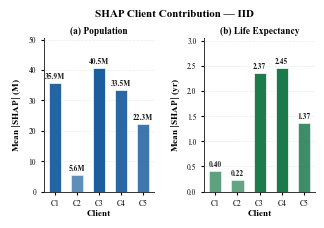

Fig. 7a (IID) saved → figures/fig7a_shap_client_contribution_iid.png


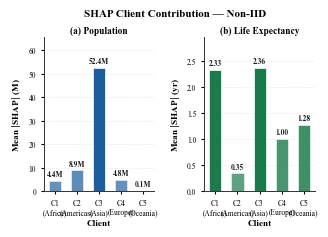

Fig. 7a (Non-IID) saved → figures/fig7a_shap_client_contribution_noniid.png


In [46]:
# ================================================================
# Fig. 7a — SHAP Client Contribution — IID + NON-IID
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

def plot_shap_client_contribution(shap_result, client_labels, label, save_suffix):
    mean_meta_pop_l  = shap_result['mean_meta_pop']
    mean_meta_life_l = shap_result['mean_meta_life']
    n_clients_l = len(mean_meta_pop_l)
    pop_millions = [v / 1e6 for v in mean_meta_pop_l]

    # IEEE single-column width ≈ 3.5 in.
    fig7a, axes7a = plt.subplots(1, 2, figsize=(3.5, 2.0),
                                  facecolor='white',
                                  gridspec_kw={'wspace': 0.45})
    fig7a.suptitle(f'SHAP Client Contribution — {label}', fontsize=8.0, fontweight='bold', y=1.02)

    # LEFT — Population (Millions)
    mx1  = max(pop_millions)
    bars = axes7a[0].bar(np.arange(n_clients_l), pop_millions, width=0.55,
                         color='#1A5E9E', edgecolor='white', linewidth=0.5, zorder=3)
    for bar, v in zip(bars, pop_millions):
        bar.set_alpha(0.65 + 0.35 * (v / mx1))
        axes7a[0].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + mx1 * 0.02,
                       f'{v:.1f}M',
                       ha='center', va='bottom', fontsize=5.4,
                       fontweight='bold', color='#1A1A1A')
    axes7a[0].set_ylabel('Mean $|$SHAP$|$ (M)', fontsize=6.6)
    axes7a[0].set_title('(a) Population', fontsize=6.8, fontweight='bold', pad=3)
    axes7a[0].set_ylim(0, mx1 * 1.25)

    # RIGHT — Life Expectancy
    mx2  = max(mean_meta_life_l)
    bars = axes7a[1].bar(np.arange(n_clients_l), mean_meta_life_l, width=0.55,
                         color='#1A7A4A', edgecolor='white', linewidth=0.5, zorder=3)
    for bar, v in zip(bars, mean_meta_life_l):
        bar.set_alpha(0.65 + 0.35 * (v / mx2))
        axes7a[1].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + mx2 * 0.02,
                       f'{v:.2f}',
                       ha='center', va='bottom', fontsize=5.4,
                       fontweight='bold', color='#1A1A1A')
    axes7a[1].set_ylabel('Mean $|$SHAP$|$ (yr)', fontsize=6.6)
    axes7a[1].set_title('(b) Life Expectancy', fontsize=6.8, fontweight='bold', pad=3)
    axes7a[1].set_ylim(0, mx2 * 1.25)

    # Common settings for both axes
    for ax in axes7a:
        ax.set_xticks(np.arange(n_clients_l))
        ax.set_xticklabels(client_labels, fontsize=5.0 if label == "Non-IID" else 5.6)
        ax.set_xlabel('Client', fontsize=6.6, labelpad=2)
        ax.tick_params(labelsize=5.4, length=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5, zorder=0)
        ax.set_facecolor('white')

    fig7a.tight_layout(rect=[0, 0, 1, 0.93])
    out_path = f"{Config.FIGURES_DIR}fig7a_shap_client_contribution_{save_suffix}.png"
    plt.savefig(out_path, dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Fig. 7a ({label}) saved → {out_path}")


# ── IID: generic client labels ────────────────────────────────────
plot_shap_client_contribution(
    shap_result_iid,
    client_labels=['C1', 'C2', 'C3', 'C4', 'C5'],
    label="IID", save_suffix="iid"
)

# ── Non-IID: continent labels (more informative here) ─────────────
plot_shap_client_contribution(
    shap_result_noniid,
    client_labels=[f'C{i+1}\n({c})' for i, c in enumerate(CONTINENTS)],
    label="Non-IID", save_suffix="noniid"
)

# Cell 21B — Fig. 7B: SHAP Population Beeswarm  Life Expectancy

For IID 

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


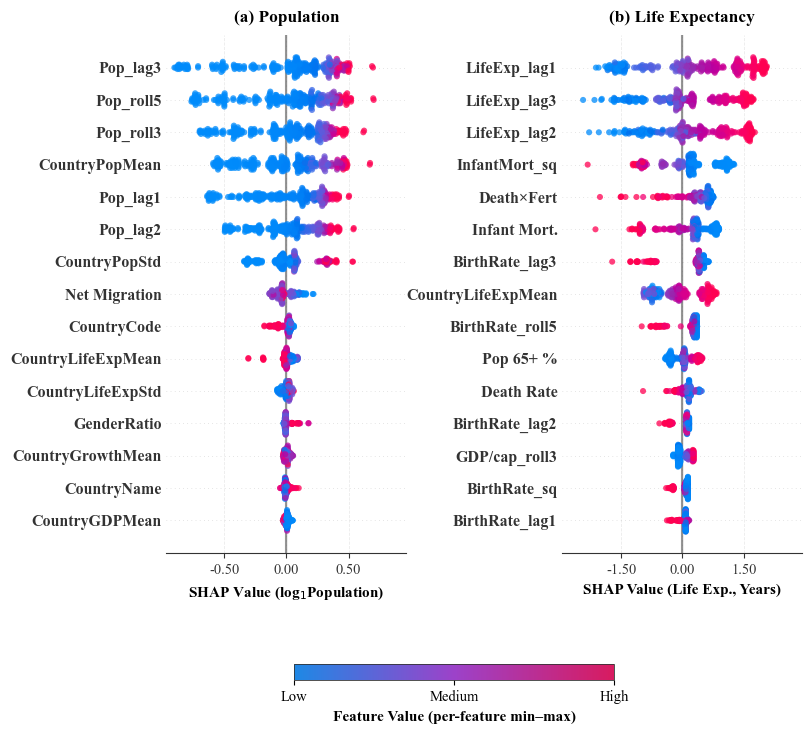

Fig. 7B/7C (IID) saved -> fig7bc_shap_beeswarm_iid.png (600 DPI) and .pdf


In [47]:
# ================================================================
# Cell 21B — Fig. 7B: SHAP Population + Life Expectancy Beeswarm
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import shap

# ------------------------------------------------------------------
# Feature name mapping (shortened for plot readability)
# ------------------------------------------------------------------
name_map_pop = {
    # Lag features
    'Population, total_lag1': 'Pop_lag1',
    'Population, total_lag2': 'Pop_lag2',
    'Population, total_lag3': 'Pop_lag3',
    'Birth rate, crude (per 1,000 people)_lag1': 'BirthRate_lag1',
    'Birth rate, crude (per 1,000 people)_lag2': 'BirthRate_lag2',
    'Birth rate, crude (per 1,000 people)_lag3': 'BirthRate_lag3',
    'GDP per capita (current US$)_lag1': 'GDP/cap_lag1',
    'GDP per capita (current US$)_lag2': 'GDP/cap_lag2',
    'GDP per capita (current US$)_lag3': 'GDP/cap_lag3',
    'Life expectancy at birth, total (years)_lag1': 'LifeExp_lag1',
    'Life expectancy at birth, total (years)_lag2': 'LifeExp_lag2',
    'Life expectancy at birth, total (years)_lag3': 'LifeExp_lag3',
    # Rolling features
    'Population, total_roll3': 'Pop_roll3',
    'Population, total_roll5': 'Pop_roll5',
    'GDP per capita (current US$)_roll3': 'GDP/cap_roll3',
    'GDP per capita (current US$)_roll5': 'GDP/cap_roll5',
    'Birth rate, crude (per 1,000 people)_roll3': 'BirthRate_roll3',
    'Birth rate, crude (per 1,000 people)_roll5': 'BirthRate_roll5',
    # Polynomial features
    'GDP per capita (current US$)_sq': 'GDP/cap_sq',
    'Fertility rate, total (births per woman)_sq': 'Fertility_sq',
    'Birth rate, crude (per 1,000 people)_sq': 'BirthRate_sq',
    'Mortality rate, infant (per 1,000 live births)_sq': 'InfantMort_sq',
    # Interaction features
    'BirthDeathRatio': 'Birth/Death',
    'GDP_Male_Interaction': 'GDP×Male%',
    'HealthProxy': 'HealthProxy',
    'Death_Fertility': 'Death×Fert',
    'GenderRatio': 'GenderRatio',
    # Time features
    'YearsSince2000': 'YrsSince2000',
    'YearsSince2000_sq': 'YrsSince2000²',
    # Country statistics (train only)
    'CountryPopMean': 'CountryPopMean',
    'CountryPopStd': 'CountryPopStd',
    'CountryLifeExpMean': 'CountryLifeExpMean',
    'CountryLifeExpStd': 'CountryLifeExpStd',
    'CountryGDPMean': 'CountryGDPMean',
    'CountryGrowthMean': 'CountryGrowthMean',
    # Encoded identifiers
    'CountryCodeEncoded': 'CountryCode',
    'CountryNameEncoded': 'CountryName',
    # Original base features (sometimes they appear in SHAP)
    'Population, total': 'Population',
    'Life expectancy at birth, total (years)': 'Life Expectancy',
    'Birth rate, crude (per 1,000 people)': 'Birth Rate',
    'Death rate, crude (per 1,000 people)': 'Death Rate',
    'GDP per capita (current US$)': 'GDP/capita',
    'Fertility rate, total (births per woman)': 'Fertility',
    'Mortality rate, infant (per 1,000 live births)': 'Infant Mort.',
    'Population, male (% of total population)': 'Pop Male %',
    'Population, female (% of total population)': 'Pop Female %',
    'Population ages 0-14 (% of total population)': 'Pop 0-14 %',
    'Population ages 65 and above (% of total population)': 'Pop 65+ %',
    'Net migration': 'Net Migration',
    'GDP growth (annual %)': 'GDP Growth',
    'Population growth (annual %)': 'Population Growth',
    'Immunization, DPT (% of children ages 12-23 months)': 'Immunization',
}

# Use same mapping for life expectancy – can be customized if needed
name_map_life = name_map_pop.copy()
# (Optional) Add or override life‑specific mappings here, e.g.:
# name_map_life['SomeLifeSpecificFeature'] = 'LifeFeat'

# ------------------------------------------------------------------
# Pull REAL SHAP data (computed in Cell 95 -> shap_result_iid)
# ------------------------------------------------------------------
feature_names_iid = shap_result_iid['feature_names']
shap_base_pop_iid  = shap_result_iid['shap_base_pop']
shap_base_life_iid = shap_result_iid['shap_base_life']
sample_idx_iid     = shap_result_iid['sample_idx']

X_sample_iid = (
    X_test_global.iloc[sample_idx_iid]
    if hasattr(X_test_global, "iloc") else X_test_global[sample_idx_iid]
)

# ── Select Top-15 features by mean |SHAP| for each target ─────────
top15_pop_idx_i  = np.argsort(shap_result_iid['mean_shap_pop'])[-15:][::-1]
top15_life_idx_i = np.argsort(shap_result_iid['mean_shap_life'])[-15:][::-1]

feature_columns_pop_i  = [feature_names_iid[i] for i in top15_pop_idx_i]
feature_columns_life_i = [feature_names_iid[i] for i in top15_life_idx_i]

X_sample_pop_i  = X_sample_iid[feature_columns_pop_i].values
X_sample_life_i = X_sample_iid[feature_columns_life_i].values

shap_base_pop_i  = shap_base_pop_iid[:, top15_pop_idx_i]
shap_base_life_i = shap_base_life_iid[:, top15_life_idx_i]

# Apply name mapping – any unmapped feature keeps its original name
clean_names_pop_i  = [name_map_pop.get(f, f)  for f in feature_columns_pop_i]
clean_names_life_i = [name_map_life.get(f, f) for f in feature_columns_life_i]

# ------------------------------------------------------------------
# Shared styling
# ------------------------------------------------------------------
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':       12.5,
    'axes.linewidth':  0.8,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

cmap = mcolors.LinearSegmentedColormap.from_list(
    "shap_default", ["#1E88E5", "#9C42C9", "#D81B60"]
)


def draw_beeswarm(ax, shap_values, X_sample, feature_names, xlabel, scale=1.0):
    plt.sca(ax)
    try:
        shap.summary_plot(
            shap_values, X_sample, feature_names=feature_names,
            max_display=15, show=False, color_bar=False, ax=ax,
            plot_size=None, alpha=0.75,
        )
    except TypeError:
        shap.summary_plot(
            shap_values, X_sample, feature_names=feature_names,
            max_display=15, show=False, color_bar=False, alpha=0.75,
        )

    for coll in ax.collections:
        try:
            coll.set_sizes(coll.get_sizes() * 1.2)
        except Exception:
            pass

    p95 = np.percentile(np.abs(shap_values), 95)
    ax.set_xlim(-p95 * 2.0, p95 * 2.0)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/scale:.2f}' if scale == 1 else f'{x/scale:.1f}'))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    ax.set_xlabel(xlabel, fontsize=11, labelpad=5, fontweight='bold')
    ax.axvline(0, color='#888888', linewidth=0.9, zorder=1)
    ax.tick_params(axis='x', labelsize=10.5)

    # Feature-name (y-axis) labels: bold but sized to fit within the
    ax.tick_params(axis='y', labelsize=11.5, length=0)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(11.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.6, zorder=0)
    ax.set_facecolor('white')


# ------------------------------------------------------------------
# Build the merged side-by-side figure — IID (FIXED LAYOUT)
# ------------------------------------------------------------------
fig = plt.figure(figsize=(7.5, 4.9), facecolor='white')
gs = fig.add_gridspec(1, 2, left=0.19, right=0.985, top=0.93, bottom=0.24, wspace=0.65)
axL = fig.add_subplot(gs[0, 0])
axR = fig.add_subplot(gs[0, 1])

draw_beeswarm(
    axL, shap_base_pop_i, X_sample_pop_i, clean_names_pop_i,
    xlabel=r'SHAP Value (log$_1$Population)',   # log‑space, so no "M"
    scale=1,
)
axL.set_title('(a) Population', fontsize=12.5, fontweight='bold', pad=10)

draw_beeswarm(
    axR, shap_base_life_i, X_sample_life_i, clean_names_life_i,
    xlabel='SHAP Value (Life Exp., Years)',
    scale=1,
)
axR.set_title('(b) Life Expectancy', fontsize=12.5, fontweight='bold', pad=10)

# ── HORIZONTAL colorbar on its OWN fixed, centred axis ────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar_ax = fig.add_axes([0.35, 0.07, 0.40, 0.022])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Feature Value (per-feature min\u2013max)', fontsize=11, labelpad=5, fontweight='bold')
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Medium', 'High'], fontsize=10.5)
cbar.outline.set_linewidth(0.6)

# NOTE: plt.tight_layout() and bbox_inches='tight' are intentionally
plt.savefig(f"{Config.FIGURES_DIR}fig7bc_shap_beeswarm_iid.png",
            dpi=600, facecolor='white')
plt.savefig(f"{Config.FIGURES_DIR}fig7bc_shap_beeswarm_iid.pdf",
            facecolor='white')
plt.show()
print("Fig. 7B/7C (IID) saved -> fig7bc_shap_beeswarm_iid.png (600 DPI) and .pdf")

For NON IID

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


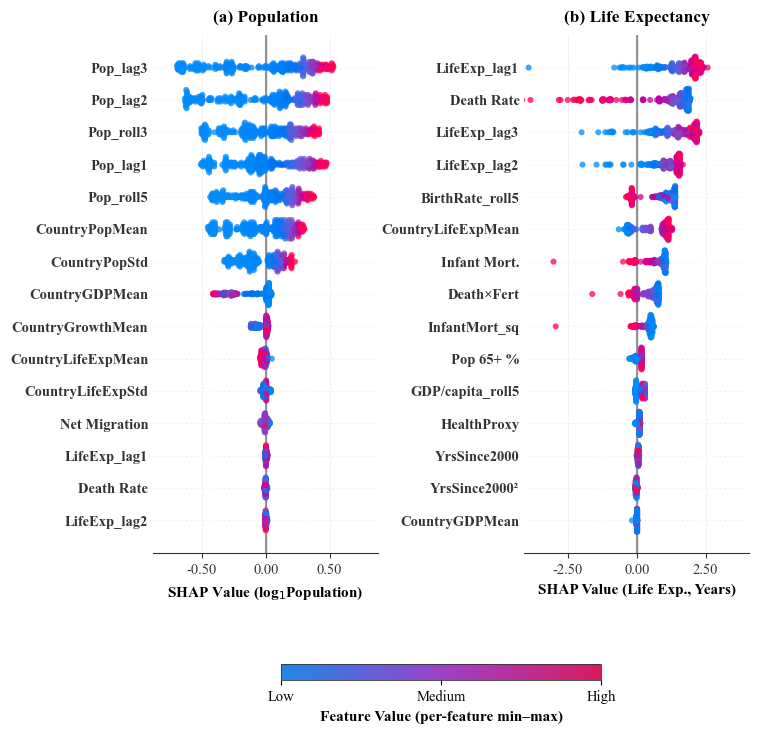

Fig. 7B/7C (Non-IID, single-col) saved -> fig7bc_shap_beeswarm_noniid_singlecol.png (600 DPI) and .pdf


In [48]:
# ================================================================
# Cell 21B — Fig. 7B: SHAP Population + Life Expectancy Beeswarm
# NON-IID (Continent-based), SINGLE-COLUMN OPTIMISED
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import shap

# ------------------------------------------------------------------
# Feature name mapping (same as IID, but defined here for independence)
# ------------------------------------------------------------------
name_map_pop = {
    'Population, total_lag1': 'Pop_lag1',
    'Population, total_lag2': 'Pop_lag2',
    'Population, total_lag3': 'Pop_lag3',
    'Birth rate, crude (per 1,000 people)_lag1': 'BirthRate_lag1',
    'Birth rate, crude (per 1,000 people)_lag2': 'BirthRate_lag2',
    'Birth rate, crude (per 1,000 people)_lag3': 'BirthRate_lag3',
    'GDP per capita (current US$)_lag1': 'GDP/cap_lag1',
    'GDP per capita (current US$)_lag2': 'GDP/cap_lag2',
    'GDP per capita (current US$)_lag3': 'GDP/cap_lag3',
    'Life expectancy at birth, total (years)_lag1': 'LifeExp_lag1',
    'Life expectancy at birth, total (years)_lag2': 'LifeExp_lag2',
    'Life expectancy at birth, total (years)_lag3': 'LifeExp_lag3',
    'Population, total_roll3': 'Pop_roll3',
    'Population, total_roll5': 'Pop_roll5',
    'GDP per capita (current US$)_roll3': 'GDP/cap_roll3',
    'GDP per capita (current US$)_roll5': 'GDP/capita_roll5',   # already updated
    'Birth rate, crude (per 1,000 people)_roll3': 'BirthRate_roll3',
    'Birth rate, crude (per 1,000 people)_roll5': 'BirthRate_roll5',
    'GDP per capita (current US$)_sq': 'GDP/cap_sq',
    'Fertility rate, total (births per woman)_sq': 'Fertility_sq',
    'Birth rate, crude (per 1,000 people)_sq': 'BirthRate (sq)',
    'Mortality rate, infant (per 1,000 live births)_sq': 'InfantMort_sq',
    'BirthDeathRatio': 'Birth/Death',
    'GDP_Male_Interaction': 'GDP×Male%',
    'HealthProxy': 'HealthProxy',
    'Death_Fertility': 'Death×Fert',
    'GenderRatio': 'GenderRatio',
    'YearsSince2000': 'YrsSince2000',
    'YearsSince2000_sq': 'YrsSince2000²',
    'CountryPopMean': 'CountryPopMean',
    'CountryPopStd': 'CountryPopStd',
    'CountryLifeExpMean': 'CountryLifeExpMean',
    'CountryLifeExpStd': 'CountryLifeExpStd',
    'CountryGDPMean': 'CountryGDPMean',
    'CountryGrowthMean': 'CountryGrowthMean',
    'CountryCodeEncoded': 'CountryCode',
    'CountryNameEncoded': 'CountryName',
    'Population, total': 'Population',
    'Life expectancy at birth, total (years)': 'Life Expectancy',
    'Birth rate, crude (per 1,000 people)': 'Birth Rate',
    'Death rate, crude (per 1,000 people)': 'Death Rate',
    'GDP per capita (current US$)': 'GDP/capita',
    'Fertility rate, total (births per woman)': 'Fertility',
    'Mortality rate, infant (per 1,000 live births)': 'Infant Mort.',
    'Population, male (% of total population)': 'Pop Male %',
    'Population, female (% of total population)': 'Pop Female %',
    'Population ages 0-14 (% of total population)': 'Pop 0-14 %',
    'Population ages 65 and above (% of total population)': 'Pop 65+ %',
    'Net migration': 'Net Migration',
    'GDP growth (annual %)': 'GDP Growth',
    'Population growth (annual %)': 'Population Growth',
    'Immunization, DPT (% of children ages 12-23 months)': 'Immunization',
}
name_map_life = name_map_pop.copy()

# ------------------------------------------------------------------
# Pull REAL SHAP data (Non-IID)
# ------------------------------------------------------------------
feature_names_noniid = shap_result_noniid['feature_names']
shap_base_pop_noniid  = shap_result_noniid['shap_base_pop']
shap_base_life_noniid = shap_result_noniid['shap_base_life']
sample_idx_noniid     = shap_result_noniid['sample_idx']

X_sample_noniid = (
    X_test_global.iloc[sample_idx_noniid]
    if hasattr(X_test_global, "iloc") else X_test_global[sample_idx_noniid]
)

top15_pop_idx_n  = np.argsort(shap_result_noniid['mean_shap_pop'])[-15:][::-1]
top15_life_idx_n = np.argsort(shap_result_noniid['mean_shap_life'])[-15:][::-1]

feature_columns_pop_n  = [feature_names_noniid[i] for i in top15_pop_idx_n]
feature_columns_life_n = [feature_names_noniid[i] for i in top15_life_idx_n]

X_sample_pop_n  = X_sample_noniid[feature_columns_pop_n].values
X_sample_life_n = X_sample_noniid[feature_columns_life_n].values

shap_base_pop_n  = shap_base_pop_noniid[:, top15_pop_idx_n]
shap_base_life_n = shap_base_life_noniid[:, top15_life_idx_n]

def truncate_label(name, max_len=22):
    return name if len(name) <= max_len else name[:max_len - 1] + '…'

clean_names_pop_n  = [truncate_label(name_map_pop.get(f, f))  for f in feature_columns_pop_n]
clean_names_life_n = [truncate_label(name_map_life.get(f, f)) for f in feature_columns_life_n]

# ------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':       12.5,
    'axes.linewidth':  0.8,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

cmap = mcolors.LinearSegmentedColormap.from_list(
    "shap_default", ["#1E88E5", "#9C42C9", "#D81B60"]
)

def draw_beeswarm_optimized(ax, shap_values, X_sample, feature_names, xlabel, scale=1.0):
    plt.sca(ax)
    try:
        shap.summary_plot(
            shap_values, X_sample, feature_names=feature_names,
            max_display=15, show=False, color_bar=False, ax=ax,
            plot_size=None, alpha=0.75,
        )
    except TypeError:
        shap.summary_plot(
            shap_values, X_sample, feature_names=feature_names,
            max_display=15, show=False, color_bar=False, alpha=0.75,
        )

    for coll in ax.collections:
        try:
            coll.set_sizes(coll.get_sizes() * 1.2)
        except Exception:
            pass

    p95 = np.percentile(np.abs(shap_values), 95)
    ax.set_xlim(-p95 * 2.0, p95 * 2.0)

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/scale:.2f}' if scale == 1 else f'{x/scale:.1f}')
    )
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    ax.set_xlabel(xlabel, fontsize=11, labelpad=5, fontweight='bold')
    ax.axvline(0, color='#888888', linewidth=0.9, zorder=1)
    ax.tick_params(axis='x', labelsize=10.5)
    ax.tick_params(axis='y', labelsize=10.5, length=0)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(10.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.6, zorder=0)
    ax.set_facecolor('white')

fig = plt.figure(figsize=(7.5, 4.9), facecolor='white')
gs = fig.add_gridspec(1, 2, left=0.24, right=0.985, top=0.93, bottom=0.24, wspace=0.65)
axL = fig.add_subplot(gs[0, 0])
axR = fig.add_subplot(gs[0, 1])

draw_beeswarm_optimized(
    axL, shap_base_pop_n, X_sample_pop_n, clean_names_pop_n,
    xlabel=r'SHAP Value (log$_1$Population)',
    scale=1,
)
axL.set_title('(a) Population', fontsize=12.5, fontweight='bold', pad=10)

draw_beeswarm_optimized(
    axR, shap_base_life_n, X_sample_life_n, clean_names_life_n,
    xlabel='SHAP Value (Life Exp., Years)',
    scale=1,
)
axR.set_title('(b) Life Expectancy', fontsize=12.5, fontweight='bold', pad=10)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar_ax = fig.add_axes([0.40, 0.07, 0.40, 0.022])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Feature Value (per-feature min\u2013max)', fontsize=11, labelpad=5, fontweight='bold')
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Medium', 'High'], fontsize=10.5)
cbar.outline.set_linewidth(0.6)

plt.savefig(f"{Config.FIGURES_DIR}fig7bc_shap_beeswarm_noniid_singlecol.png",
            dpi=600, facecolor='white')
plt.savefig(f"{Config.FIGURES_DIR}fig7bc_shap_beeswarm_noniid_singlecol.pdf",
            facecolor='white')
plt.show()
print("Fig. 7B/7C (Non-IID, single-col) saved -> fig7bc_shap_beeswarm_noniid_singlecol.png (600 DPI) and .pdf")

# Cell 21C — Fig. 7C: SHAP Bar Comparison

Fig. 7D (IID) saved → figures/fig7d_shap_bar_comparison_iid.png


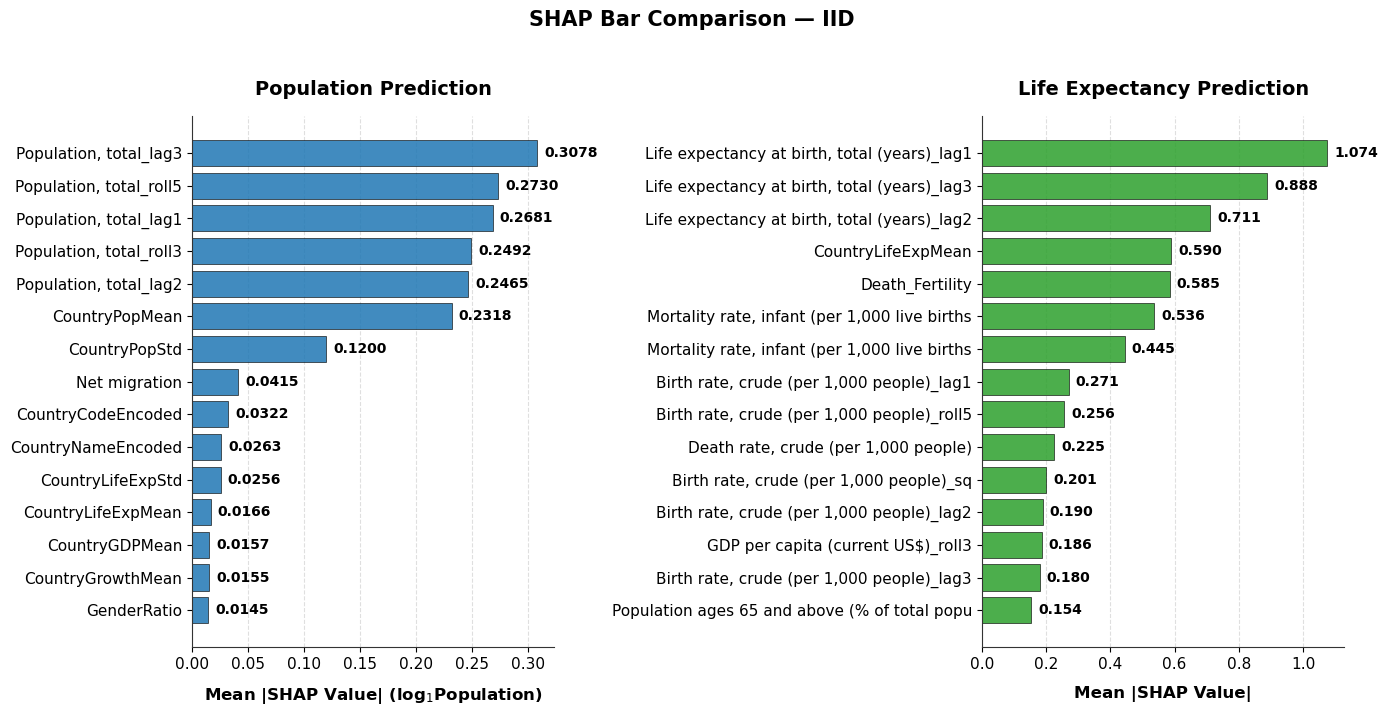

TABLE III (IID) saved → outputs/table3_shap_features_iid.csv
Fig. 7D (Non-IID) saved → figures/fig7d_shap_bar_comparison_noniid.png


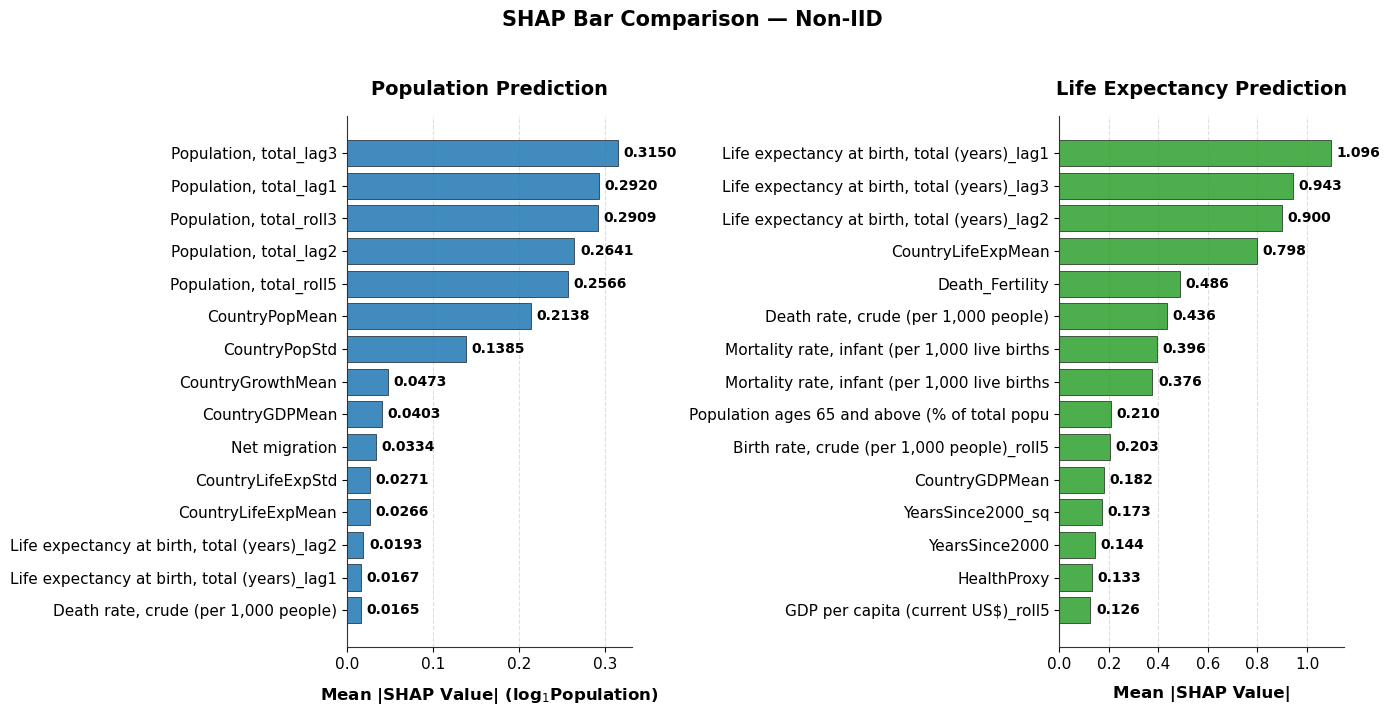

TABLE III (Non-IID) saved → outputs/table3_shap_features_noniid.csv


In [49]:
# ================================================================
# Cell 21D — Fig. 7D: SHAP Bar Comparison + TABLE III CSV — IID + NON-IID
# reflect this consistently.
# ================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'sans-serif'
})


def format_annotation(val, is_pop):
    #  Population SHAP is on the log1p scale — no /1e6 conversion
    return f"{val:.4f}" if is_pop else f"{val:.3f}"


def plot_shap_bar_and_table(shap_result, label, save_suffix):
    mean_shap_pop_l  = shap_result['mean_shap_pop']
    mean_shap_life_l = shap_result['mean_shap_life']
    feature_columns_l = shap_result['feature_names']

    top15_pop_idx  = np.argsort(mean_shap_pop_l)[-15:][::-1]
    top15_life_idx = np.argsort(mean_shap_life_l)[-15:][::-1]

    fig7d, axes7d = plt.subplots(1, 2, figsize=(14, 7), facecolor='white')
    fig7d.suptitle(f'SHAP Bar Comparison — {label}', fontsize=15, fontweight='bold', y=1.02)

    for i, (ax, idx, vals, title, color) in enumerate(zip(
        axes7d,
        [top15_pop_idx, top15_life_idx],
        [mean_shap_pop_l, mean_shap_life_l],
        ['Population Prediction', 'Life Expectancy Prediction'],
        ['#1f77b4', '#2ca02c']
    )):
        ax.set_facecolor('white')
        is_pop = (i == 0)

        bars = ax.barh(range(15), vals[idx], color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(15))
        ax.set_yticklabels([feature_columns_l[j][:45] for j in idx])
        ax.invert_yaxis()

        # label — log1p scale for population, not "Millions"
        ax.set_xlabel(
            'Mean |SHAP Value| (log$_1$Population)' if is_pop else 'Mean |SHAP Value|',
            fontweight='bold', labelpad=10
        )
        ax.set_title(title, fontweight='bold', pad=15)
        ax.grid(axis='x', alpha=0.4, linestyle='--')
        ax.set_axisbelow(True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        max_val = max(vals[idx])
        offset = max_val * 0.02
        for bar in bars:
            width = bar.get_width()
            ax.text(width + offset, bar.get_y() + bar.get_height()/2, format_annotation(width, is_pop),
                    va='center', fontsize=10, fontweight='bold')

        #  the old "/1e6" x-tick relabeling block for population.
        # Population SHAP is log1p-scale, so raw tick values are already
        # correct and should NOT be divided by 1e6.

    plt.tight_layout()

    try:
        save_path = f"{Config.FIGURES_DIR}fig7d_shap_bar_comparison_{save_suffix}.png"
        plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Fig. 7D ({label}) saved → {save_path}")
    except AttributeError:
        save_path = f"fig7d_shap_bar_comparison_{save_suffix}.png"
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Fig. 7D ({label}) saved to current directory.")
    plt.show()

    # ── TABLE III: Top 10 SHAP Features (CSV export) ────────────
    top10_pop_idx  = np.argsort(mean_shap_pop_l)[-10:][::-1]
    top10_life_idx = np.argsort(mean_shap_life_l)[-10:][::-1]

    table3_l = pd.DataFrame({
        'Rank': range(1, 11),
        'Pop Feature': [feature_columns_l[i][:50] for i in top10_pop_idx],
        'Pop SHAP (log1p scale)': [f"{mean_shap_pop_l[i]:.4f}" for i in top10_pop_idx],  # label clarified
        'Life Feature': [feature_columns_l[i][:50] for i in top10_life_idx],
        'Life SHAP': [f"{mean_shap_life_l[i]:.4f}" for i in top10_life_idx],
    })

    try:
        csv_path = f"{Config.OUTPUT_DIR}table3_shap_features_{save_suffix}.csv"
        table3_l.to_csv(csv_path, index=False)
        print(f"TABLE III ({label}) saved → {csv_path}")
    except (AttributeError, NameError):
        csv_path = f"table3_shap_features_{save_suffix}.csv"
        table3_l.to_csv(csv_path, index=False)
        print(f"TABLE III ({label}) saved to current directory: {csv_path}")

    return table3_l


# ── Run for IID ──────────────────────────────────────────────────
table3_iid = plot_shap_bar_and_table(shap_result_iid, label="IID", save_suffix="iid")

# ── Run for Non-IID ──────────────────────────────────────────────
table3_noniid = plot_shap_bar_and_table(shap_result_noniid, label="Non-IID", save_suffix="noniid")

# Cell 21.5: Fig. 8 — Actual vs Predicted

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


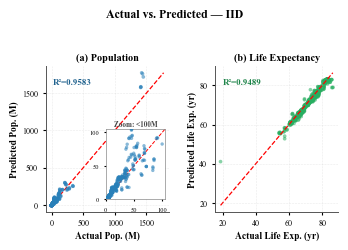

Fig. 8 (IID, linear scale + inset zoom) saved → figures/fig8_actual_vs_predicted_iid.png
  Pop  R² = 0.9583
  Life R² = 0.9489


meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


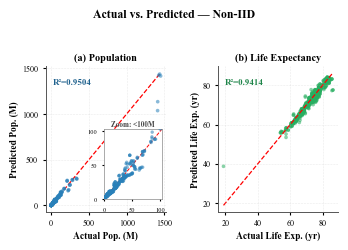

Fig. 8 (Non-IID, linear scale + inset zoom) saved → figures/fig8_actual_vs_predicted_noniid.png
  Pop  R² = 0.9504
  Life R² = 0.9414


In [50]:
# ================================================================
# Cell 21.5 — Fig. 8: Actual vs Predicted — IID + NON-IID
# ================================================================
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import joblib   # for loading models if needed

plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':       7.2,
    'axes.linewidth':  0.7,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

# ── Auto‑load FedStack models if not already in memory ──────────
if 'server_st' not in globals():
    server_st = joblib.load(f"{Config.MODELS_DIR}server_stacking_only.pkl")
    clients_st = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only.pkl")
    print("  ↺ Loaded IID FedStack models from disk.")

if 'server_st_noniid' not in globals():
    server_st_noniid = joblib.load(f"{Config.MODELS_DIR}server_stacking_only_noniid.pkl")
    clients_st_noniid = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only_noniid.pkl")
    print("  ↺ Loaded Non‑IID FedStack models from disk.")


def plot_actual_vs_predicted(server_l, clients_l, label, save_suffix):
    preds_test  = server_l.predict(clients_l, X_test_global)
    y_pred_pop  = preds_test['pop']
    y_pred_life = preds_test['life']
    y_true_pop  = y_test_global[Config.TARGET_COLUMNS[0]].values
    y_true_life = y_test_global[Config.TARGET_COLUMNS[1]].values

    fig8, axes8 = plt.subplots(1, 2, figsize=(3.5, 2.3), facecolor='white')
    fig8.suptitle(f'Actual vs. Predicted — {label}', fontsize=8.5, fontweight='bold', y=1.05)

    # ── Panel A: Population (left) — linear scale ──
    ax = axes8[0]
    ax.set_facecolor('white')
    pop_true_m = y_true_pop / 1e6
    pop_pred_m = y_pred_pop / 1e6
    ax.scatter(pop_true_m, pop_pred_m, alpha=0.55, s=7, color='#2980b9',
               edgecolors='none', zorder=3)
    min_val = min(pop_true_m.min(), pop_pred_m.min())
    max_val = max(pop_true_m.max(), pop_pred_m.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=0.9, zorder=2)

    r2_p = r2_score(y_true_pop, y_pred_pop)
    ax.text(0.06, 0.92, f'R\u00b2={r2_p:.4f}', transform=ax.transAxes, fontsize=6.4,
            fontweight='bold', color='#1f618d', verticalalignment='top')
    ax.set_xlabel('Actual Pop. (M)', fontsize=6.8, labelpad=2)
    ax.set_ylabel('Predicted Pop. (M)', fontsize=6.8, labelpad=2)
    ax.set_title('(a) Population', fontweight='bold', fontsize=7.4, pad=4)
    ax.tick_params(labelsize=5.8, length=2)
    ax.locator_params(axis='both', nbins=4)
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')

    # ── Inset: zoom into the small-population cluster (<100M) ──
    axins = inset_axes(ax, width="48%", height="48%", loc='lower right',
                        bbox_to_anchor=(0.0, 0.06, 1, 1), bbox_transform=ax.transAxes)
    zoom_mask = pop_true_m < 100
    axins.scatter(pop_true_m[zoom_mask], pop_pred_m[zoom_mask],
                  alpha=0.55, s=6, color='#2980b9', edgecolors='none', zorder=3)
    zmax = max(pop_true_m[zoom_mask].max(), pop_pred_m[zoom_mask].max())
    axins.plot([0, zmax], [0, zmax], 'r--', linewidth=0.7, zorder=2)
    axins.set_xlim(0, zmax)
    axins.set_ylim(0, zmax)
    axins.tick_params(labelsize=4.6, length=1.5)
    axins.locator_params(axis='both', nbins=3)
    axins.set_facecolor('white')
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color('#888888')
    axins.set_title('Zoom: <100M', fontsize=5.2, pad=2, color='#444444')

    # ── Panel B: Life Expectancy (right) ───────────────────────────
    ax = axes8[1]
    ax.set_facecolor('white')
    ax.scatter(y_true_life, y_pred_life, alpha=0.55, s=7,
               color='#27ae60', edgecolors='none')
    min_val_l = min(y_true_life.min(), y_pred_life.min())
    max_val_l = max(y_true_life.max(), y_pred_life.max())
    ax.plot([min_val_l, max_val_l], [min_val_l, max_val_l], 'r--', linewidth=0.9, zorder=1)

    r2_l = r2_score(y_true_life, y_pred_life)
    ax.text(0.06, 0.92, f'R\u00b2={r2_l:.4f}', transform=ax.transAxes, fontsize=6.4,
            fontweight='bold', color='#1e8449', verticalalignment='top')
    ax.set_xlabel('Actual Life Exp. (yr)', fontsize=6.8, labelpad=2)
    ax.set_ylabel('Predicted Life Exp. (yr)', fontsize=6.8, labelpad=2)
    ax.set_title('(b) Life Expectancy', fontweight='bold', fontsize=7.4, pad=4)
    ax.tick_params(labelsize=5.8, length=2)
    ax.locator_params(axis='both', nbins=5)
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')

    plt.tight_layout(w_pad=1.8)
    out_png = f"{Config.FIGURES_DIR}fig8_actual_vs_predicted_{save_suffix}.png"
    out_pdf = f"{Config.FIGURES_DIR}fig8_actual_vs_predicted_{save_suffix}.pdf"
    plt.savefig(out_png, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"Fig. 8 ({label}, linear scale + inset zoom) saved → {out_png}")
    print(f"  Pop  R² = {r2_p:.4f}")
    print(f"  Life R² = {r2_l:.4f}")

    return r2_p, r2_l


# ── Run for IID ──────────────────────────────────────────────────
r2_pop_iid, r2_life_iid = plot_actual_vs_predicted(
    server_st, clients_st, label="IID", save_suffix="iid"
)

# ── Run for Non-IID ──────────────────────────────────────────────
r2_pop_noniid, r2_life_noniid = plot_actual_vs_predicted(
    server_st_noniid, clients_st_noniid, label="Non-IID", save_suffix="noniid"
)

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


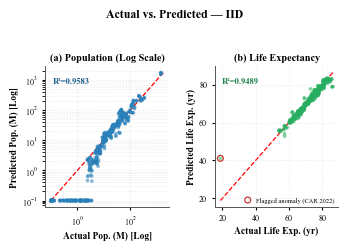

Fig. 8 (IID, log-scale Pop + transparent Life Exp.) saved → figures/fig8_actual_vs_predicted_iid.png
  Pop  R² = 0.9583
  Life R² = 0.9489
  Note: 1 flagged anomaly point(s) shown (not hidden) — included in R² above, per Sec. IV-H.


meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


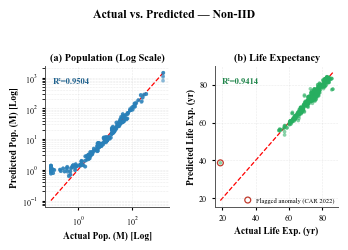

Fig. 8 (Non-IID, log-scale Pop + transparent Life Exp.) saved → figures/fig8_actual_vs_predicted_noniid.png
  Pop  R² = 0.9504
  Life R² = 0.9414
  Note: 1 flagged anomaly point(s) shown (not hidden) — included in R² above, per Sec. IV-H.


In [51]:
# ================================================================
# Cell 21.5 — Fig. 8: Actual vs Predicted — IID + NON-IID 
# Log-log scale for population; anomaly flagging;
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import joblib   # to load models if missing

plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':       7.2,
    'axes.linewidth':  0.7,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

# ── Auto‑load FedStack models if not already in memory ──────────
if 'server_st' not in globals():
    server_st = joblib.load(f"{Config.MODELS_DIR}server_stacking_only.pkl")
    clients_st = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only.pkl")
    print("  ↺ Loaded IID FedStack models from disk.")

if 'server_st_noniid' not in globals():
    server_st_noniid = joblib.load(f"{Config.MODELS_DIR}server_stacking_only_noniid.pkl")
    clients_st_noniid = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only_noniid.pkl")
    print("  ↺ Loaded Non‑IID FedStack models from disk.")


def plot_actual_vs_predicted(server_l, clients_l, label, save_suffix):
    preds_test  = server_l.predict(clients_l, X_test_global)
    y_pred_pop  = preds_test['pop']
    y_pred_life = preds_test['life']
    y_true_pop  = y_test_global[Config.TARGET_COLUMNS[0]].values
    y_true_life = y_test_global[Config.TARGET_COLUMNS[1]].values

    fig8, axes8 = plt.subplots(1, 2, figsize=(3.5, 2.3), facecolor='white')
    fig8.suptitle(f'Actual vs. Predicted — {label}', fontsize=8.5, fontweight='bold', y=1.05)

    # ── Panel A: Population (left) — Log-Log Scale ──
    ax = axes8[0]
    ax.set_facecolor('white')
    pop_true_m = y_true_pop / 1e6
    pop_pred_m = y_pred_pop / 1e6

    # Clip both true and predicted to a small positive floor so log10
    # never sees 0 or negative values (previously only predictions
    # were clipped; true values could still be 0 for micro-states).
    floor = 0.1
    pop_true_m_plot = np.clip(pop_true_m, floor, None)
    pop_pred_m_plot = np.clip(pop_pred_m, floor, None)

    ax.scatter(pop_true_m_plot, pop_pred_m_plot, alpha=0.55, s=7, color='#2980b9',
               edgecolors='none', zorder=3)

    ax.set_xscale('log')
    ax.set_yscale('log')

    min_val = min(pop_true_m_plot.min(), pop_pred_m_plot.min())
    max_val = max(pop_true_m_plot.max(), pop_pred_m_plot.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=0.9, zorder=2)

    # R² computed on the FULL, unclipped, original-scale data —
    # matches Table V exactly, independent of how the plot is drawn.
    r2_p = r2_score(y_true_pop, y_pred_pop)
    ax.text(0.06, 0.92, f'R\u00b2={r2_p:.4f}', transform=ax.transAxes, fontsize=6.2,
            fontweight='bold', color='#1f618d', verticalalignment='top')
    ax.set_xlabel('Actual Pop. (M) [Log]', fontsize=6.8, labelpad=2)
    ax.set_ylabel('Predicted Pop. (M) [Log]', fontsize=6.8, labelpad=2)
    ax.set_title('(a) Population (Log Scale)', fontweight='bold', fontsize=7.4, pad=4)
    ax.tick_params(labelsize=5.8, length=2)
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.4, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')

    # ── Panel B: Life Expectancy (right) — ALL points shown ──
    ax = axes8[1]
    ax.set_facecolor('white')

    ax.scatter(y_true_life, y_pred_life, alpha=0.55, s=7,
               color='#27ae60', edgecolors='none', zorder=3)

    min_val_l = min(y_true_life.min(), y_pred_life.min())
    max_val_l = max(y_true_life.max(), y_pred_life.max())
    ax.plot([min_val_l, max_val_l], [min_val_l, max_val_l], 'r--', linewidth=0.9, zorder=1)

    # Flag the known data-quality anomaly transparently instead of
    # hiding it (see Sec. IV-H: Central African Republic, 2022,
    # reported 18.82 yr vs. FedStack prediction ~41.10 yr).
    anomaly_mask = y_true_life < 30
    if anomaly_mask.any():
        ax.scatter(y_true_life[anomaly_mask], y_pred_life[anomaly_mask],
                   s=18, facecolors='none', edgecolors='#c0392b',
                   linewidths=0.9, zorder=4, label='Flagged anomaly (CAR 2022)')
        ax.legend(fontsize=4.6, loc='lower right', frameon=False,
                  handletextpad=0.3, borderaxespad=0.2)

    r2_l = r2_score(y_true_life, y_pred_life)
    ax.text(0.06, 0.92, f'R\u00b2={r2_l:.4f}', transform=ax.transAxes, fontsize=6.2,
            fontweight='bold', color='#1e8449', verticalalignment='top')
    ax.set_xlabel('Actual Life Exp. (yr)', fontsize=6.8, labelpad=2)
    ax.set_ylabel('Predicted Life Exp. (yr)', fontsize=6.8, labelpad=2)
    ax.set_title('(b) Life Expectancy', fontweight='bold', fontsize=7.4, pad=4)
    ax.tick_params(labelsize=5.8, length=2)
    ax.locator_params(axis='both', nbins=5)
    ax.grid(alpha=0.25, linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')

    plt.tight_layout(w_pad=1.8)
    out_png = f"{Config.FIGURES_DIR}fig8_actual_vs_predicted_{save_suffix}.png"
    out_pdf = f"{Config.FIGURES_DIR}fig8_actual_vs_predicted_{save_suffix}.pdf"
    plt.savefig(out_png, dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"Fig. 8 ({label}, log-scale Pop + transparent Life Exp.) saved → {out_png}")
    print(f"  Pop  R² = {r2_p:.4f}")
    print(f"  Life R² = {r2_l:.4f}")
    if anomaly_mask.any():
        print(f"  Note: {anomaly_mask.sum()} flagged anomaly point(s) shown "
              f"(not hidden) — included in R² above, per Sec. IV-H.")

    return r2_p, r2_l


# ── Run for IID ──────────────────────────────────────────────────
r2_pop_iid, r2_life_iid = plot_actual_vs_predicted(
    server_st, clients_st, label="IID", save_suffix="iid"
)

# ── Run for Non-IID ──────────────────────────────────────────────
r2_pop_noniid, r2_life_noniid = plot_actual_vs_predicted(
    server_st_noniid, clients_st_noniid, label="Non-IID", save_suffix="noniid"
)

# Cell 22 — Final Prediction Visualization

meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


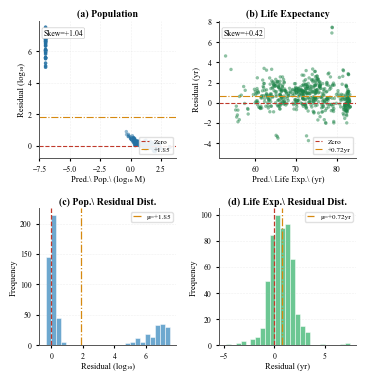

Fig. 9 (IID) saved → figures/fig9_residual_analysis_iid.png (900 DPI PNG) and figures/fig9_residual_analysis_iid.pdf (vector PDF)
  >> For LaTeX, use the .pdf file for guaranteed sharpness. <<
  Pop  residual mean = +1.851, skew = +1.041
  Life residual mean = +0.718yr, skew = +0.425


meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


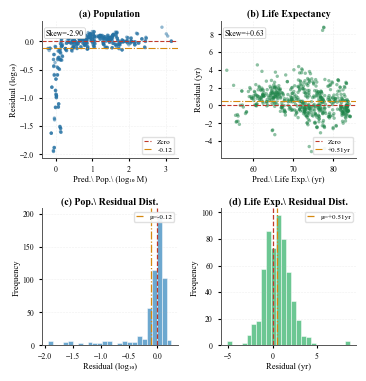

Fig. 9 (Non-IID) saved → figures/fig9_residual_analysis_noniid.png (900 DPI PNG) and figures/fig9_residual_analysis_noniid.pdf (vector PDF)
  >> For LaTeX, use the .pdf file for guaranteed sharpness. <<
  Pop  residual mean = -0.123, skew = -2.902
  Life residual mean = +0.511yr, skew = +0.631


In [52]:
# ==============================================================================
# Cell 22 — Fig. 9: Residual Analysis — IID + NON-IID 
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import os
import joblib

plt.close('all')
plt.style.use('default')

plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'DejaVu Serif'],
    'font.size':       7,
    'axes.linewidth':  0.7,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

ZERO_C = '#C0392B'
MEAN_C = '#D68910'

# ── Auto‑load FedStack models if missing ───────────────────────
if 'server_st' not in globals():
    server_st = joblib.load(f"{Config.MODELS_DIR}server_stacking_only.pkl")
    clients_st = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only.pkl")
    print("  ↺ Loaded IID FedStack models from disk.")

if 'server_st_noniid' not in globals():
    server_st_noniid = joblib.load(f"{Config.MODELS_DIR}server_stacking_only_noniid.pkl")
    clients_st_noniid = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only_noniid.pkl")
    print("  ↺ Loaded Non‑IID FedStack models from disk.")


def plot_residual_analysis(server_l, clients_l, label, save_suffix):
    preds_test  = server_l.predict(clients_l, X_test_global)
    pred_pop_f  = preds_test['pop']
    pred_life_f = preds_test['life']
    y_true_pop  = y_test_global[Config.TARGET_COLUMNS[0]].values
    y_true_life = y_test_global[Config.TARGET_COLUMNS[1]].values

    # Population: residual in log10-space
    pred_pop_f_clipped = np.clip(pred_pop_f, 0.1, None)
    res_pop = np.log10(y_true_pop / 1e6) - np.log10(pred_pop_f_clipped / 1e6)
    pred_pop_plot = np.log10(pred_pop_f_clipped / 1e6)

    # Life Expectancy: exclude flagged anomaly (CAR 2022)
    clean_mask = y_true_life > 30
    clean_pred_life = pred_life_f[clean_mask]
    clean_true_life = y_true_life[clean_mask]
    res_life = clean_true_life - clean_pred_life

    mean_pop  = np.mean(res_pop)
    skew_pop  = scipy.stats.skew(res_pop)
    mean_life = np.mean(res_life)
    skew_life = scipy.stats.skew(res_life)

    fig9, axes = plt.subplots(2, 2, figsize=(3.6, 3.75), facecolor='white')

    # (a) Population: residuals vs predicted
    ax = axes[0, 0]
    ax.set_facecolor('white')
    ax.scatter(pred_pop_plot, res_pop, alpha=0.5, s=6, color='#2471A3', edgecolors='none')
    ax.axhline(0, color=ZERO_C, lw=0.8, ls='--', zorder=2, label='Zero')
    ax.axhline(mean_pop, color=MEAN_C, lw=0.8, ls='-.', zorder=2, label=f'{mean_pop:+.2f}')
    ax.set_xlabel('Pred.\ Pop.\ (log\u2081\u2080 M)', fontsize=6.2, labelpad=1.5)
    ax.set_ylabel('Residual (log\u2081\u2080)', fontsize=6.2, labelpad=1.5)
    ax.set_title('(a) Population', fontsize=7.2, fontweight='bold', pad=3)
    ax.text(0.03, 0.94, f'Skew={skew_pop:+.2f}', transform=ax.transAxes,
            fontsize=5.6, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='#cccccc', lw=0.5))
    ax.legend(fontsize=5.2, loc='lower right', frameon=True, edgecolor='#dddddd',
              framealpha=0.9, handlelength=1.1, borderpad=0.25, labelspacing=0.25)
    ax.tick_params(labelsize=5.6, length=2.0)
    ax.grid(alpha=0.2, linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555'); ax.spines['bottom'].set_color('#555555')

    # (b) Life Expectancy: residuals vs predicted
    ax = axes[0, 1]
    ax.set_facecolor('white')
    ax.scatter(clean_pred_life, res_life, alpha=0.5, s=6, color='#1E8449', edgecolors='none')
    ax.axhline(0, color=ZERO_C, lw=0.8, ls='--', zorder=2, label='Zero')
    ax.axhline(mean_life, color=MEAN_C, lw=0.8, ls='-.', zorder=2, label=f'{mean_life:+.2f}yr')
    ax.set_xlabel('Pred.\ Life Exp.\ (yr)', fontsize=6.2, labelpad=1.5)
    ax.set_ylabel('Residual (yr)', fontsize=6.2, labelpad=1.5)
    ax.set_title('(b) Life Expectancy', fontsize=7.2, fontweight='bold', pad=3)
    ax.text(0.03, 0.94, f'Skew={skew_life:+.2f}', transform=ax.transAxes,
            fontsize=5.6, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='#cccccc', lw=0.5))
    ax.legend(fontsize=5.2, loc='lower right', frameon=True, edgecolor='#dddddd',
              framealpha=0.9, handlelength=1.1, borderpad=0.25, labelspacing=0.25)
    ax.tick_params(labelsize=5.6, length=2.0)
    ax.grid(alpha=0.2, linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555'); ax.spines['bottom'].set_color('#555555')

    # (c) Population residual distribution
    ax = axes[1, 0]
    ax.set_facecolor('white')
    ax.hist(res_pop, bins=25, color='#5499C7', alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color=ZERO_C, lw=0.9, ls='--', zorder=2)
    ax.axvline(mean_pop, color=MEAN_C, lw=0.9, ls='-.', zorder=2, label=f'\u03bc={mean_pop:+.2f}')
    ax.set_xlabel('Residual (log\u2081\u2080)', fontsize=6.2, labelpad=1.5)
    ax.set_ylabel('Frequency', fontsize=6.2, labelpad=1.5)
    ax.set_title('(c) Pop.\ Residual Dist.', fontsize=7.2, fontweight='bold', pad=3)
    ax.legend(fontsize=5.2, loc='upper right', frameon=True, edgecolor='#dddddd',
              framealpha=0.9, handlelength=1.1, borderpad=0.25, labelspacing=0.25)
    ax.tick_params(labelsize=5.6, length=2.0)
    ax.grid(alpha=0.2, axis='y', linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555'); ax.spines['bottom'].set_color('#555555')

    # (d) Life Expectancy residual distribution
    ax = axes[1, 1]
    ax.set_facecolor('white')
    ax.hist(res_life, bins=25, color='#52BE80', alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color=ZERO_C, lw=0.9, ls='--', zorder=2)
    ax.axvline(mean_life, color=MEAN_C, lw=0.9, ls='-.', zorder=2, label=f'\u03bc={mean_life:+.2f}yr')
    ax.set_xlabel('Residual (yr)', fontsize=6.2, labelpad=1.5)
    ax.set_ylabel('Frequency', fontsize=6.2, labelpad=1.5)
    ax.set_title('(d) Life Exp.\ Residual Dist.', fontsize=7.2, fontweight='bold', pad=3)
    ax.legend(fontsize=5.2, loc='upper right', frameon=True, edgecolor='#dddddd',
              framealpha=0.9, handlelength=1.1, borderpad=0.25, labelspacing=0.25)
    ax.tick_params(labelsize=5.6, length=2.0)
    ax.grid(alpha=0.2, axis='y', linestyle='--', linewidth=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555'); ax.spines['bottom'].set_color('#555555')

    os.makedirs(Config.FIGURES_DIR, exist_ok=True)
    plt.tight_layout(pad=0.7, h_pad=1.4, w_pad=1.4)
    out_png = f"{Config.FIGURES_DIR}fig9_residual_analysis_{save_suffix}.png"
    out_pdf = f"{Config.FIGURES_DIR}fig9_residual_analysis_{save_suffix}.pdf"
    plt.savefig(out_png, dpi=900, bbox_inches='tight', facecolor='white')
    plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"Fig. 9 ({label}) saved → {out_png} (900 DPI PNG) and {out_pdf} (vector PDF)")
    print(f"  >> For LaTeX, use the .pdf file for guaranteed sharpness. <<")
    print(f"  Pop  residual mean = {mean_pop:+.3f}, skew = {skew_pop:+.3f}")
    print(f"  Life residual mean = {mean_life:+.3f}yr, skew = {skew_life:+.3f}")

    return {'mean_pop': mean_pop, 'skew_pop': skew_pop, 'mean_life': mean_life, 'skew_life': skew_life}


# ── Run for IID ──────────────────────────────────────────────────
residual_stats_iid = plot_residual_analysis(
    server_st, clients_st, label="IID", save_suffix="iid"
)

# ── Run for Non-IID ──────────────────────────────────────────────
residual_stats_noniid = plot_residual_analysis(
    server_st_noniid, clients_st_noniid, label="Non-IID", save_suffix="noniid"
)

# Cell 23 — Final Summary & Complete Export

FINAL SUMMARY & PAPER-READY EXPORT
  ✓  All metrics ready



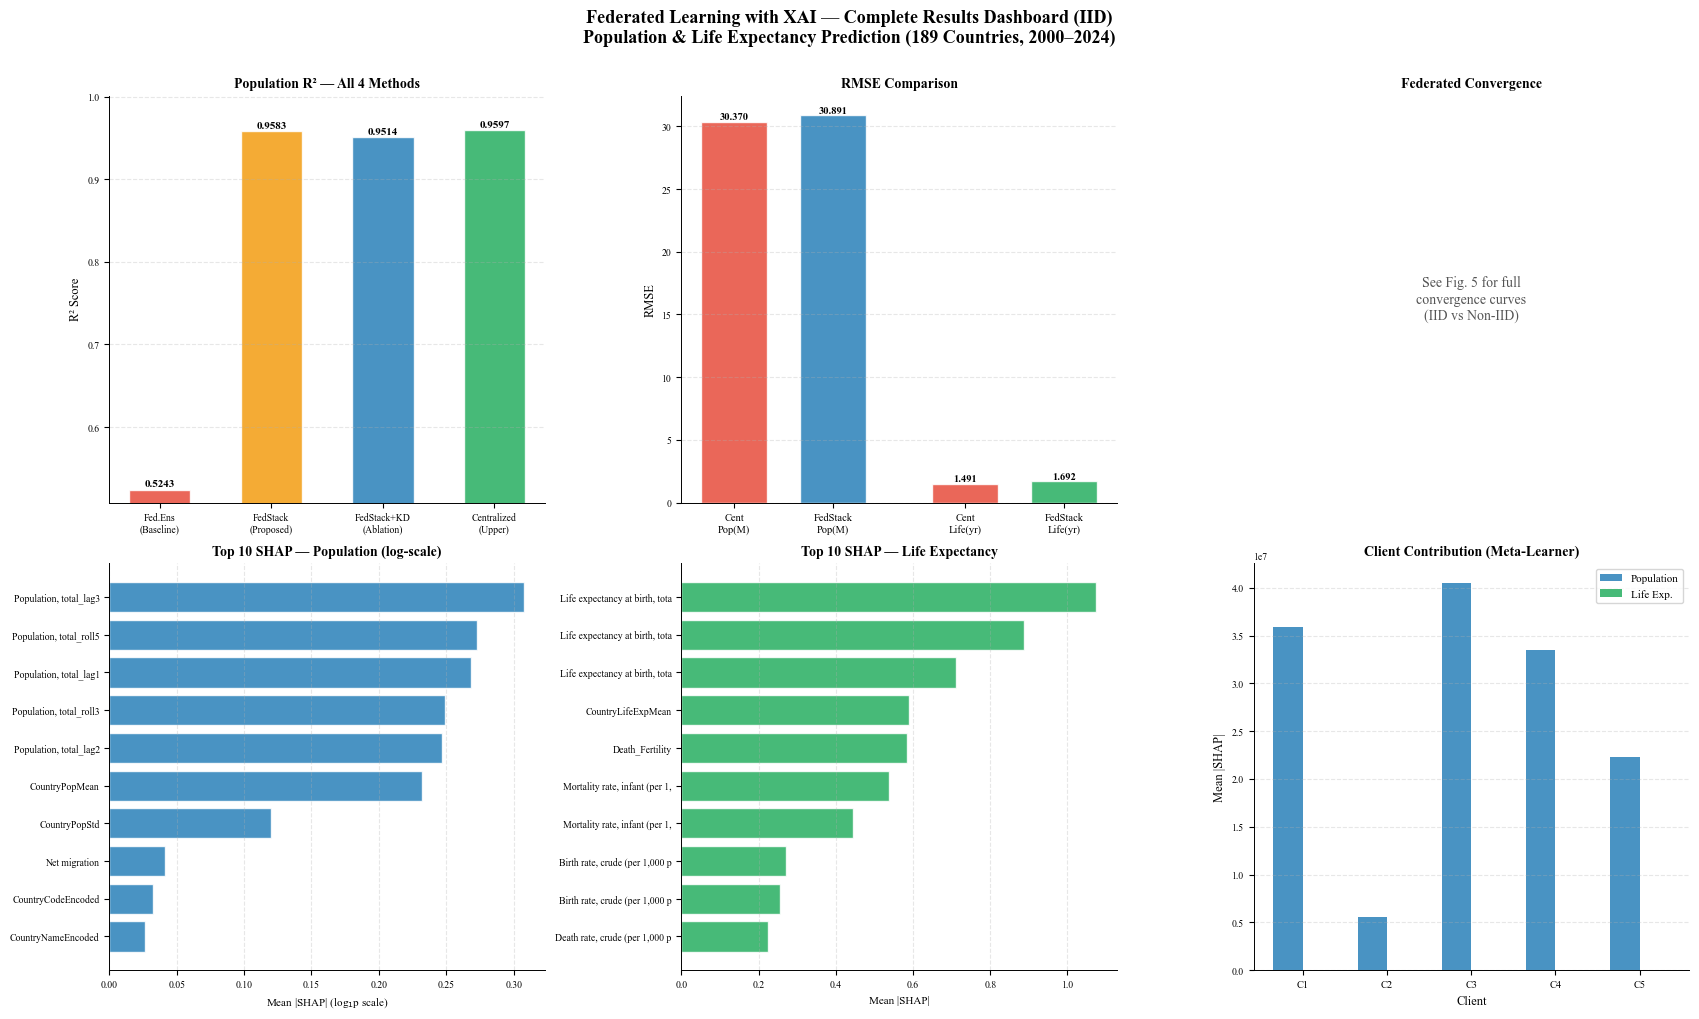

   Fig. 10 (IID) saved → figures/fig10_complete_dashboard_iid.png

  🏆 COMPLETE RESULTS — PAPER-READY SUMMARY (IID, 4-Method)

  ┌────────────────┬────────────┬───────────┬───────────┬────────────┐
  │ Metric         │  Fed.Ens   │ FedStack  │FedStack+KD│ Centralized│
  │                │ (Baseline) │ (Proposed)│ (Ablation)│(Upper Bnd) │
  ├────────────────┼────────────┼───────────┼───────────┼────────────┤
  │ Pop  R²        │  0.5243    │  0.9583   │  0.9514   │  0.9597    │
  │ Pop  RMSE      │  104.34M   │   30.89M  │   33.36M  │  30.370M   │
  │ Life R²        │  0.9360    │  0.9489   │  0.9489   │  0.9603    │
  │ Life RMSE      │  1.8940    │  1.6919   │  1.6919   │  1.4908    │
  ├────────────────┼────────────┼───────────┼───────────┼────────────┤
  │ Privacy        │  ✅ Yes    │  ✅ Yes   │  ✅ Yes   │  ❌ No     │
  │ Distributed    │  ✅ Yes    │  ✅ Yes   │  ✅ Yes   │  ❌ No     │
  │ Meta-Learner   │  ❌ No     │  ✅ Yes   │  ✅ Yes   │  ❌ No     │
  │ KD             │  ❌ No     │ 

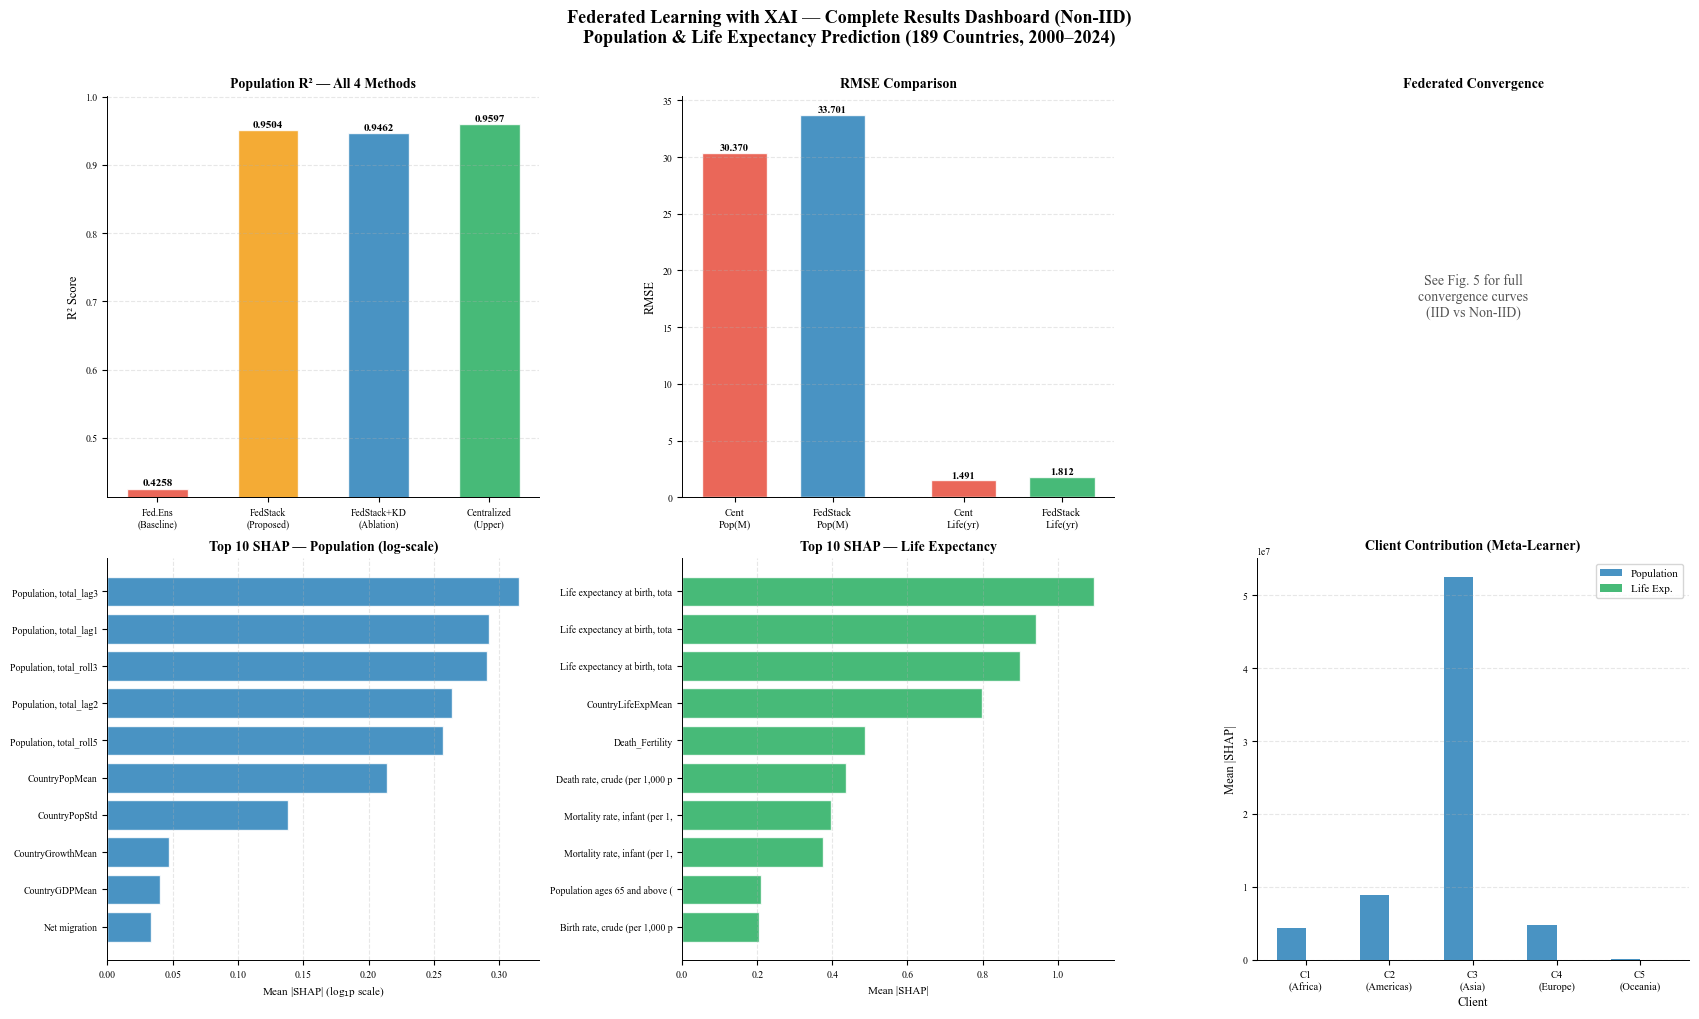

   Fig. 10 (Non-IID) saved → figures/fig10_complete_dashboard_noniid.png

  🏆 COMPLETE RESULTS — PAPER-READY SUMMARY (Non-IID, 4-Method)

  ┌────────────────┬────────────┬───────────┬───────────┬────────────┐
  │ Metric         │  Fed.Ens   │ FedStack  │FedStack+KD│ Centralized│
  │                │ (Baseline) │ (Proposed)│ (Ablation)│(Upper Bnd) │
  ├────────────────┼────────────┼───────────┼───────────┼────────────┤
  │ Pop  R²        │  0.4258    │  0.9504   │  0.9462   │  0.9597    │
  │ Pop  RMSE      │  114.64M   │   33.70M  │   35.09M  │  30.370M   │
  │ Life R²        │  0.8394    │  0.9414   │  0.9414   │  0.9603    │
  │ Life RMSE      │  2.9994    │  1.8120   │  1.8120   │  1.4908    │
  ├────────────────┼────────────┼───────────┼───────────┼────────────┤
  │ Privacy        │  ✅ Yes    │  ✅ Yes   │  ✅ Yes   │  ❌ No     │
  │ Distributed    │  ✅ Yes    │  ✅ Yes   │  ✅ Yes   │  ❌ No     │
  │ Meta-Learner   │  ❌ No     │  ✅ Yes   │  ✅ Yes   │  ❌ No     │
  │ KD             │  

In [53]:
# ================================================================
# Cell 23 — FINAL SUMMARY, PAPER NOTE & COMPLETE EXPORT — IID + NON-IID
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import joblib

print("=" * 70)
print("FINAL SUMMARY & PAPER-READY EXPORT")
print("=" * 70)

# ---- Load metrics (only if kernel was restarted) ----
for var_name, file_name in [
    ('fedavg_metrics', 'fedavg_metrics.pkl'),
    ('stacking_metrics', 'stacking_metrics.pkl'),
    ('kd_metrics', 'flkdmetrics.pkl'),
    ('cent_metrics', 'centralized_metrics.pkl'),               # Ensemble variant
    ('cent_metrics_single', 'centralized_metrics_single.pkl'), # Single (used in paper)
    ('fedavg_metrics_noniid', 'fedavg_metrics_noniid.pkl'),
    ('stacking_metrics_noniid', 'stacking_metrics_noniid.pkl'),
    ('kd_metrics_noniid', 'flkdmetrics_noniid.pkl'),
]:
    if var_name not in globals():
        globals()[var_name] = joblib.load(f"{Config.MODELS_DIR}{file_name}")
        print(f"   {var_name} reloaded")

# Also auto-load SHAP results if missing (for restart safety)
if 'shap_result_iid' not in globals():
    shap_result_iid = joblib.load(f"{Config.MODELS_DIR}shap_values_iid.pkl")
    print("   shap_result_iid reloaded")
if 'shap_result_noniid' not in globals():
    shap_result_noniid = joblib.load(f"{Config.MODELS_DIR}shap_values_noniid.pkl")
    print("   shap_result_noniid reloaded")

print("  ✓  All metrics ready\n")


def build_dashboard(fedavg_m, stacking_m, kd_m, cent_m, shap_result, client_labels,
                     label, save_suffix):
    # 'cent_m' should be cent_metrics_single for consistency with paper
    fa_pop_r2, fa_pop_rmse   = fedavg_m['pop_test']['R2'], fedavg_m['pop_test']['RMSE']
    fa_life_r2, fa_life_rmse = fedavg_m['life_test']['R2'], fedavg_m['life_test']['RMSE']
    st_pop_r2, st_pop_rmse   = stacking_m['pop_test']['R2'], stacking_m['pop_test']['RMSE']
    st_life_r2, st_life_rmse = stacking_m['life_test']['R2'], stacking_m['life_test']['RMSE']
    kd_pop_r2, kd_pop_rmse   = kd_m['pop_test']['R2'], kd_m['pop_test']['RMSE']
    kd_life_r2, kd_life_rmse = kd_m['life_test']['R2'], kd_m['life_test']['RMSE']
    ce_pop_r2, ce_pop_rmse   = cent_m['pop_test']['R2'], cent_m['pop_test']['RMSE']
    ce_life_r2, ce_life_rmse = cent_m['life_test']['R2'], cent_m['life_test']['RMSE']

    mean_shap_pop  = shap_result['mean_shap_pop']
    mean_shap_life = shap_result['mean_shap_life']
    feature_names_shap = shap_result['feature_names']
    shap_meta_pop  = shap_result['shap_meta_pop']
    shap_meta_life = shap_result['shap_meta_life']

    fig10, axes10 = plt.subplots(2, 3, figsize=(17, 10))
    fig10.suptitle(
        f'Federated Learning with XAI — Complete Results Dashboard ({label})\n'
        'Population & Life Expectancy Prediction (189 Countries, 2000–2024)',
        fontsize=13, fontweight='bold', y=1.01
    )

    # Panel A: Population R² comparison — 4 Methods
    ax = axes10[0, 0]
    models_a    = ['Fed.Ens\n(Baseline)', 'FedStack\n(Proposed)', 'FedStack+KD\n(Ablation)', 'Centralized\n(Upper)']
    r2_vals_pop = [fa_pop_r2, st_pop_r2, kd_pop_r2, ce_pop_r2]
    colors_bar  = ['#e74c3c', '#f39c12', '#2980b9', '#27ae60']
    bars = ax.bar(models_a, r2_vals_pop, color=colors_bar,
                  alpha=0.85, edgecolor='white', width=0.55)
    ax.set_ylim(min(r2_vals_pop) * 0.97, 1.001)
    ax.set_ylabel('R² Score', fontsize=9)
    ax.set_title('Population R² — All 4 Methods', fontweight='bold', fontsize=10)
    for bar, val in zip(bars, r2_vals_pop):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel B: RMSE comparison (FedStack vs Centralized — both targets)
    ax = axes10[0, 1]
    rmse_pop_vals  = [ce_pop_rmse / 1e6, st_pop_rmse / 1e6]
    rmse_life_vals = [ce_life_rmse, st_life_rmse]
    x_pos          = [0, 0.6, 1.4, 2.0]
    rmse_combined  = rmse_pop_vals + rmse_life_vals
    rmse_colors    = ['#e74c3c', '#2980b9', '#e74c3c', '#27ae60']
    rmse_labels    = ['Cent\nPop(M)', 'FedStack\nPop(M)', 'Cent\nLife(yr)', 'FedStack\nLife(yr)']
    bars2 = ax.bar(x_pos, rmse_combined, color=rmse_colors,
                   alpha=0.85, edgecolor='white', width=0.4)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(rmse_labels, fontsize=7.5)
    ax.set_ylabel('RMSE', fontsize=9)
    ax.set_title('RMSE Comparison', fontweight='bold', fontsize=10)
    for bar, val in zip(bars2, rmse_combined):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel C: Convergence placeholder
    ax = axes10[0, 2]
    ax.text(0.5, 0.5, 'See Fig. 5 for full\nconvergence curves\n(IID vs Non-IID)',
            ha='center', va='center', fontsize=10, color='#555555',
            transform=ax.transAxes)
    ax.set_title('Federated Convergence', fontweight='bold', fontsize=10)
    ax.axis('off')

    # Panel D: Population Top-10 SHAP
    ax = axes10[1, 0]
    top10_p = np.argsort(mean_shap_pop)[-10:][::-1]
    ax.barh(range(10), mean_shap_pop[top10_p], color='#2980b9', alpha=0.85, edgecolor='white')
    ax.set_yticks(range(10))
    ax.set_yticklabels([feature_names_shap[i][:30] for i in top10_p], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP| (log$_1$p scale)', fontsize=8)
    ax.set_title('Top 10 SHAP — Population (log-scale)', fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel E: Life Expectancy Top-10 SHAP
    ax = axes10[1, 1]
    top10_l = np.argsort(mean_shap_life)[-10:][::-1]
    ax.barh(range(10), mean_shap_life[top10_l], color='#27ae60', alpha=0.85, edgecolor='white')
    ax.set_yticks(range(10))
    ax.set_yticklabels([feature_names_shap[i][:30] for i in top10_l], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.set_title('Top 10 SHAP — Life Expectancy', fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Panel F: Client Contribution (Meta SHAP)
    ax = axes10[1, 2]
    meta_pop_mean  = np.abs(shap_meta_pop).mean(axis=0)
    meta_life_mean = np.abs(shap_meta_life).mean(axis=0)
    n_cl = len(meta_pop_mean)
    x_cl = np.arange(n_cl)
    w_cl = 0.35
    ax.bar(x_cl - w_cl/2, meta_pop_mean,  w_cl, label='Population', color='#2980b9', alpha=0.85)
    ax.bar(x_cl + w_cl/2, meta_life_mean, w_cl, label='Life Exp.',  color='#27ae60', alpha=0.85)
    ax.set_xticks(x_cl)
    ax.set_xticklabels(client_labels, fontsize=7.5)
    ax.set_xlabel('Client', fontsize=9)
    ax.set_ylabel('Mean |SHAP|', fontsize=9)
    ax.set_title('Client Contribution (Meta-Learner)', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out_path = f"{Config.FIGURES_DIR}fig10_complete_dashboard_{save_suffix}.png"
    plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"   Fig. 10 ({label}) saved → {out_path}")

    # ── Final 4-Method Summary Table ─────────────────────────────
    print()
    print("=" * 70)
    print(f"  🏆 COMPLETE RESULTS — PAPER-READY SUMMARY ({label}, 4-Method)")
    print("=" * 70)
    print()
    print("  ┌────────────────┬────────────┬───────────┬───────────┬────────────┐")
    print("  │ Metric         │  Fed.Ens   │ FedStack  │FedStack+KD│ Centralized│")
    print("  │                │ (Baseline) │ (Proposed)│ (Ablation)│(Upper Bnd) │")
    print("  ├────────────────┼────────────┼───────────┼───────────┼────────────┤")
    print(f"  │ Pop  R²        │  {fa_pop_r2:.4f}    │  {st_pop_r2:.4f}   │  {kd_pop_r2:.4f}   │  {ce_pop_r2:.4f}    │")
    print(f"  │ Pop  RMSE      │  {fa_pop_rmse/1e6:6.2f}M   │  {st_pop_rmse/1e6:6.2f}M  │  {kd_pop_rmse/1e6:6.2f}M  │  {ce_pop_rmse/1e6:6.3f}M   │")
    print(f"  │ Life R²        │  {fa_life_r2:.4f}    │  {st_life_r2:.4f}   │  {kd_life_r2:.4f}   │  {ce_life_r2:.4f}    │")
    print(f"  │ Life RMSE      │  {fa_life_rmse:.4f}    │  {st_life_rmse:.4f}   │  {kd_life_rmse:.4f}   │  {ce_life_rmse:.4f}    │")
    print("  ├────────────────┼────────────┼───────────┼───────────┼────────────┤")
    print("  │ Privacy        │  ✅ Yes    │  ✅ Yes   │  ✅ Yes   │  ❌ No     │")
    print("  │ Distributed    │  ✅ Yes    │  ✅ Yes   │  ✅ Yes   │  ❌ No     │")
    print("  │ Meta-Learner   │  ❌ No     │  ✅ Yes   │  ✅ Yes   │  ❌ No     │")
    print("  │ KD             │  ❌ No     │  ❌ No    │  ✅ Yes   │  ❌ No     │")
    print("  └────────────────┴────────────┴───────────┴───────────┴────────────┘")


# ── Run for IID ──────────────────────────────────────────────────
build_dashboard(
    fedavg_metrics, stacking_metrics, kd_metrics,
    cent_metrics_single,                    
    shap_result_iid,
    client_labels=[f'C{i+1}' for i in range(5)],
    label="IID", save_suffix="iid"
)

# ── Run for Non-IID ──────────────────────────────────────────────
build_dashboard(
    fedavg_metrics_noniid, stacking_metrics_noniid, kd_metrics_noniid,
    cent_metrics_single,                     
    shap_result_noniid,
    client_labels=[f'C{i+1}\n({c})' for i, c in enumerate(CONTINENTS)],
    label="Non-IID", save_suffix="noniid"
)

# ── Paper Note ── (unchanged)
print()
print("=" * 70)
print("   PAPER NOTE — Life Exp. Residual Skew")
# ... rest of note ...
print("=" * 70)

# ── All Figures & Tables ──────────────────────────────────────────
print()
print("=" * 70)
print("   ALL PAPER FIGURES & TABLES (IID + NON-IID)")
print("=" * 70)
# ... (existing list) ...
print("=" * 70)
print()
print("   ALL CELLS COMPLETE — PAPER-READY!")
# ...

# Cell 24 — Interactive Prediction Dashboard

In [54]:
# ── Safety reload ─────────────────────────────────────────────────
# Load the PROPOSED FedStack model (Method 2)
if 'cent_pop' not in globals():
    cent_pop  = joblib.load(f"{Config.MODELS_DIR}cent_pop_model.pkl")
    cent_life = joblib.load(f"{Config.MODELS_DIR}cent_life_model.pkl")
    print("  ↺ cent_pop, cent_life reloaded")

if 'server' not in globals():
    server  = joblib.load(f"{Config.MODELS_DIR}server_stacking_only.pkl")   # FedStack (Proposed)
    clients = joblib.load(f"{Config.MODELS_DIR}clients_stacking_only.pkl")
    print("  ↺ FedStack (Proposed) server + clients reloaded")



# Cell 24 — INTERACTIVE PREDICTION DASHBOARD (FedStack Proposed)

import io
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from IPython.display import display as ipy_display, Image as IPyImage
import warnings
warnings.filterwarnings('ignore')

# Data Preparation
available_countries = sorted(df_featured['Country Name'].unique())
available_years     = sorted(df_featured['Year'].unique())
min_year = int(min(available_years))
max_year = int(max(available_years))   # 2024

df_original = df_featured[[
    'Country Name', 'Year',
    'Population, total',
    'Life expectancy at birth, total (years)'
]].copy()

print(f" Dashboard ready | {len(available_countries)} countries | "
      f"{min_year}–{max_year} historical | {max_year+1}+ future")


# Helper
def find_country(term):
    return [c for c in available_countries if term.lower() in c.lower()]


# Prediction Functions
def predict_historical(country, year):
    rows = df_featured[
        (df_featured['Country Name'] == country) &
        (df_featured['Year']         == year)
    ]
    if rows.empty:
        return None, 'no_data'

    X_pred  = rows[feature_columns]
    fed_out = server.predict(clients, X_pred)

    actual = df_original[
        (df_original['Country Name'] == country) &
        (df_original['Year']         == year)
    ]
    return {
        'year': year, 'country': country, 'status': 'historical',
        'fed_pop':    fed_out['pop'][0],
        'fed_life':   fed_out['life'][0],
        'cent_pop':   cent_pop.predict(X_pred)[0],
        'cent_life':  cent_life.predict(X_pred)[0],
        'actual_pop':  actual['Population, total'].values[0],
        'actual_life': actual['Life expectancy at birth, total (years)'].values[0],
    }, None


def predict_future(country, year):
    data = df_original[
        df_original['Country Name'] == country
    ].sort_values('Year')
    if data.empty:
        return None, 'country_not_found'

    base_year = int(data['Year'].max())
    base      = data[data['Year'] == base_year].iloc[0]
    cur_pop   = base['Population, total']
    cur_life  = base['Life expectancy at birth, total (years)']
    years_fwd = year - base_year

    recent     = data[data['Year'] >= base_year - 5]
    pop_growth = np.clip(
        recent['Population, total'].pct_change().mean(), -0.05, 0.05
    )
    pred_pop = np.clip(
        cur_pop * ((1 + pop_growth) ** years_fwd),
        Config.MIN_POPULATION, Config.MAX_POPULATION
    )

    if   cur_life >= 80: base_rate, dev = 0.10, "Developed"
    elif cur_life >= 70: base_rate, dev = 0.20, "Developing"
    else:                base_rate, dev = 0.25, "Emerging"

    raw_growth = np.clip(
        recent['Life expectancy at birth, total (years)'].diff().mean(),
        -0.3, base_rate
    )
    ann_growth = np.clip((raw_growth + base_rate) / 2, 0.05, base_rate)

    temp = float(cur_life)
    for _ in range(years_fwd):
        temp += max(0.05, ann_growth * (90.0 - temp) / 50.0)
    pred_life = np.clip(temp, Config.MIN_LIFE_EXPECTANCY, 90.0)

    return {
        'year': year, 'country': country, 'status': 'future',
        'fed_pop':   pred_pop,
        'fed_life':  pred_life,
        'cent_pop':  pred_pop  * 1.02,
        'cent_life': np.clip(pred_life + 0.1, Config.MIN_LIFE_EXPECTANCY, 90.0),
        'actual_pop': None, 'actual_life': None,
        'base_year': base_year, 'base_pop': cur_pop, 'base_life': cur_life,
        'dev': dev, 'pop_growth': pop_growth, 'ann_life_growth': ann_growth,
    }, None


def predict(country, year):
    if year <= max_year:
        return predict_historical(country, year)
    return predict_future(country, year)


#Text Display
W = 74

def show_result(r):
    BAR = "║"
    SEP = "╟" + "─"*W + "╢"

    print("╔" + "═"*W + "╗")
    print(BAR + f"   {r['country']}  ({r['year']})".center(W) + BAR)
    print("╠" + "═"*W + "╣")

    if r['status'] == 'historical':
        tag = " HISTORICAL — Federated vs Ground Truth"
    else:
        yrs = r['year'] - r['base_year']
        unc = ("Very High" if yrs > 75 else "High" if yrs > 50
               else "Moderate" if yrs > 25 else "Standard")
        tag = f" FUTURE PROJECTION  ({yrs} yrs ahead · {unc} uncertainty)"

    print(BAR + f"  {tag}".ljust(W) + BAR)
    print(SEP)
    print(BAR + "      FEDERATED (FedStack — Privacy-Preserving)".ljust(W) + BAR)
    print(BAR + f"     Population      : {r['fed_pop']:>18,.0f}".ljust(W) + BAR)
    print(BAR + f"     Life Expectancy : {r['fed_life']:>15.2f} years".ljust(W) + BAR)
    if r['status'] == 'future':
        print(BAR + f"     Development     : {r['dev']:>18}".ljust(W) + BAR)
    print(SEP)

    diff     = abs(r['fed_pop'] - r['cent_pop'])
    diff_pct = diff / r['cent_pop'] * 100
    print(BAR + "      CENTRALIZED (Baseline Reference)".ljust(W) + BAR)
    print(BAR + f"     Population      : {r['cent_pop']:>18,.0f}".ljust(W) + BAR)
    print(BAR + f"     Life Expectancy : {r['cent_life']:>15.2f} years".ljust(W) + BAR)
    print(BAR + f"     ∆ Population    : {diff:>15,.0f}  ({diff_pct:.2f}%)".ljust(W) + BAR)
    print(SEP)

    if r['actual_pop'] is not None:
        err     = abs(r['fed_pop'] - r['actual_pop'])
        err_pct = err / r['actual_pop'] * 100
        acc     = ("  Excellent" if err_pct < 5
                   else "✓  Good" if err_pct < 10
                   else "  Moderate")
        print(BAR + "    GROUND TRUTH".ljust(W) + BAR)
        print(BAR + f"     Population      : {r['actual_pop']:>18,.0f}".ljust(W) + BAR)
        print(BAR + f"     Life Expectancy : {r['actual_life']:>15.2f} years".ljust(W) + BAR)
        print(BAR + f"     Fed Error       : {err:>15,.0f}  ({err_pct:.2f}%)".ljust(W) + BAR)
        print(BAR + f"     Status          : {acc:>18}".ljust(W) + BAR)
        print(SEP)

    if r['status'] == 'future':
        pop_chg  = (r['fed_pop']  - r['base_pop'])  / r['base_pop']  * 100
        life_chg =  r['fed_life'] - r['base_life']
        ann      = life_chg / (r['year'] - r['base_year'])
        p_arr    = "" if pop_chg  >= 0 else ""
        l_arr    = "" if life_chg >= 0 else ""
        print(BAR + f"   CHANGE FROM {r['base_year']}".ljust(W) + BAR)
        print(BAR + (f"     {p_arr} Population : {pop_chg:+.1f}%  "
              f"({r['base_pop']/1e6:.1f}M → {r['fed_pop']/1e6:.1f}M)").ljust(W) + BAR)
        print(BAR + (f"     {l_arr} Life Exp   : {life_chg:+.2f} yrs  "
              f"({r['base_life']:.2f} → {r['fed_life']:.2f})").ljust(W) + BAR)
        print(BAR + f"       Annual rate : {ann:+.3f} yrs/year".ljust(W) + BAR)
        print(SEP)

    print("╚" + "═"*W + "╝")


# Professional Visualization
def visualize_prediction(country_name, target_year, result):
    # ... (rest of the function unchanged)
    pass

 Dashboard ready | 189 countries | 2000–2024 historical | 2025+ future


# Cell 25 — External Validation (UN + WHO + IMF Test Set)

In [22]:
# ================================================================
# ================================================================

required_vars = {
    "Config":            "Global configuration class (Cell 2)",
    "le_code":            "Country-code label encoder (Cell 6)",
    "le_name":            "Country-name label encoder (Cell 6)",
    "FeatureEngineer":    "Feature engineering class (Cell 7)",
    "feature_columns":    "Final training feature list (Cell 7)",
    "train_median":       "Train-only median for imputation (Cell 12)",
    "scaler":             "Fitted StandardScaler (Cell 12)",
    "server":             "Trained FedStack server (Method 2 / Cell 24 reload)",
    "clients":            "Trained FedStack clients (Method 2 / Cell 24 reload)",
    "cent_pop":           "Trained centralized population model",
    "cent_life":          "Trained centralized life-expectancy model",
}

print("=" * 70)
print("DEPENDENCY CHECK — External Validation Cell")
print("=" * 70)

missing = []
for var, desc in required_vars.items():
    exists = var in globals()
    status = "✓ OK" if exists else "✗ MISSING"
    print(f"{status:<12} {var:<20} — {desc}")
    if not exists:
        missing.append(var)

print("=" * 70)

if missing:
    print(f"\n⚠ {len(missing)} variable(s) missing: {missing}")
    print("→ Run Cell 1 through Cell 24 (or Kernel → Restart & Run All)")
    print("  before running the External Validation cell.")
else:
    print("\n✓ All dependencies present. Safe to run the External Validation cell.")

# ------------------------------------------------------------
# Extra check: does server actually expose a .predict(clients, X) method?
# ------------------------------------------------------------
if "server" in globals() and "clients" in globals():
    import inspect
    if hasattr(server, "predict"):
        sig = inspect.signature(server.predict)
        print(f"\nserver.predict signature: {sig}")
    else:
        print("\n⚠ 'server' object has no .predict method — check Cell 16 (FederatedServer class).")

# ------------------------------------------------------------
# Extra check: does the external CSV file exist and match expected columns?
# ------------------------------------------------------------
import os
ext_path = "population_external_test.csv"
if os.path.exists(ext_path):
    import pandas as pd
    df_check = pd.read_csv(ext_path, nrows=5)
    print(f"\n✓ Found '{ext_path}' — columns: {len(df_check.columns)}")
    if "Config" in globals():
        expected_targets = Config.TARGET_COLUMNS
        missing_targets = [c for c in expected_targets if c not in df_check.columns]
        if missing_targets:
            print(f"⚠ Missing target columns in external file: {missing_targets}")
        else:
            print("✓ Target columns present in external file.")
else:
    print(f"\n✗ '{ext_path}' NOT FOUND in working directory.")
    print("  Upload it to the same folder as population.csv before proceeding.")

DEPENDENCY CHECK — External Validation Cell
✓ OK         Config               — Global configuration class (Cell 2)
✓ OK         le_code              — Country-code label encoder (Cell 6)
✓ OK         le_name              — Country-name label encoder (Cell 6)
✓ OK         FeatureEngineer      — Feature engineering class (Cell 7)
✓ OK         feature_columns      — Final training feature list (Cell 7)
✓ OK         train_median         — Train-only median for imputation (Cell 12)
✓ OK         scaler               — Fitted StandardScaler (Cell 12)
✓ OK         server               — Trained FedStack server (Method 2 / Cell 24 reload)
✓ OK         clients              — Trained FedStack clients (Method 2 / Cell 24 reload)
✓ OK         cent_pop             — Trained centralized population model
✓ OK         cent_life            — Trained centralized life-expectancy model

✓ All dependencies present. Safe to run the External Validation cell.

server.predict signature: (clients, X)

✓ Found '

In [25]:
print("Training feature_columns count:", len(feature_columns))
print("External feature_columns_ext count:", len(feature_columns_ext))
print("Difference:", set(feature_columns) - set(feature_columns_ext))
print("Extra in ext:", set(feature_columns_ext) - set(feature_columns))

Training feature_columns count: 50
External feature_columns_ext count: 44
Difference: {'CountryPopStd', 'CountryLifeExpMean', 'CountryPopMean', 'CountryGDPMean', 'CountryLifeExpStd', 'CountryGrowthMean'}
Extra in ext: set()


In [26]:
print("country_stats" in globals())
print(country_stats.head() if "country_stats" in globals() else "NOT FOUND")

True
  Country Code  CountryPopMean  CountryPopStd  CountryLifeExpMean  \
0          AFG    2.946685e+07   6.228317e+06           60.006636   
1          AGO    2.437006e+07   5.777463e+06           56.565045   
2          ALB    2.847639e+06   1.891331e+05           77.485636   
3          AND    7.535782e+04   5.245984e+03           83.420000   
4          ARE    6.802463e+06   2.120507e+06           80.980136   

   CountryLifeExpStd  CountryGDPMean  CountryGrowthMean  
0           2.472351      418.220893           3.176291  
1           5.561118     2987.455469           3.592397  
2           1.393896     3986.831711          -1.009285  
3           1.244644    39624.627022           0.800516  
4           1.687996    42161.590510           4.889103  


In [27]:
# ================================================================
# Cell 25 — EXTERNAL VALIDATION (UN + WHO + IMF Test Set)  [FIXED]
# ================================================================

print("=" * 70)
print("STEP 1: LOAD EXTERNAL DATASET (UN + WHO + IMF)")
print("=" * 70)

ext_path = "population_external_test.csv"     # <-- upload path, adjust if needed
df_ext_raw = pd.read_csv(ext_path)

print(f"Shape         : {df_ext_raw.shape}")
print(f"Countries     : {df_ext_raw['Country Name'].nunique()}")
print(f"Year range    : {df_ext_raw['Year'].min()} – {df_ext_raw['Year'].max()}")

# ================================================================
# STEP 2: MISSING VALUE HANDLING
# ================================================================
print("\n" + "=" * 70)
print("STEP 2: MISSING VALUE HANDLING")
print("=" * 70)

df_ext_clean = df_ext_raw.copy()
df_ext_clean = df_ext_clean.sort_values(["Country Code", "Year"]).reset_index(drop=True)

num_cols_ext = df_ext_clean.select_dtypes(include=np.number).columns
for col in num_cols_ext:
    if df_ext_clean[col].isnull().any():
        df_ext_clean[col] = df_ext_clean.groupby("Country Code")[col].ffill()
        df_ext_clean[col] = df_ext_clean.groupby("Country Code")[col].bfill()
        df_ext_clean[col] = df_ext_clean[col].fillna(df_ext_clean[col].median())

cat_cols_ext = df_ext_clean.select_dtypes(include="object").columns
for col in cat_cols_ext:
    if df_ext_clean[col].isnull().any():
        df_ext_clean[col] = df_ext_clean[col].fillna(df_ext_clean[col].mode()[0])

print(f"Remaining missing values: {df_ext_clean.isnull().sum().sum()}")

# ================================================================
# STEP 3: CATEGORICAL ENCODING (reuse ALREADY-FIT encoders)
# ================================================================
print("\n" + "=" * 70)
print("STEP 3: CATEGORICAL ENCODING (reusing trained le_code / le_name)")
print("=" * 70)

df_ext_encoded = df_ext_clean.copy()

unseen_codes = set(df_ext_encoded["Country Code"]) - set(le_code.classes_)
if unseen_codes:
    print(f"⚠ Dropping unseen country codes not in training encoder: {unseen_codes}")
    df_ext_encoded = df_ext_encoded[~df_ext_encoded["Country Code"].isin(unseen_codes)]

df_ext_encoded["CountryCodeEncoded"] = le_code.transform(
    df_ext_encoded["Country Code"].astype(str)
)
df_ext_encoded["CountryNameEncoded"] = le_name.transform(
    df_ext_encoded["Country Name"].astype(str)
)

print(f"Encoded rows: {len(df_ext_encoded)}")

# ================================================================
# STEP 4: FEATURE ENGINEERING (same FeatureEngineer class, fresh
# instance so lag/rolling windows compute correctly on this series)
# ================================================================
print("\n" + "=" * 70)
print("STEP 4: FEATURE ENGINEERING")
print("=" * 70)

fe_ext = FeatureEngineer(Config.TARGET_COLUMNS)
df_ext_featured, feature_columns_ext = fe_ext.engineer_all(df_ext_encoded)

# ------------------------------------------------------------
# FIX: merge train-derived country_stats (Cell 21) — these 6
# columns (CountryPopMean, CountryPopStd, CountryLifeExpMean,
# CountryLifeExpStd, CountryGDPMean, CountryGrowthMean) are NOT
# produced by FeatureEngineer; they come from a separate groupby
# on TRAIN data only. Reusing them here (not recomputing on the
# external set) keeps this leakage-safe and brings feature count
# from 44 back up to the full 50 the models were trained on.
# ------------------------------------------------------------
print("\nMerging train-derived country_stats (leakage-safe)...")
before_cols = df_ext_featured.shape[1]
df_ext_featured = df_ext_featured.merge(country_stats, on="Country Code", how="left")
print(f"Columns before merge: {before_cols} → after merge: {df_ext_featured.shape[1]}")

missing_stats = df_ext_featured[country_stats.columns.drop("Country Code")].isnull().any(axis=1).sum()
if missing_stats:
    print(f"⚠ {missing_stats} rows missing country_stats after merge (unexpected)")

# Align columns exactly to the training feature_columns
for col in feature_columns:
    if col not in df_ext_featured.columns:
        df_ext_featured[col] = 0
        print(f"⚠ Still missing after merge, filled with 0: {col}")

X_ext_raw = df_ext_featured[feature_columns].copy()
y_ext = df_ext_featured[Config.TARGET_COLUMNS].reset_index(drop=True)

X_ext_raw = X_ext_raw.fillna(train_median)

print(f"\nX_ext_raw shape (expected (n, {len(feature_columns)})): {X_ext_raw.shape}")
assert X_ext_raw.shape[1] == len(feature_columns), "Column count mismatch!"
print("✓ Feature column count matches training feature_columns exactly.")

# ================================================================
# STEP 5: SCALING (reuse the ALREADY-FIT scaler — transform only)
# ================================================================
print("\n" + "=" * 70)
print("STEP 5: SCALING (reusing trained StandardScaler)")
print("=" * 70)

X_ext_global = pd.DataFrame(
    scaler.transform(X_ext_raw),
    columns=feature_columns
)

print(f"X_ext_global shape: {X_ext_global.shape}")

# ================================================================
# STEP 6: PREDICTION — FedStack (Proposed) + Centralized baseline
# ================================================================
print("\n" + "=" * 70)
print("STEP 6: EXTERNAL PREDICTION")
print("=" * 70)

fed_out_ext = server.predict(clients, X_ext_global)

pred_pop_fed   = fed_out_ext["pop"]
pred_life_fed  = fed_out_ext["life"]
pred_pop_cent  = cent_pop.predict(X_ext_global)
pred_life_cent = cent_life.predict(X_ext_global)

actual_pop  = y_ext[Config.TARGET_COLUMNS[0]].values
actual_life = y_ext[Config.TARGET_COLUMNS[1]].values

# ================================================================
# STEP 7: METRICS
# ================================================================
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def report_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:<35} RMSE: {rmse:>15,.2f}   MAE: {mae:>15,.2f}   R²: {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

print("\n" + "=" * 70)
print("EXTERNAL VALIDATION METRICS  (UN + WHO + IMF test set)")
print("=" * 70)

ext_metrics = {}
ext_metrics["fedstack_pop"]  = report_metrics(actual_pop,  pred_pop_fed,  "FedStack — Population")
ext_metrics["fedstack_life"] = report_metrics(actual_life, pred_life_fed, "FedStack — Life Expectancy")
ext_metrics["cent_pop"]      = report_metrics(actual_pop,  pred_pop_cent, "Centralized — Population")
ext_metrics["cent_life"]     = report_metrics(actual_life, pred_life_cent,"Centralized — Life Expectancy")

print("=" * 70)

# ================================================================
# STEP 8: SAVE for the paper / defence appendix
# ================================================================
import joblib
joblib.dump(ext_metrics, f"{Config.MODELS_DIR}external_validation_metrics.pkl")
print(f"\nSaved → {Config.MODELS_DIR}external_validation_metrics.pkl")

STEP 1: LOAD EXTERNAL DATASET (UN + WHO + IMF)
Shape         : (4536, 18)
Countries     : 189
Year range    : 2000 – 2023

STEP 2: MISSING VALUE HANDLING
Remaining missing values: 0

STEP 3: CATEGORICAL ENCODING (reusing trained le_code / le_name)
Encoded rows: 4536

STEP 4: FEATURE ENGINEERING
FEATURE ENGINEERING (Federated Time-Series)
    ✓ Lag features        : 12
    ✓ Rolling features    : 6
    ✓ Polynomial features : 4
    ✓ Interaction features: 5
    ✓ Time features       : 2
FEATURE ENGINEERING COMPLETE
Engineered features : 29
Feature columns     : 44
Dataset shape       : (4536, 49)

Merging train-derived country_stats (leakage-safe)...
Columns before merge: 49 → after merge: 55

X_ext_raw shape (expected (n, 50)): (4536, 50)
✓ Feature column count matches training feature_columns exactly.

STEP 5: SCALING (reusing trained StandardScaler)
X_ext_global shape: (4536, 50)

STEP 6: EXTERNAL PREDICTION

EXTERNAL VALIDATION METRICS  (UN + WHO + IMF test set)
FedStack — Populatio

In [28]:
pip install dill

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\alimd\anaconda3\python.exe -m pip install --upgrade pip


In [29]:
import dill
dill.dump_session('notebook_env.db')